In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd
from pdgid import pdgid_dict
import plot_utils
import constants
import log_parser

geometry = "nucap"
tag = "MuBeamStopVD"
pklname = geometry+"_MuminusStopToVD_genealogy_1file_no_genealogy.pkl"

In [2]:
ROOT.EnableImplicitMT()
fileList = ['/pnfs/mu2e/scratch/users/yongyiwu/workflow/nucap.MDC2020s12r0000.s2_ana_MuminusStopToVD/outstage/89566068/00/00000/nts.yongyiwu.MDC2020s22r0000.nucap.001219_00000000.root']
df_particles = pd.DataFrame()
df_source = pd.DataFrame()
for ii, filename in enumerate(fileList):
    rdfp_ = ROOT.RDataFrame("ParticleBackTracer/ttree", filename)
    dfp_ = pd.DataFrame(rdfp_.AsNumpy())
    # adding "tag" "fileno" "r" "weight", all p's and E multiply by 1000
    dfp_.insert(0, 'tag', tag)
    dfp_.insert(1, 'fileno', ii)
    dfp_['weight'] = 1
    dfp_['r'] = np.sqrt((dfp_['x']-constants.VD101_X)**2+(dfp_['y'])**2)
    dfp_['px'] = dfp_['px']*1000 # so in keV
    dfp_['py'] = dfp_['py']*1000 # so in keV
    dfp_['pz'] = dfp_['pz']*1000 # so in keV
    dfp_['startpx'] = dfp_['startpx']*1000 # so in keV
    dfp_['startpy'] = dfp_['startpy']*1000 # so in keV
    dfp_['startpz'] = dfp_['startpz']*1000 # so in keV
    dfp_['E'] = dfp_['E']*1000 # so in keV
    df_particles = pd.concat([df_particles,dfp_], ignore_index=True)
    
    rdfs_ = ROOT.RDataFrame("ParticleBackTracer/ttree_source", filename)
    dfs_ = pd.DataFrame(rdfs_.AsNumpy())
    dfs_.insert(0, 'tag', tag)
    dfs_.insert(1, 'fileno', ii)
    dfs_['pdgId'] = dfp_['pdgId']
    df_source = pd.concat([df_source,dfs_], ignore_index=True)
with open(pklname, 'wb') as f:
    pickle.dump(df_particles, f)
    pickle.dump(df_source, f)    

In [3]:
with open(pklname, 'rb') as f:
    df_particles = pickle.load(f)
    df_source = pickle.load(f)
display(df_particles)
display(df_source)
print("weights:", np.sort(df_particles['weight'].unique()))
print("VDs:", np.sort(df_particles['virtualdetectorId'].unique()))
print("z coordinates of events:", np.sort(df_particles['z'].unique()))
print("creation codes:", np.sort(df_particles['creationCode'].unique()))

,tag,fileno,E,creationCode,index,pdgId,px,py,pz,startpx,...,startx,starty,startz,time,virtualdetectorId,x,y,z,weight,r
0,MuBeamStopVD,0,125.269321,165,0,22,72.829021,-49.781729,88.938833,-5350.543022,...,-3856.730912,31.081420,6182.104168,1074.324171,10,-4331.922979,205.344901,6275.999996,1,474.641553
1,MuBeamStopVD,0,2160.927010,165,1,22,1580.096625,705.453612,1294.308850,1580.096602,...,-3955.574003,-47.742557,6048.789062,343.364363,10,-3678.194125,76.097108,6275.999996,1,238.283577
2,MuBeamStopVD,0,39223.356056,165,2,2112,78381.910482,53975.641289,257268.714040,78381.912231,...,-3955.574003,-47.742557,6048.789062,344.982450,10,-3886.349779,-0.073115,6275.999996,1,17.650373
3,MuBeamStopVD,0,6645.766690,165,3,22,6067.657162,1071.584627,2490.272646,6067.656994,...,-3955.634553,7.549338,6093.178293,1844.118464,10,-3510.181555,86.219007,6275.999996,1,403.145984
4,MuBeamStopVD,0,2820.761014,165,4,22,372.287776,1740.556630,2188.277205,372.287780,...,-3955.634553,7.549338,6093.178293,1843.277111,10,-3924.531416,152.965799,6275.999996,1,154.337535
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103903,MuBeamStopVD,0,452.701278,97,103903,2112,1862.945628,9863.169936,27388.631396,-57434.394836,...,-2989.806685,261.059838,6025.369385,1172.591061,10,-3893.613453,-272.754397,6275.999996,1,272.952087
103904,MuBeamStopVD,0,7248.486965,165,103904,2112,60639.541998,-20807.599607,97792.048949,60639.541626,...,-3942.210444,-28.251072,6204.311099,1011.700032,10,-3897.757117,-43.504601,6275.999996,1,43.950244
103905,MuBeamStopVD,0,5049.638997,165,103905,22,2484.631694,4382.892235,340.169080,2484.631777,...,-3844.018312,-18.011296,6270.967350,1108.066895,10,-3807.259322,46.831592,6275.999996,1,107.480030
103906,MuBeamStopVD,0,3641.846196,165,103906,22,2174.048801,2779.646431,900.067356,2174.048901,...,-3844.018312,-18.011296,6270.967350,1107.885623,10,-3831.862313,-2.469151,6275.999996,1,72.179932


,tag,fileno,creationCode,index,parentendtime,parentpdgId,starttime,x,y,z,pdgId
0,MuBeamStopVD,0,165,0,201.633743,13,1068.434692,-3856.730912,31.081420,6182.104168,22
1,MuBeamStopVD,0,165,1,143.052109,13,342.098999,-3955.574003,-47.742557,6048.789062,22
2,MuBeamStopVD,0,165,2,143.052109,13,342.098999,-3955.574003,-47.742557,6048.789062,2112
3,MuBeamStopVD,0,165,3,170.588455,13,1842.490967,-3955.634553,7.549338,6093.178293,22
4,MuBeamStopVD,0,165,4,170.588455,13,1842.490967,-3955.634553,7.549338,6093.178293,22
...,...,...,...,...,...,...,...,...,...,...,...
103903,MuBeamStopVD,0,165,103903,174.853226,13,1009.384827,-3942.210444,-28.251072,6204.311099,2112
103904,MuBeamStopVD,0,165,103904,174.853226,13,1009.384827,-3942.210444,-28.251072,6204.311099,2112
103905,MuBeamStopVD,0,165,103905,243.757950,13,1107.817749,-3844.018312,-18.011296,6270.967350,22
103906,MuBeamStopVD,0,165,103906,243.757950,13,1107.817749,-3844.018312,-18.011296,6270.967350,22


weights: [1]
VDs: [10]
z coordinates of events: [6275.999996 6276.019996 6276.019996]
creation codes: [  2  12  13  16  17  35  40  58  72  74  97 101 165 166 172]



$e^{+}$ from MuBeamStopVD:  16
$e^{-}$ from MuBeamStopVD:  31252
$\gamma$ from MuBeamStopVD:  46509
$n$ from MuBeamStopVD:  25628
$p$ from MuBeamStopVD:  362
$D$ from MuBeamStopVD:  141


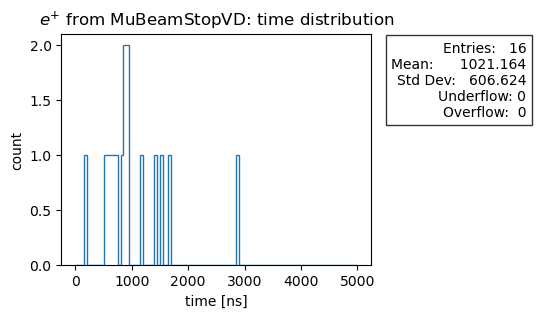

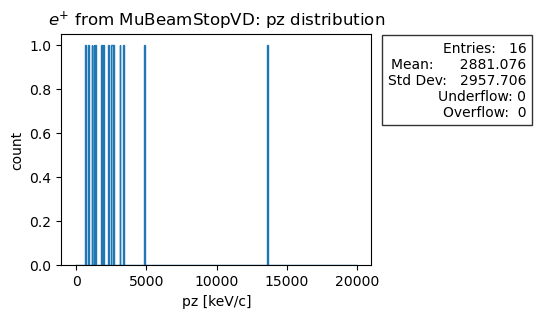

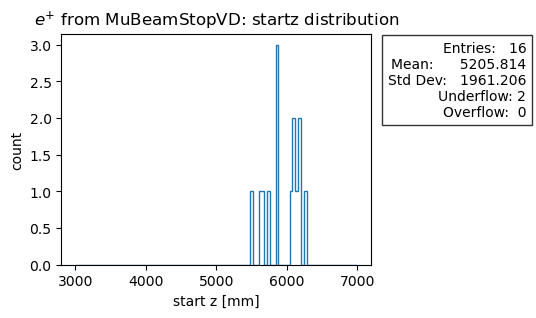

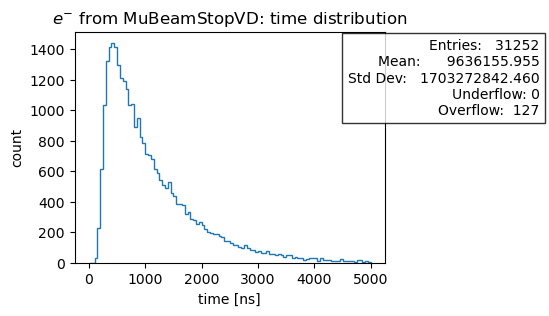

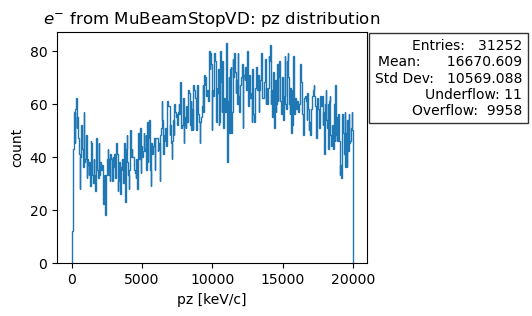

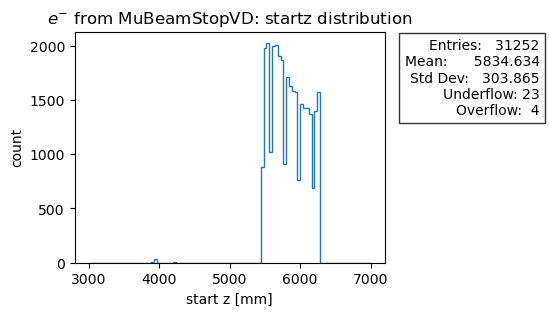

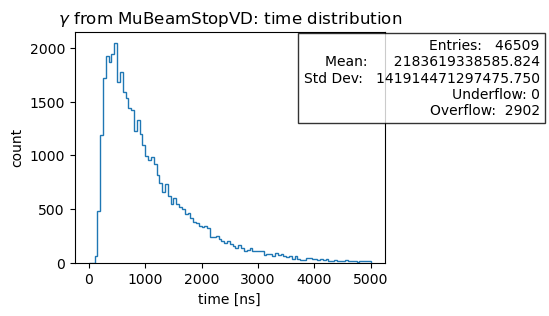

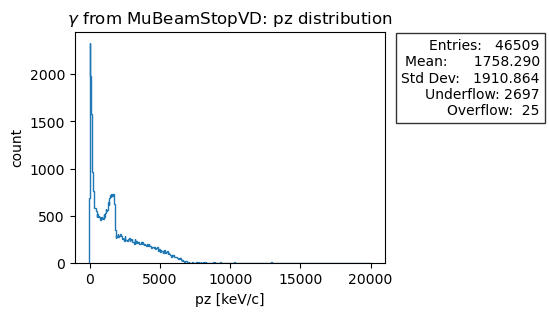

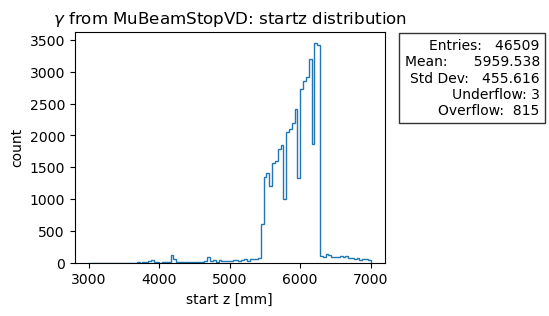

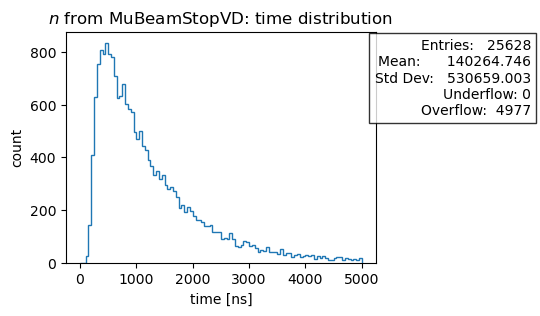

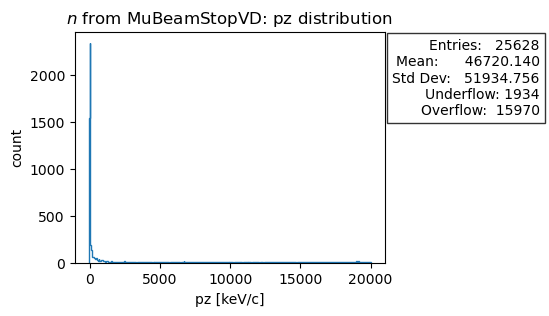

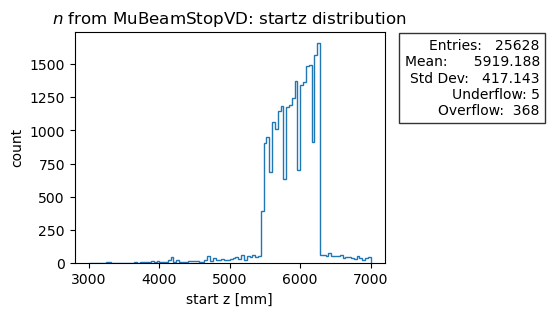

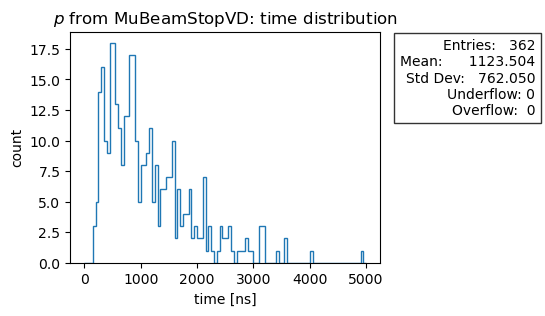

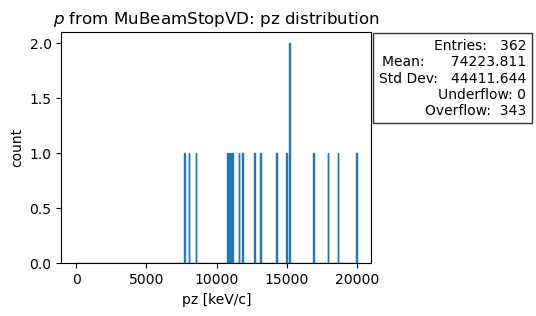

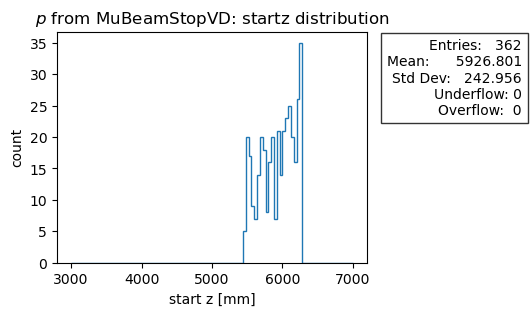

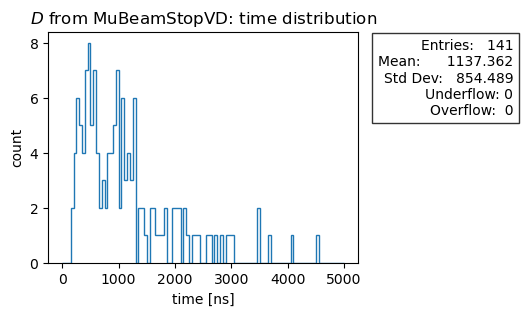

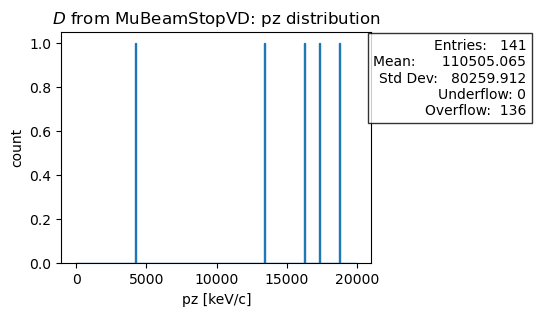

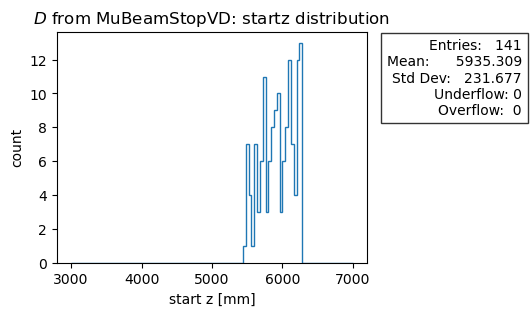

In [4]:
item_list = ['time', 'pz', 'startz']
title_list = [item+' distribution' for item in item_list]
xlabel_list = ['time [ns]', 'pz [keV/c]', 'start z [mm]']
ylabel_list = ['count' for item in item_list]

df_by_pdgid = {}

print("")
list_of_pdgId = np.sort(df_particles['pdgId'].unique())
for pdgId in list_of_pdgId:
    mydf1 = df_particles.query("pdgId==%i"%(pdgId)).reset_index(drop=True)
    mydf2 = df_source.query("pdgId==%i"%(pdgId)).reset_index(drop=True)
    df_by_pdgid.update({pdgId:[mydf1, mydf2]})
    group_name = pdgid_dict[pdgId]+' from '+tag+': '
    print(group_name, len(mydf1))
    for index, item in enumerate(item_list):
        fig, ax = plot_utils.single_hist(mydf1, item, [group_name+title_list[index], xlabel_list[index], ylabel_list[index]]) 

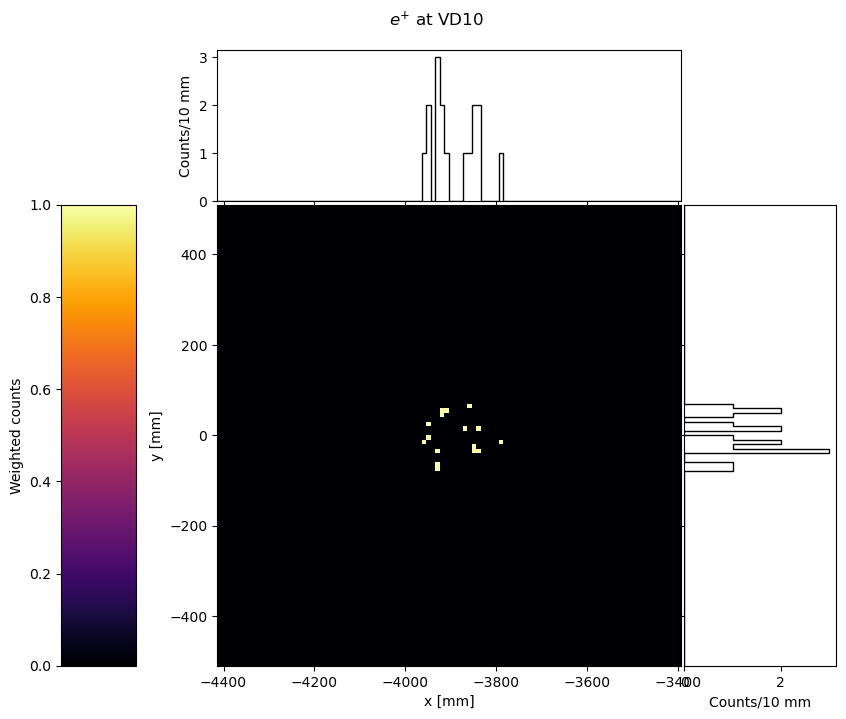

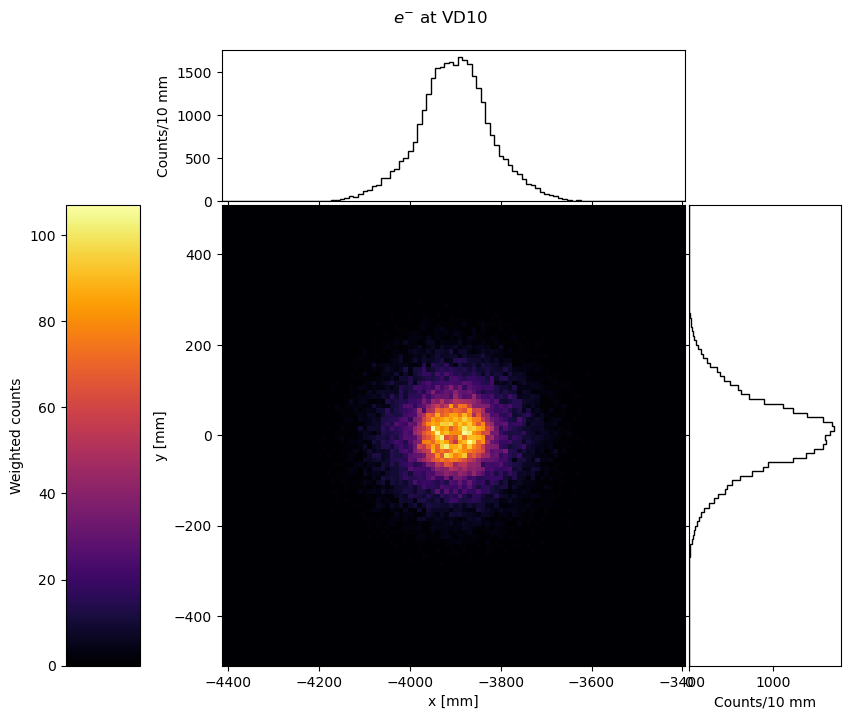

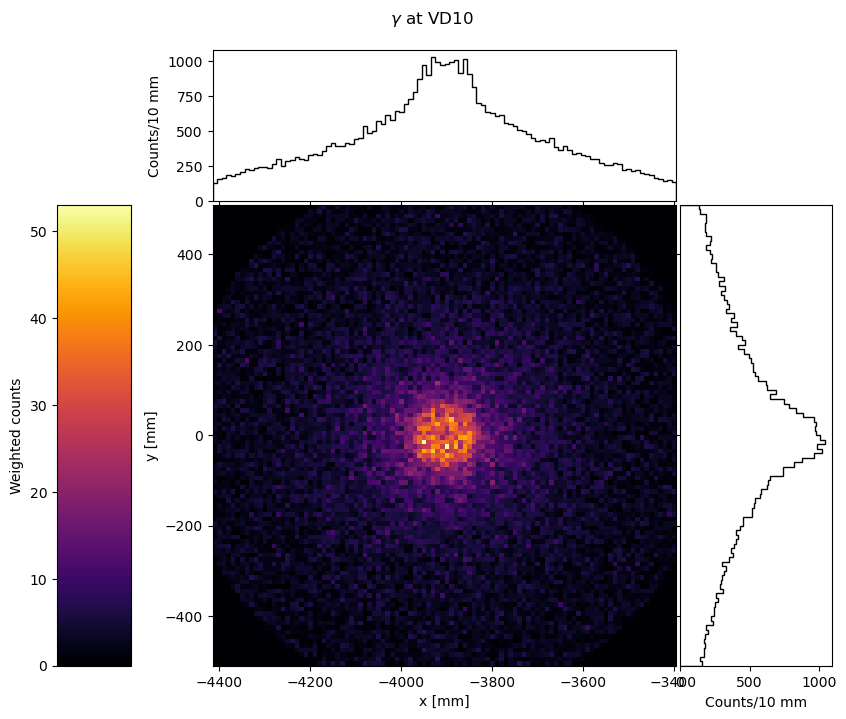

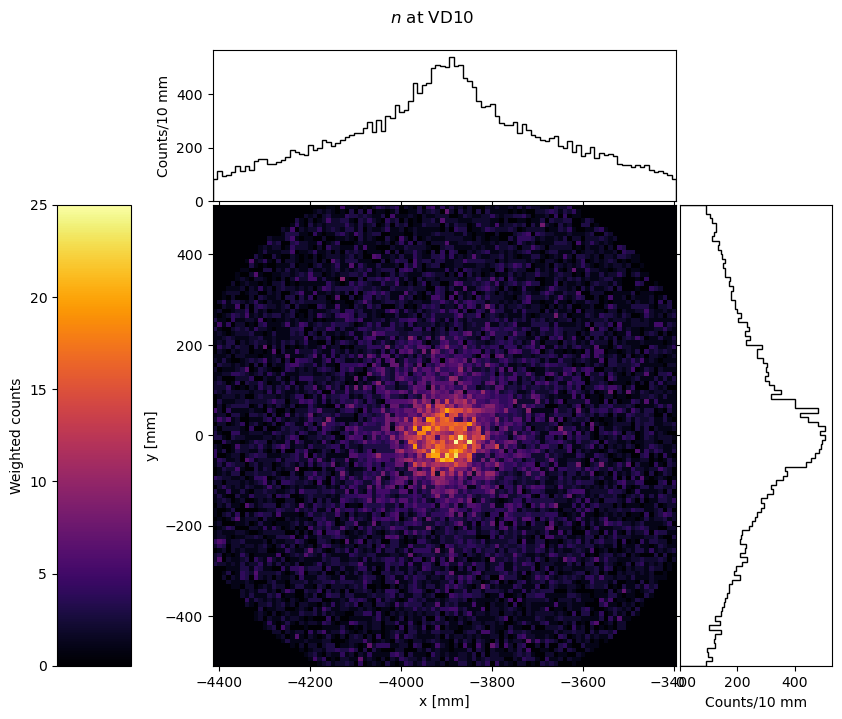

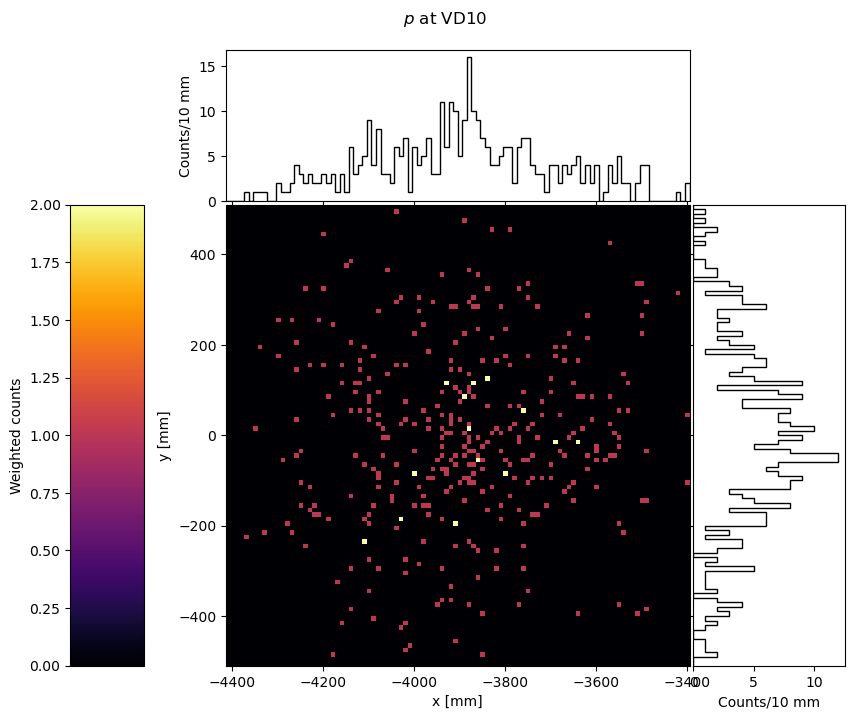

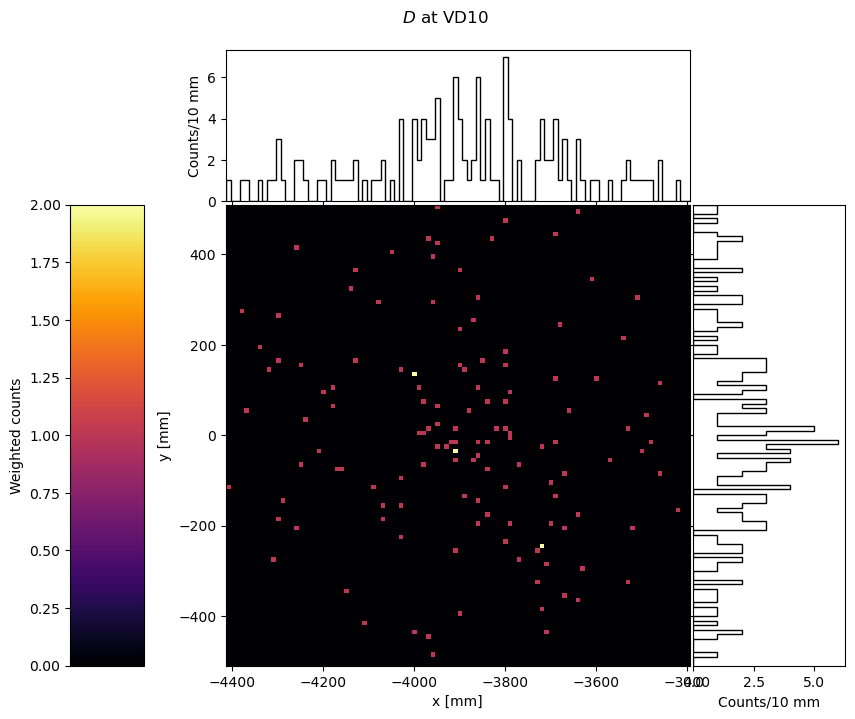

In [5]:
for pdgId in list_of_pdgId:
    fig, ax2d, axX, axY = plot_utils.particle_space_dist(df_by_pdgid[pdgId][0], pdgid_dict[pdgId]+" at VD10") 
    plt.show()

===================== -11 16
------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     6899.938513
creationCode                   13
index                         167
pdgId                         -11
px                   -5106.654066
py                   -2199.483323
pz                    4872.907854
startpx              -5113.937855
startpy               6351.876736
startpz              -1104.048848
starttime              611.904846
startx                -851.629573
starty                 -36.689518
startz                  90.077538
time                   691.237959
virtualdetectorId              10
x                     -3791.01838
y                      -11.818437
z                     6275.999996
weight                          1
r                      113.598072
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode               13
index                     167
parentendtime      611.904846
parentpdgId                22
starttime          611.904846
x                 -851.629573
y                  -36.689518
z                   90.077538
pdgId                     -11
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,22,-850.881714,-37.455960,91.269277,-11.469433,611.899475,-851.629573,-36.689518,90.077538,-11.469433,611.904846,16
1,11,-3862.710058,-3.460876,5826.534019,-19.235788,560.113953,-3654.337699,-240.353957,15489.831421,-0.000000,671.026245,166
2,13,-3820.657920,3.284215,4179.000000,31.855064,154.683823,-3862.710058,-3.460876,5826.534019,0.000000,174.749802,56
3,13,3377.978885,62.433282,-1166.677051,15.884077,31.674297,-3824.128839,12.885194,4196.174106,31.876493,154.885147,14
4,-211,3931.359146,-0.187421,-6060.352586,77.038559,-17.749430,3377.978885,62.433282,-1166.677051,49.117092,31.674297,101
5,2212,3931.925025,-0.185007,-6058.094992,-8624.851562,-17.757236,3931.359146,-0.187421,-6060.352586,-8615.820312,-17.749430,56


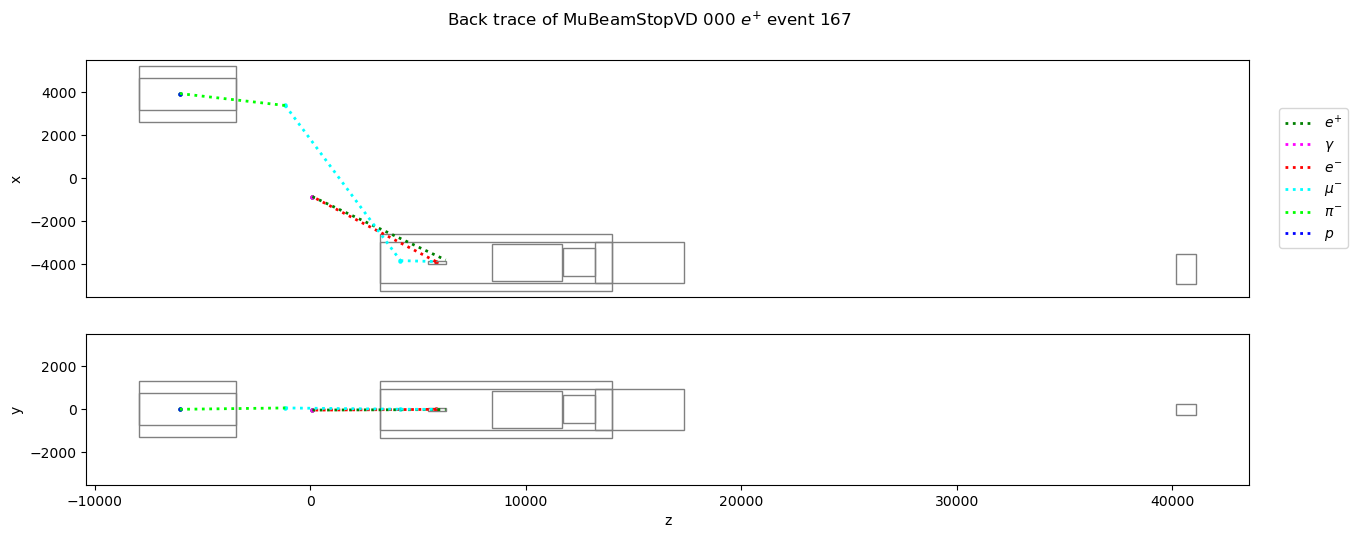

===================== 11 31252
------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                    24211.240749
creationCode                  166
index                           7
pdgId                          11
px                  -19375.045221
py                  -12954.093954
pz                    8229.646796
startpx             -26884.019852
startpy              10534.292221
startpz               -995.315313
starttime              636.499512
startx               -3946.827537
starty                  45.757676
startz                5715.478063
time                   658.631265
virtualdetectorId              10
x                    -3993.097419
y                       37.431581
z                     6275.999996
weight                          1
r                       96.640951
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              166
index                       7
parentendtime      333.456543
parentpdgId                13
starttime          636.499512
x                -3946.827537
y                   45.757676
z                 5715.478063
pdgId                      11
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3887.419881,19.194973,4179.000000,23.494358,309.394440,-3946.827537,45.757676,5715.478063,0.000000,333.456543,56
1,13,3874.014696,44.602372,-3995.130812,16.009974,67.345734,-3893.761176,32.262844,4192.677803,23.496645,309.610199,14
2,-211,3928.417739,0.340027,-6058.385409,53.136116,47.810589,3874.014696,44.602372,-3995.130812,58.253387,67.345734,101
3,2212,3928.691189,0.340455,-6057.288706,-8624.851562,47.806797,3928.417739,0.340027,-6058.385409,-8623.436523,47.810589,56


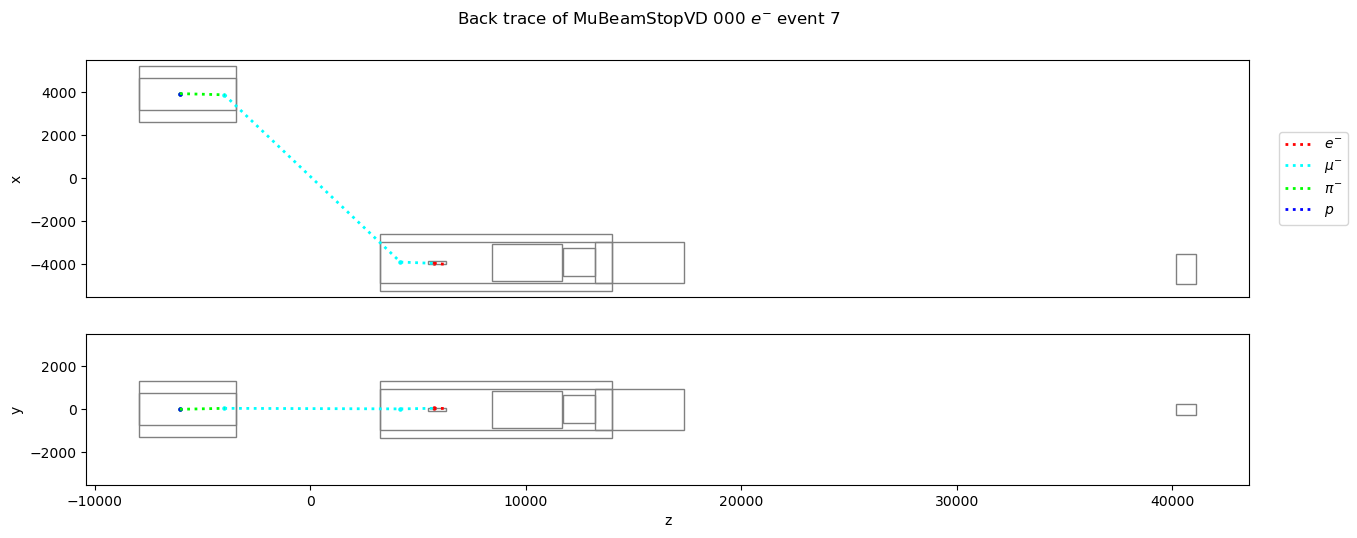

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     7768.818937
creationCode                  166
index                       13172
pdgId                          11
px                    3305.592152
py                    2385.091334
pz                    7188.787349
startpx               -8550.07267
startpy              -4722.121239
startpz              -6283.906937
starttime              393.515381
startx               -3900.387117
starty                  57.834072
startz                5493.176029
time                   459.126075
virtualdetectorId              10
x                     -3881.80487
y                       36.999413
z                     6275.999996
weight                          1
r                       43.146035
Name: 4000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              166
index                   13172
parentendtime      294.177734
parentpdgId                13
starttime          393.515381
x                -3900.387117
y                   57.834072
z                 5493.176029
pdgId                      11
Name: 4000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3885.650473,39.960918,4179.000000,14.936604,262.664124,-3900.387117,57.834072,5493.176029,0.000000,294.177734,56
1,13,3897.692231,40.045596,-5638.630266,18.227797,-39.856197,-3886.509839,51.457121,4195.211850,14.936940,263.052460,14
2,-211,3904.198415,0.912701,-6158.328239,7.948620,-50.212894,3897.692231,40.045596,-5638.630266,26.654627,-39.856197,101
3,2212,3930.071103,0.893690,-6057.632757,-8624.851562,-50.561646,3904.198415,0.912701,-6158.328239,-8457.373047,-50.212894,56


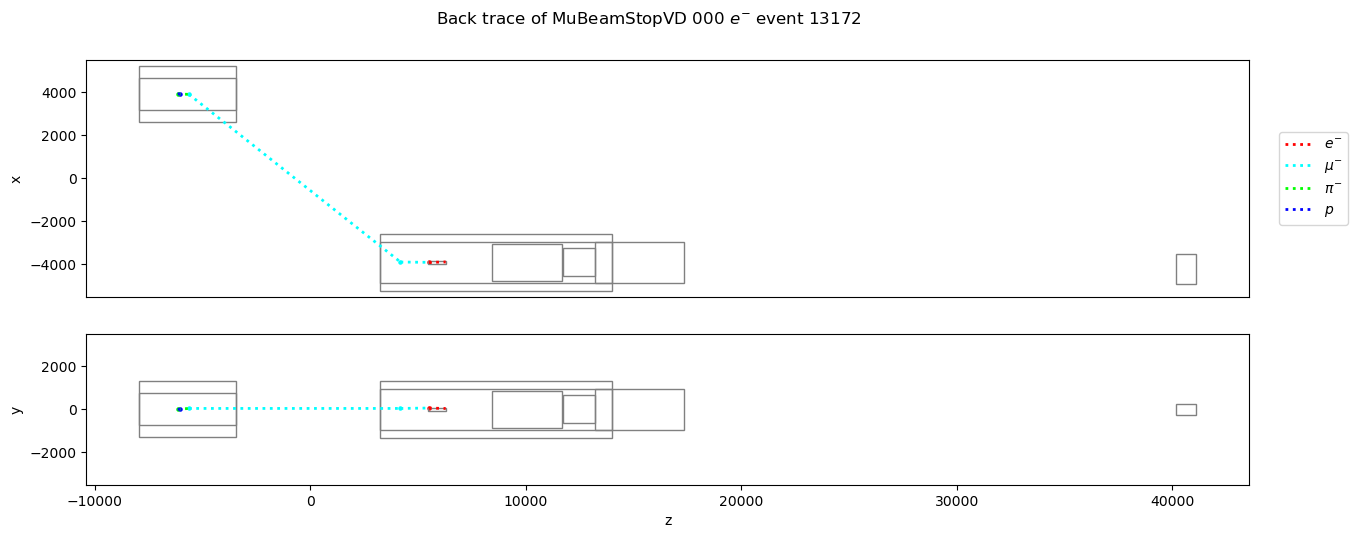

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                    51481.347312
creationCode                  166
index                       26321
pdgId                          11
px                   13043.103834
py                   21180.338816
pz                    45653.18867
startpx               2127.107382
startpy             -25374.200821
startpz              45335.170746
starttime             1228.216553
startx               -3839.402428
starty                 -23.333854
startz                6004.352515
time                  1229.254801
virtualdetectorId              10
x                    -3726.934033
y                      -49.337989
z                     6275.999996
weight                          1
r                      183.811299
Name: 8000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              166
index                   26321
parentendtime      142.015472
parentpdgId                13
starttime         1228.216553
x                -3839.402428
y                  -23.333854
z                 6004.352515
pdgId                      11
Name: 8000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3867.243181,-53.924209,4179.000000,37.185001,121.550552,-3839.402428,-23.333854,6004.352515,0.000000,142.015472,56
1,13,3923.859329,-12.817321,-5586.112297,38.330734,-27.648869,-3862.408333,-53.318787,4198.392878,37.194138,121.746063,14
2,-211,3883.882519,1.641804,-6243.398839,136.596420,-32.259071,3923.859329,-12.817321,-5586.112297,77.401100,-27.648869,101
3,2212,3931.769529,1.594231,-6058.056222,-8624.851562,-32.901276,3883.882519,1.641804,-6243.398839,-8308.565430,-32.259071,56


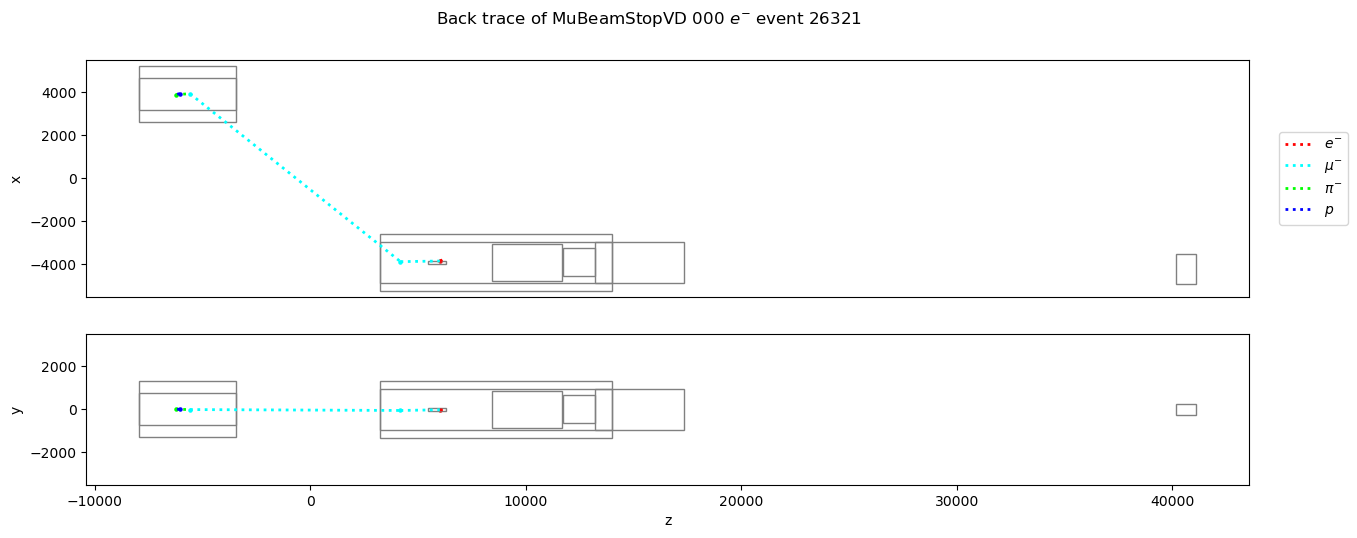

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     9739.238198
creationCode                  166
index                       39911
pdgId                          11
px                    1769.429047
py                    9144.226422
pz                    4249.527608
startpx              -4205.396175
startpy             -12493.985176
startpz               1392.585516
starttime              303.897247
startx               -3952.888725
starty                  26.203657
startz                5671.037161
time                   310.909975
virtualdetectorId              10
x                    -3915.383991
y                        3.948687
z                     6275.999996
weight                          1
r                       12.049372
Name: 12000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              166
index                   39911
parentendtime      223.750122
parentpdgId                13
starttime          303.897247
x                -3952.888725
y                   26.203657
z                 5671.037161
pdgId                      11
Name: 12000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3887.277087,32.731757,4179.000000,26.625984,203.013367,-3952.888725,26.203657,5671.037161,0.000000,223.750122,56
1,13,3914.235177,5.352550,-6105.554839,59.930279,-30.776634,-3891.746609,45.148547,4193.978620,26.629175,203.222549,14
2,-211,3917.287785,-0.502667,-6110.485631,75.036697,-30.816326,3914.235177,5.352550,-6105.554839,81.894432,-30.776634,101
3,2212,3930.386721,-0.434905,-6057.711449,-8624.851562,-30.998720,3917.287785,-0.502667,-6110.485631,-8555.944336,-30.816326,56


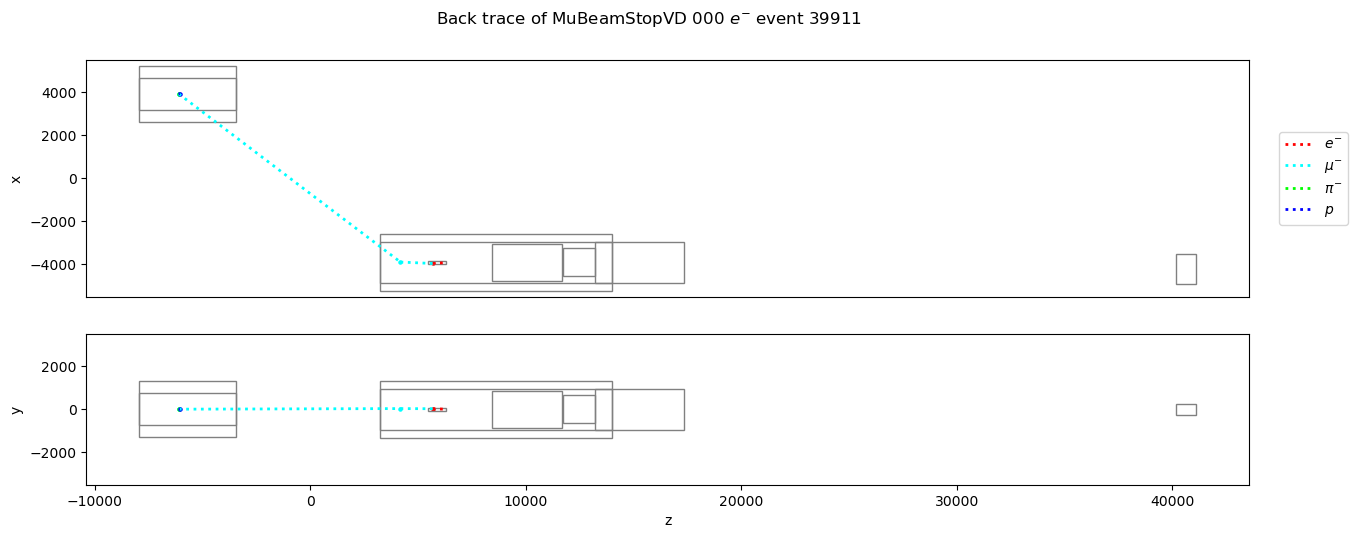

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                    15357.378585
creationCode                  166
index                       53177
pdgId                          11
px                    3585.266988
py                    13252.27867
pz                    7941.489476
startpx               8073.928833
startpy              13374.324799
startpz               4470.529556
starttime             1927.860229
startx               -3971.743139
starty                   3.086171
startz                6004.325981
time                   1930.26211
virtualdetectorId              10
x                    -3970.643169
y                       10.185104
z                     6275.999996
weight                          1
r                       67.416974
Name: 16000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              166
index                   53177
parentendtime      165.029129
parentpdgId                13
starttime         1927.860229
x                -3971.743139
y                    3.086171
z                 6004.325981
pdgId                      11
Name: 16000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3884.865964,-28.954170,4179.000000,36.508820,143.452179,-3971.743139,3.086171,6004.325981,0.000000,165.029129,56
1,13,3860.811832,-46.837107,-6248.934028,6.769908,-44.320015,-3877.440529,-20.314059,4195.416407,36.515652,143.624115,14
2,-211,3927.819244,-0.508895,-6060.257636,-16.267065,-48.404613,3860.811832,-46.837107,-6248.934028,-22.612724,-44.320015,101
3,2212,3928.568477,-0.506386,-6057.258110,-8624.851562,-48.414982,3927.819244,-0.508895,-6060.257636,-8613.429688,-48.404613,56


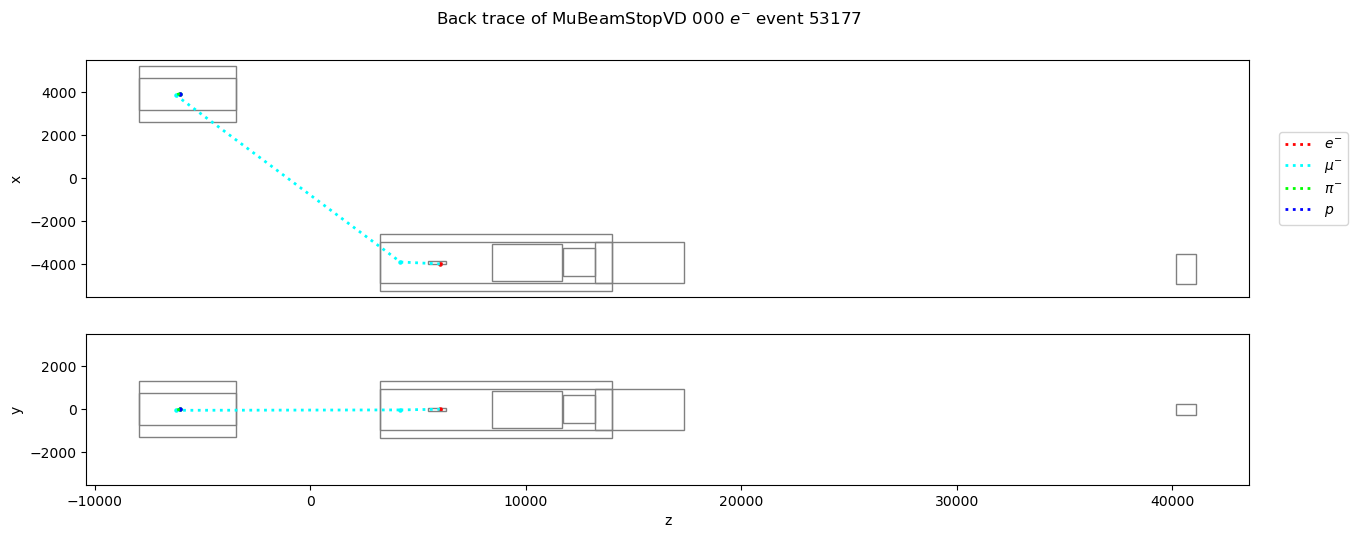

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                    50909.707549
creationCode                  166
index                       66412
pdgId                          11
px                    5245.146666
py                   26578.229967
pz                   43702.563554
startpx               -806.471109
startpy              28534.620285
startpz              43050.880432
starttime               309.06485
startx               -3930.889881
starty                  60.546649
startz                5671.045616
time                   311.448625
virtualdetectorId              10
x                    -3933.993135
y                       48.251198
z                     6275.999996
weight                          1
r                       56.813434
Name: 20000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              166
index                   66412
parentendtime      172.844162
parentpdgId                13
starttime           309.06485
x                -3930.889881
y                   60.546649
z                 5671.045616
pdgId                      11
Name: 20000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3936.834446,10.606253,4179.000000,27.207117,152.216797,-3930.889881,60.546649,5671.045616,0.000000,172.844162,56
1,13,3696.345239,13.639680,-1843.763482,34.962475,-1.801272,-3926.535155,6.137530,4195.513099,27.212147,152.440842,14
2,-211,3882.747706,-0.266362,-6250.593956,101.399788,-36.090923,3696.345239,13.639680,-1843.763482,76.700523,-1.801272,101
3,2212,3930.142877,-0.414720,-6057.650652,-8624.851562,-36.757469,3882.747706,-0.266362,-6250.593956,-8299.465820,-36.090923,56


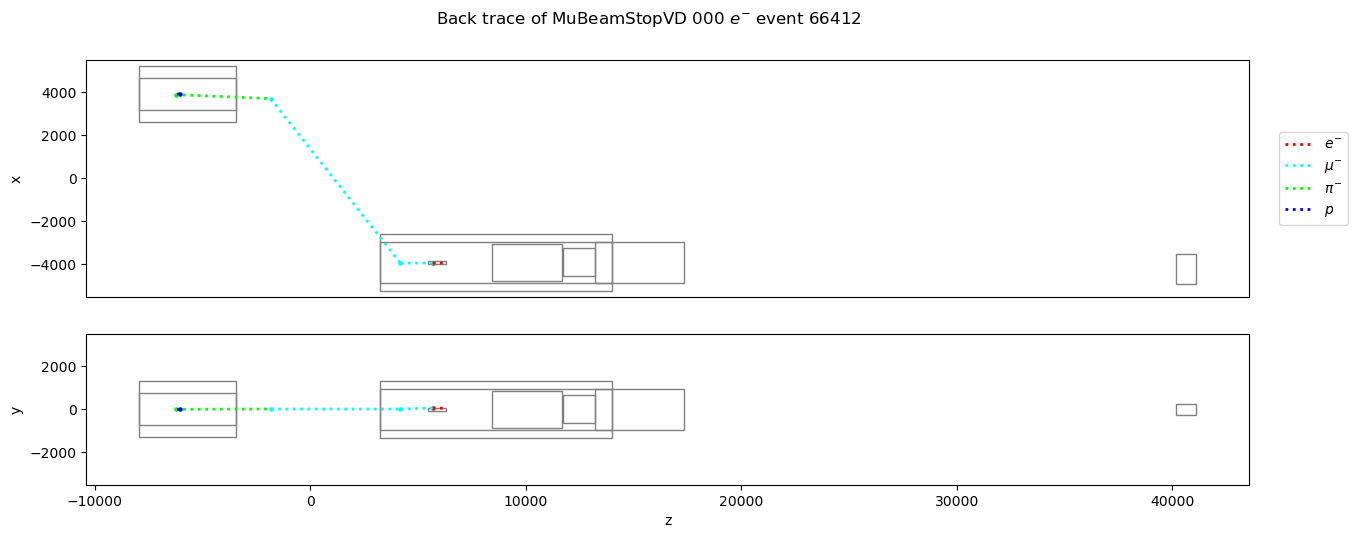

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                    50959.243139
creationCode                  166
index                       79958
pdgId                          11
px                  -18475.007647
py                  -44662.978523
pz                    17686.63729
startpx               42158.58078
startpy             -27957.906723
startpz              11078.202248
starttime              345.311157
startx               -3920.176162
starty                  64.285846
startz                5915.493624
time                    349.81755
virtualdetectorId              10
x                    -3959.834798
y                      207.019998
z                     6275.999996
weight                          1
r                       214.41736
Name: 24000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              166
index                   79958
parentendtime      200.272385
parentpdgId                13
starttime          345.311157
x                -3920.176162
y                   64.285846
z                 5915.493624
pdgId                      11
Name: 24000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3944.883775,25.611489,4179.000000,30.246286,178.240631,-3920.176162,64.285846,5915.493624,0.000000,200.272385,56
1,13,3882.060310,-7.058793,-5698.808314,20.799675,-16.055763,-3938.483021,16.742075,4195.714164,30.260260,178.446442,14
2,-211,3912.664400,0.085117,-6124.093268,43.831566,-23.893137,3882.060310,-7.058793,-5698.808314,33.769764,-16.055763,101
3,2212,3929.418095,-0.033473,-6057.469944,-8624.851562,-24.123573,3912.664400,0.085117,-6124.093268,-8536.998047,-23.893137,56


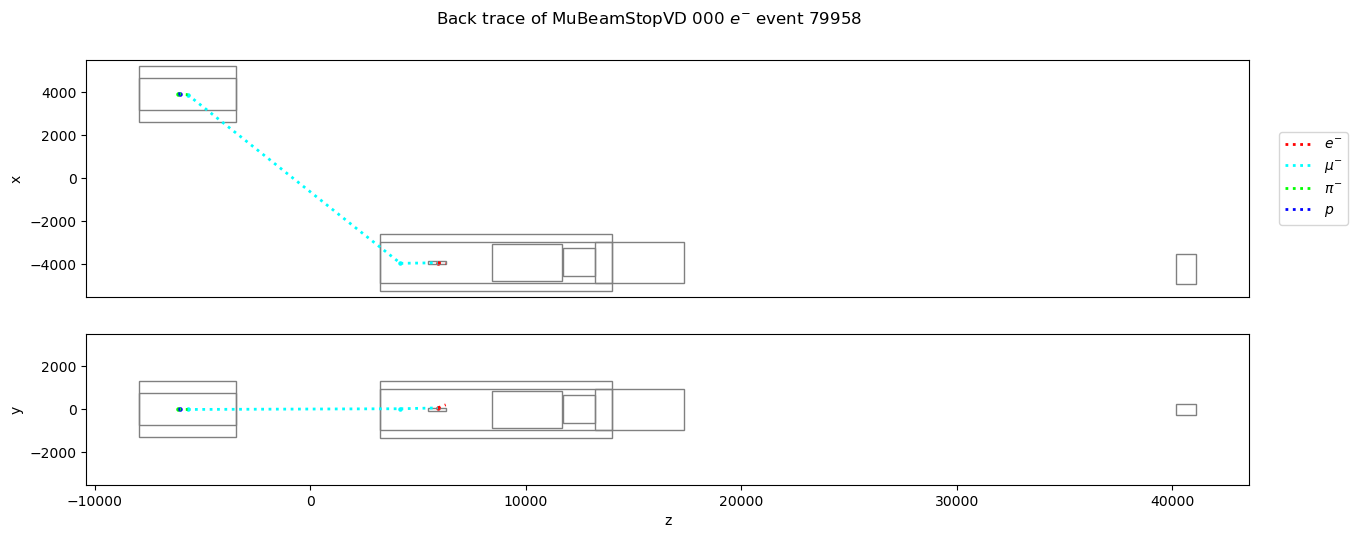

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     36421.05771
creationCode                  166
index                       93189
pdgId                          11
px                   15145.080896
py                   24795.452584
pz                   22793.151211
startpx               20537.36496
startpy             -26056.377411
startpz              20308.942795
starttime              716.005554
startx               -3931.640856
starty                 -12.210895
startz                5559.875276
time                    720.15958
virtualdetectorId              10
x                    -3813.363389
y                       -8.248706
z                     6275.999996
weight                          1
r                       91.011188
Name: 28000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              166
index                   93189
parentendtime       274.36731
parentpdgId                13
starttime          716.005554
x                -3931.640856
y                  -12.210895
z                 5559.875276
pdgId                      11
Name: 28000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3934.215424,-22.898410,4179.000000,17.036474,244.733917,-3931.640856,-12.210895,5559.875276,0.000000,274.367310,56
1,13,3895.570120,2.669035,-5598.160253,24.242050,-31.394310,-3926.754261,-29.024720,4196.438688,17.053577,245.100601,14
2,-211,3899.060301,2.136238,-6185.122821,60.455894,-36.818794,3895.570120,2.669035,-5598.160253,59.787754,-31.394310,101
3,2212,3930.052897,1.238947,-6057.628217,-8624.851562,-37.258961,3899.060301,2.136238,-6185.122821,-8429.739258,-36.818794,56


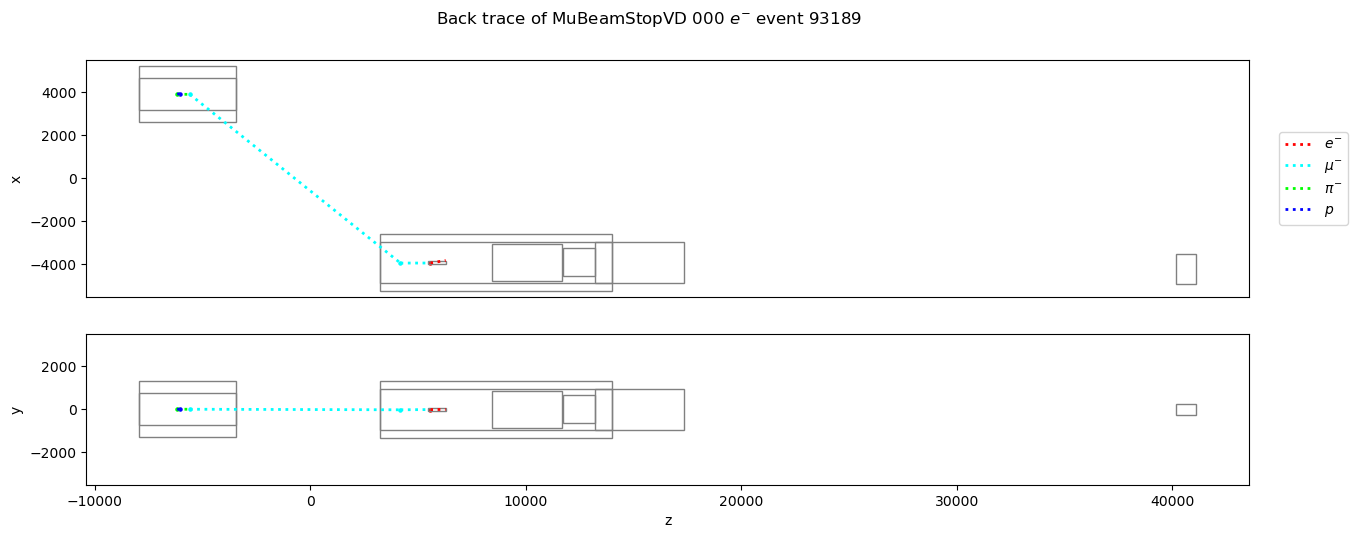

===================== 22 46509
------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      125.269321
creationCode                  165
index                           0
pdgId                          22
px                      72.829021
py                     -49.781729
pz                      88.938833
startpx              -5350.543022
startpy               2611.334562
startpz              -2308.610201
starttime             1068.434692
startx               -3856.730912
starty                   31.08142
startz                6182.104168
time                  1074.324171
virtualdetectorId              10
x                    -4331.922979
y                      205.344901
z                     6275.999996
weight                          1
r                      474.641553
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                       0
parentendtime      201.633743
parentpdgId                13
starttime         1068.434692
x                -3856.730912
y                    31.08142
z                 6182.104168
pdgId                      22
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3808.046160,30.729806,4179.000000,29.394709,175.733734,-3856.730912,31.081420,6182.104168,0.000000,201.633743,56
1,13,3649.825694,30.022608,-1750.111782,37.534363,30.911488,-3809.718072,44.503803,4193.361123,29.432600,175.918289,14
2,-211,3888.466980,-3.015745,-6225.889944,79.806976,-15.168916,3649.825694,30.022608,-1750.111782,41.041828,30.911488,101
3,2212,3931.599255,-1.823600,-6058.013768,-8624.851562,-15.750401,3888.466980,-3.015745,-6225.889944,-8347.211914,-15.168916,56


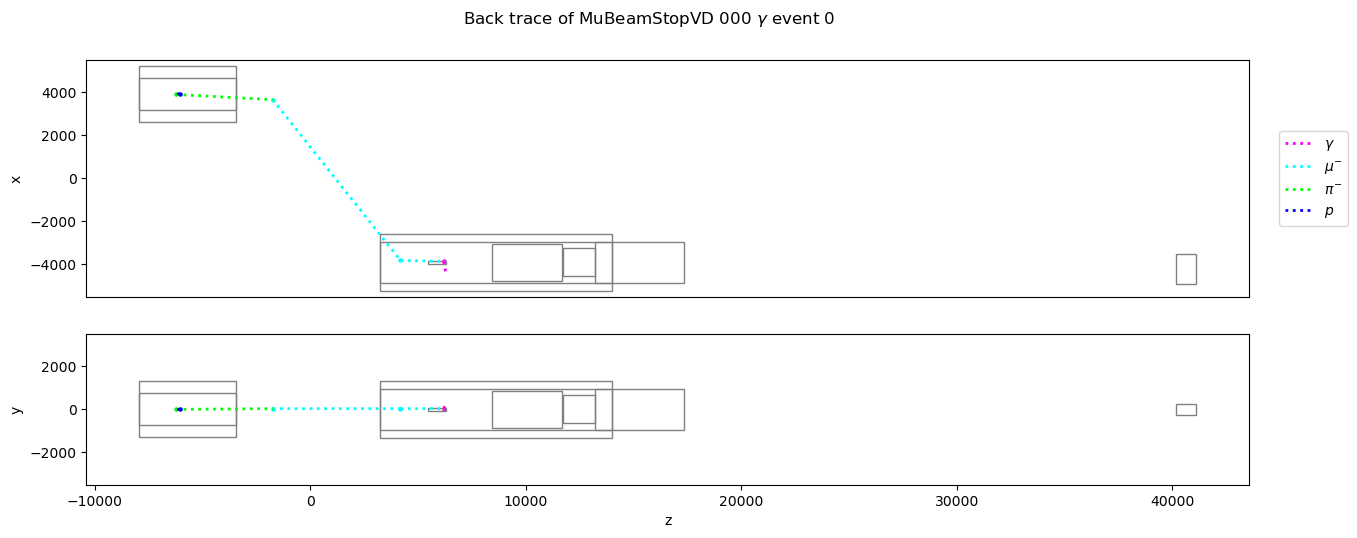

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1294.336694
creationCode                  165
index                        9010
pdgId                          22
px                     185.053033
py                     369.938457
pz                    1226.461736
startpx                185.053036
startpy                369.938463
startpz               1226.461768
starttime              657.730957
startx               -3899.767974
starty                  65.402871
startz                5782.076508
time                   659.469717
virtualdetectorId              10
x                    -3825.242992
y                      214.385336
z                     6275.999996
weight                          1
r                      228.393824
Name: 4000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                    9010
parentendtime      401.864441
parentpdgId                13
starttime          657.730957
x                -3899.767974
y                   65.402871
z                 5782.076508
pdgId                      22
Name: 4000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3868.857733,79.341733,4179.000000,17.731653,367.674561,-3899.767974,65.402871,5782.076508,0.000000,401.864441,56
1,13,3949.544872,37.181403,-5048.396494,11.097610,75.558426,-3870.513890,91.802659,4194.451487,17.742298,367.988770,14
2,-211,3925.825869,-7.542934,-6213.171845,5.545976,44.722466,3949.544872,37.181403,-5048.396494,36.884033,75.558426,14
3,3122,3901.084797,0.643780,-6180.421511,-401.920105,44.388626,3925.825869,-7.542934,-6213.171845,-401.920105,44.722466,14
4,3212,3901.084797,0.643780,-6180.421511,-399.134216,44.388626,3901.084797,0.643780,-6180.421511,-399.134216,44.388626,101
5,2212,3930.830554,-0.823749,-6057.822109,-8624.851562,43.965374,3901.084797,0.643780,-6180.421511,-8402.305664,44.388626,56


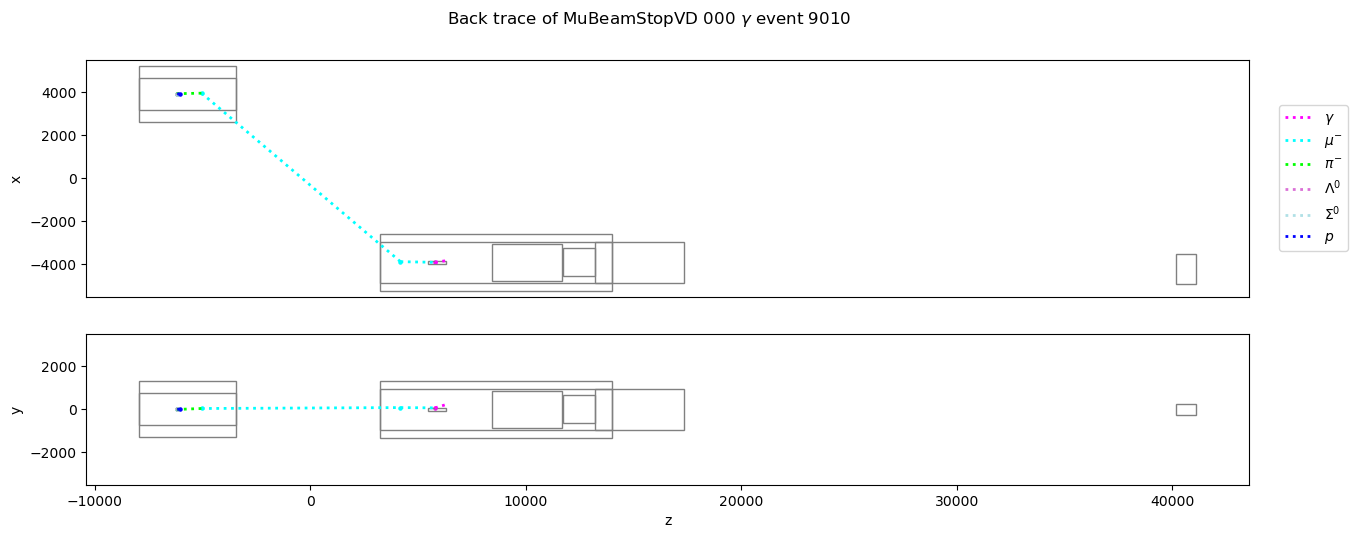

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      659.662056
creationCode                  165
index                       18043
pdgId                          22
px                    -390.363841
py                    -323.664605
pz                     421.913881
startpx               -390.363842
startpy               -323.664606
startpz                421.913892
starttime             2360.533447
startx               -3965.815014
starty                  35.658034
startz                5959.937316
time                  2362.181918
virtualdetectorId              10
x                    -4258.243037
y                     -206.804486
z                     6275.999996
weight                          1
r                      410.190473
Name: 8000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   18043
parentendtime      231.699295
parentpdgId                13
starttime         2360.533447
x                -3965.815014
y                   35.658034
z                 5959.937316
pdgId                      22
Name: 8000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3975.500623,22.281926,4179.000000,30.066072,207.869003,-3965.815014,35.658034,5959.937316,0.000000,231.699295,56
1,13,3833.353448,-0.811722,-4848.205022,3.911351,-11.807243,-3982.346389,9.346479,4192.587854,30.113796,208.041565,14
2,-211,3918.249682,0.538672,-6108.282464,9.238196,-39.924164,3833.353448,-0.811722,-4848.205022,28.619938,-11.807243,101
3,2212,3930.649268,0.329052,-6057.776910,-8624.851562,-40.098606,3918.249682,0.538672,-6108.282464,-8569.192383,-39.924164,56


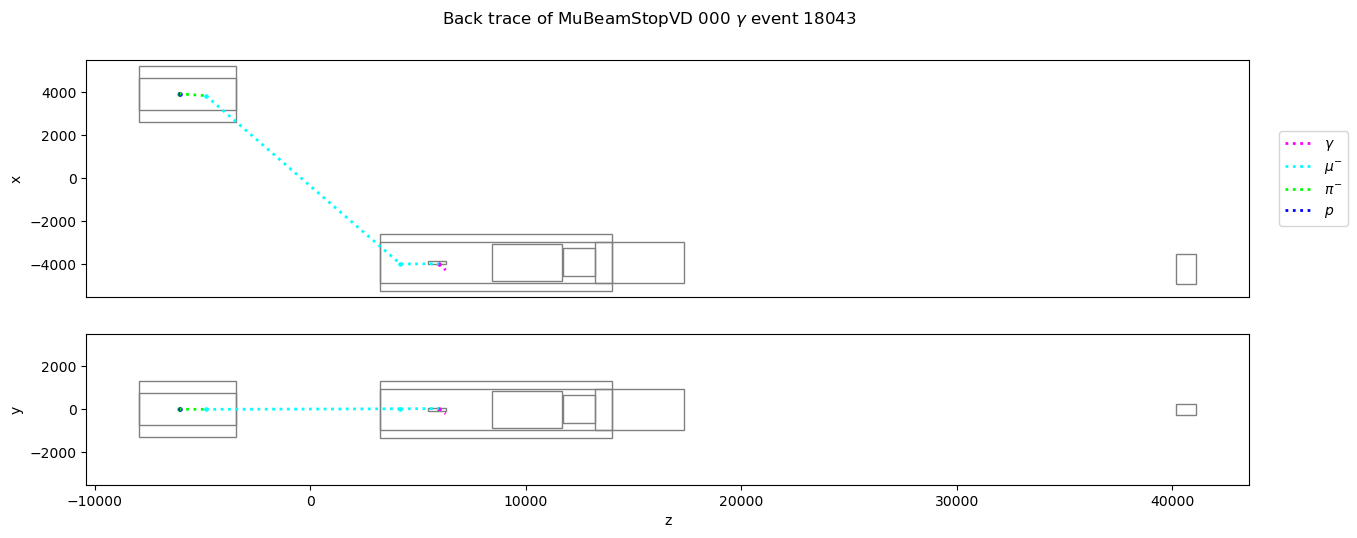

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     5269.279593
creationCode                  165
index                       27136
pdgId                          22
px                   -1504.639472
py                    1415.986174
pz                    4847.303441
startpx              -1504.639506
startpy                1415.98618
startpz               4847.303391
starttime              520.365662
startx               -3860.969234
starty                 -36.933494
startz                5537.657993
time                   523.042932
virtualdetectorId              10
x                    -4090.156149
y                      178.749737
z                     6275.999996
weight                          1
r                      258.080569
Name: 12000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   27136
parentendtime      345.340698
parentpdgId                13
starttime          520.365662
x                -3860.969234
y                  -36.933494
z                 5537.657993
pdgId                      22
Name: 12000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3919.737684,-44.836363,4179.000000,20.038342,321.004486,-3860.969234,-36.933494,5537.657993,0.000000,345.340698,56
1,13,3929.062437,-7.474745,-6017.161251,0.865821,13.309930,-3913.246368,-55.302405,4194.678206,20.062084,321.288025,14
2,-211,3929.761410,-0.535746,-6060.389179,-21.037399,6.346832,3929.062437,-7.474745,-6017.161251,4.127875,13.309930,101
3,2212,3930.427871,-0.536086,-6057.721709,-8624.851562,6.337610,3929.761410,-0.535746,-6060.389179,-8618.728516,6.346832,56


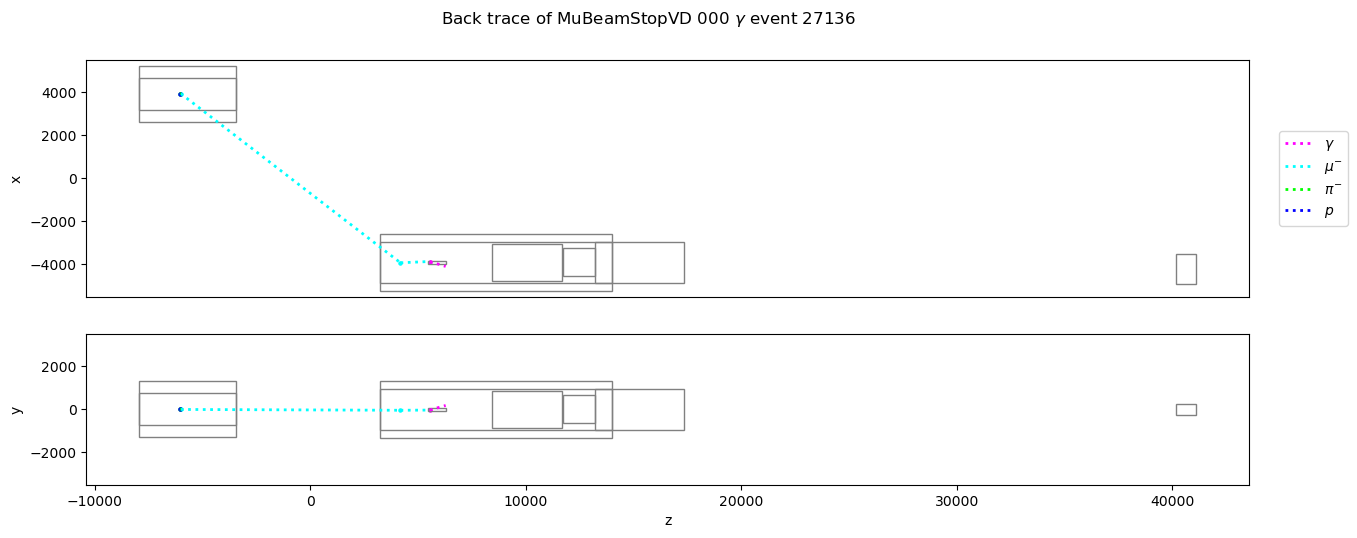

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     5451.470877
creationCode                  165
index                       36035
pdgId                          22
px                   -3130.493668
py                     -40.620971
pz                    4462.834755
startpx              -3130.493641
startpy                -40.620971
startpz               4462.834835
starttime              365.300934
startx               -3905.044782
starty                  -56.88763
startz                5959.889149
time                   366.588957
virtualdetectorId              10
x                    -4126.783443
y                      -59.764889
z                     6275.999996
weight                          1
r                      230.660583
Name: 16000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   36035
parentendtime      295.431244
parentpdgId                13
starttime          365.300934
x                -3905.044782
y                   -56.88763
z                 5959.889149
pdgId                      22
Name: 16000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3879.864976,-11.710491,4179.000000,20.895548,263.936096,-3905.044782,-56.887630,5959.889149,0.000000,295.431244,56
1,13,1605.527064,86.418338,-59.733032,-24.570057,87.568588,-3893.955794,-2.956357,4190.077574,20.891212,264.134521,14
2,-211,3913.620350,-0.187772,-6126.063326,-29.099983,8.361798,1605.527064,86.418338,-59.733032,0.716439,87.568588,101
3,2212,3930.784531,-0.327284,-6057.810634,-8624.851562,8.125725,3913.620350,-0.187772,-6126.063326,-8528.825195,8.361798,56


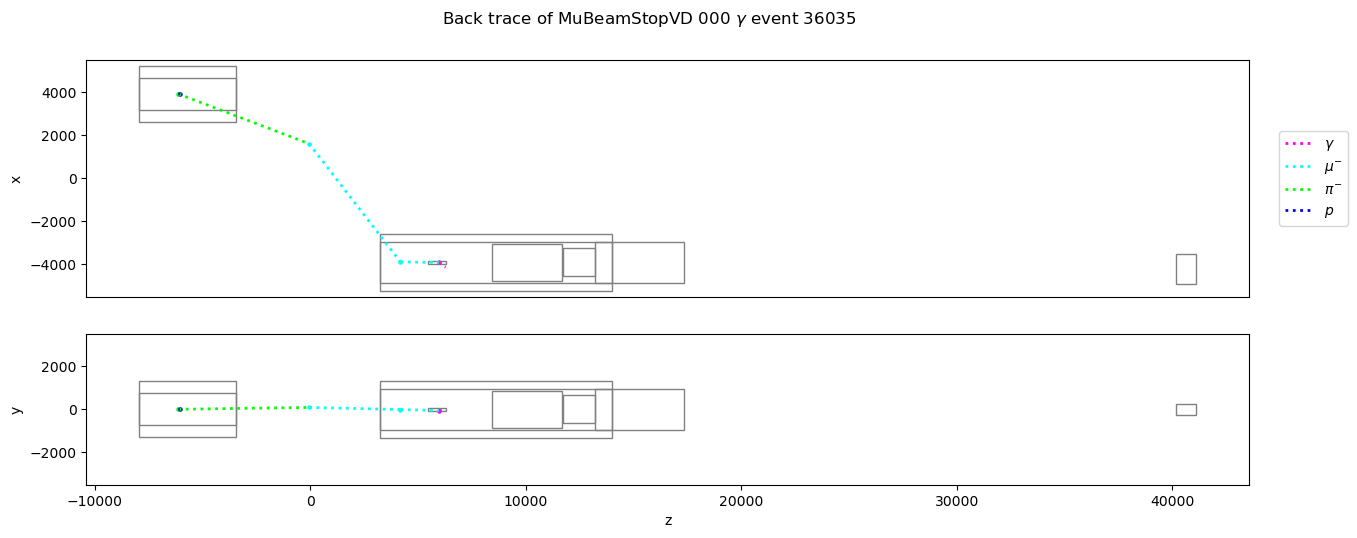

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     2246.518335
creationCode                  165
index                       44958
pdgId                          22
px                   -1411.264193
py                     1165.69776
pz                    1302.431088
startpx              -1411.264181
startpy               1165.697813
startpz               1302.431107
starttime              728.161987
startx               -3855.587003
starty                 -11.903027
startz                 6159.92868
time                   728.829813
virtualdetectorId              10
x                    -3981.357414
y                       91.982757
z                     6275.999996
weight                          1
r                      120.187341
Name: 20000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   44958
parentendtime      257.568848
parentpdgId                13
starttime          728.161987
x                -3855.587003
y                  -11.903027
z                  6159.92868
pdgId                      22
Name: 20000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3885.419169,-10.520412,4179.000000,27.858212,229.666748,-3855.587003,-11.903027,6159.928680,0.000000,257.568848,56
1,13,278.169807,108.638423,21.358577,-18.573261,126.696152,-3888.787655,-24.712612,4192.632880,27.858742,229.851669,14
2,-211,3919.243104,-0.381802,-6105.047890,162.682037,43.363220,278.169807,108.638423,21.358577,-2.223665,126.696152,101
3,2212,3931.068187,-0.251242,-6057.881358,-8624.851562,43.200111,3919.243104,-0.381802,-6105.047890,-8560.629883,43.363220,56


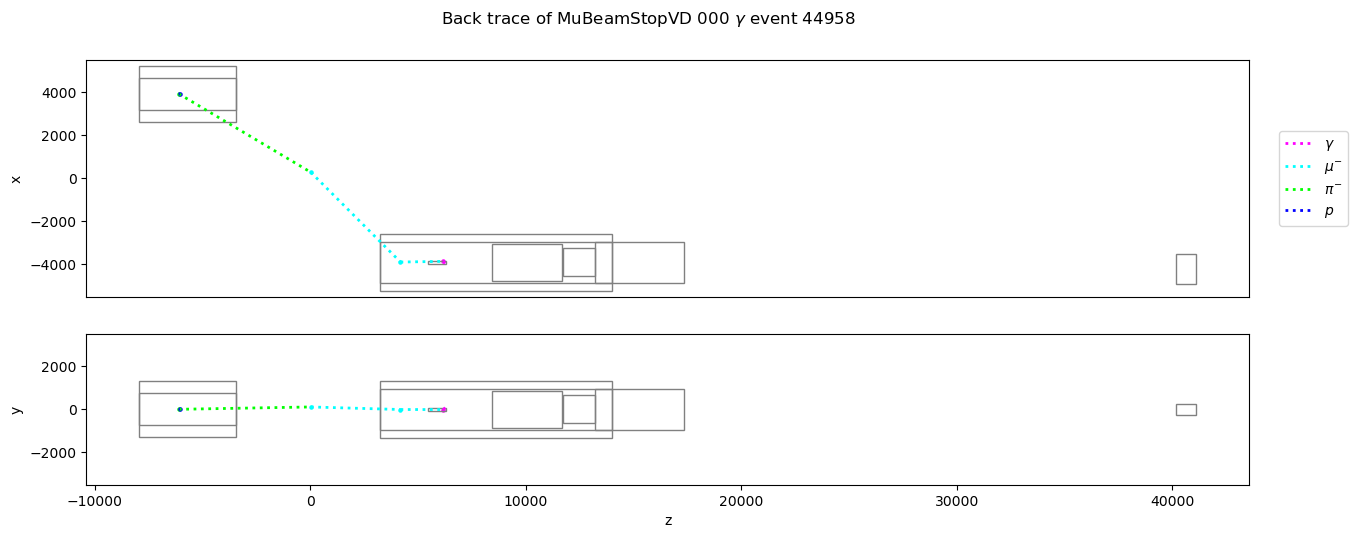

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       1874.3561
creationCode                  165
index                       53868
pdgId                          22
px                    1029.975326
py                     199.461353
pz                    1553.247174
startpx               1029.975295
startpy                199.461356
startpz               1553.247213
starttime             2016.290283
startx               -3842.261476
starty                 -29.020946
startz                5648.808099
time                  2018.814898
virtualdetectorId              10
x                    -3426.363614
y                       51.520353
z                     6275.999996
weight                          1
r                      480.406977
Name: 24000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   53868
parentendtime      194.105423
parentpdgId                13
starttime         2016.290283
x                -3842.261476
y                  -29.020946
z                 5648.808099
pdgId                      22
Name: 24000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3899.300276,-22.381689,4179.000000,27.328878,173.922882,-3842.261476,-29.020946,5648.808099,0.000000,194.105423,56
1,13,3951.719337,-14.851110,-4338.356269,30.647316,-3.414868,-3895.125776,-31.082559,4196.488171,27.337269,174.158051,14
2,-211,3930.310449,-1.260428,-6058.708151,7.295217,-21.147732,3951.719337,-14.851110,-4338.356269,50.202660,-3.414868,96
3,3122,3930.606631,-1.323054,-6058.381385,-438.049408,-21.150881,3930.310449,-1.260428,-6058.708151,-438.049408,-21.147732,14
4,3212,3930.606631,-1.323054,-6058.381385,-394.753235,-21.150881,3930.606631,-1.323054,-6058.381385,-394.753235,-21.150881,101
5,2212,3930.750938,-1.323058,-6057.802259,-8624.851562,-21.152882,3930.606631,-1.323054,-6058.381385,-8623.546875,-21.150881,56


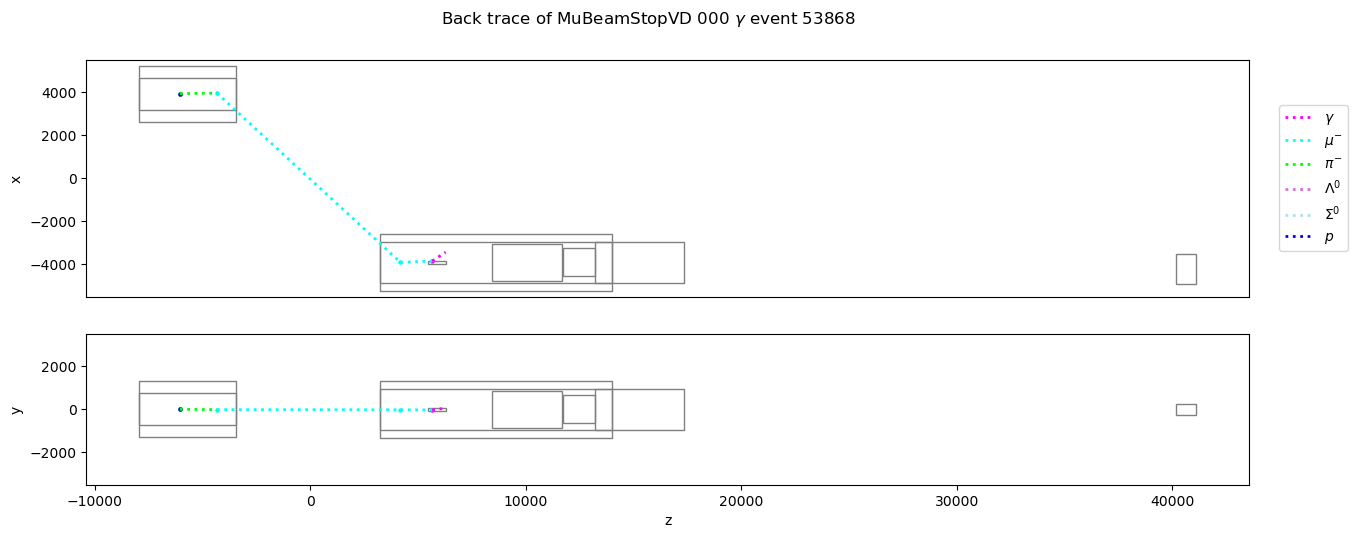

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      696.118517
creationCode                  165
index                       62751
pdgId                          22
px                      109.73617
py                     212.008284
pz                     653.904772
startpx               4185.901642
startpy               1431.118608
startpz                643.057406
starttime             1505.843994
startx               -3954.090653
starty                 -17.633914
startz                5493.171335
time                  1508.624439
virtualdetectorId              10
x                    -3822.526309
y                      236.231671
z                     6275.999996
weight                          1
r                      249.886704
Name: 28000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   62751
parentendtime      315.392395
parentpdgId                13
starttime         1505.843994
x                -3954.090653
y                  -17.633914
z                 5493.171335
pdgId                      22
Name: 28000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3937.593880,-21.929000,4179.000000,16.946423,286.464661,-3954.090653,-17.633914,5493.171335,0.000000,315.392395,56
1,13,3847.962896,-56.324020,-6287.953408,8.914536,7.363089,-3935.869308,-17.617865,4198.433023,16.939520,286.874359,14
2,-211,3930.102113,-0.648077,-6062.637368,-19.552153,-1.493362,3847.962896,-56.324020,-6287.953408,-10.312417,7.363089,101
3,2212,3931.269283,-0.644329,-6057.931497,-8624.851562,-1.509625,3930.102113,-0.648077,-6062.637368,-8616.477539,-1.493362,56


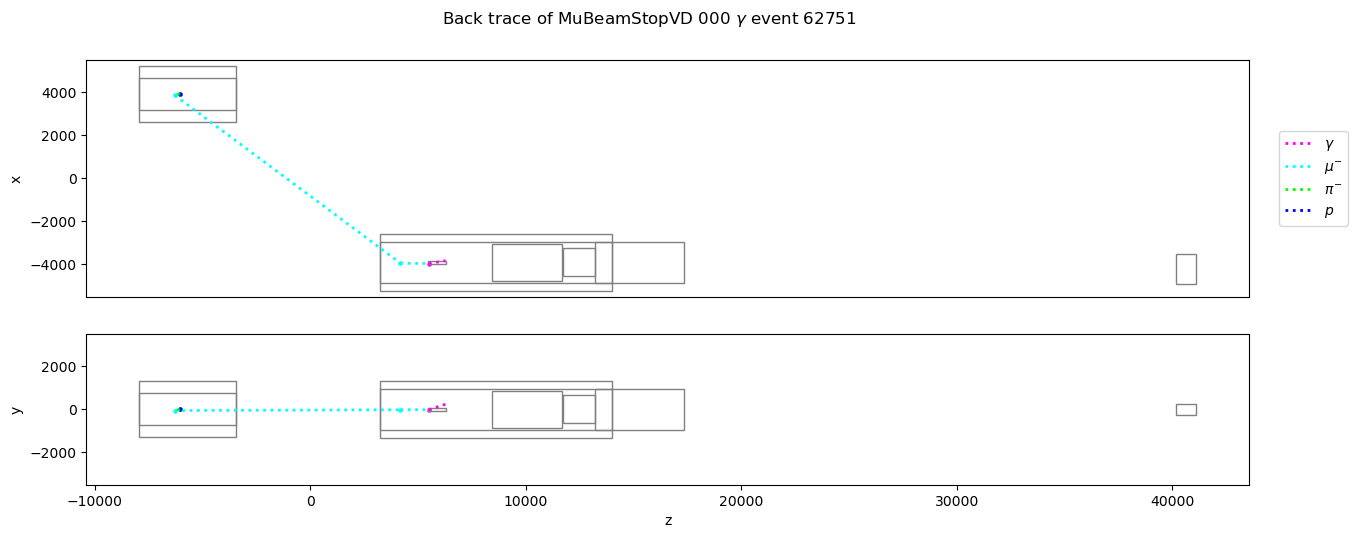

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      335.070447
creationCode                    2
index                       71640
pdgId                          22
px                    -136.413081
py                    -246.100126
pz                     181.929669
startpx                 32.574642
startpy               -508.882523
startpz                 33.126716
starttime              398.873383
startx                -3483.47889
starty                 998.230508
startz                5824.758138
time                    404.55216
virtualdetectorId              10
x                     -4149.37953
y                     -320.978723
z                     6275.999996
weight                          1
r                      404.027789
Name: 32000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode                2
index                   71640
parentendtime      398.873383
parentpdgId               -11
starttime          398.873383
x                 -3483.47889
y                  998.230508
z                 5824.758138
pdgId                      22
Name: 32000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,-11,-3483.185015,998.133006,5824.562972,0.587098,398.871979,-3483.478890,998.230508,5824.758138,0.000000,398.873383,13
1,22,-3422.119390,965.037699,5827.834243,-0.150479,398.640015,-3483.185015,998.133006,5824.562972,-0.150479,398.871979,97
2,2112,-3426.845457,968.729928,5826.535550,22.301558,398.456390,-3422.119390,965.037699,5827.834243,22.301558,398.640015,97
3,2112,-3868.066273,26.281194,5759.863812,15.170233,384.250122,-3426.845457,968.729928,5826.535550,15.170233,398.456390,165
4,13,-3895.067227,32.984511,4179.000000,27.992653,143.638412,-3868.066273,26.281194,5759.863812,0.000000,165.547714,56
5,13,3927.668749,22.144378,-4971.381378,30.545359,-41.109661,-3904.244787,26.387693,4195.463734,28.006060,143.856125,14
6,-211,3892.418063,11.850609,-6187.549199,85.079269,-49.681419,3927.668749,22.144378,-4971.381378,81.651749,-41.109661,14
7,3122,3896.657001,1.396541,-6197.251718,125.726013,-49.972874,3892.418063,11.850609,-6187.549199,125.726013,-49.681419,99
8,211,3897.551026,1.459984,-6192.968672,-2915.837158,-49.987488,3896.657001,1.396541,-6197.251718,-2904.267090,-49.972874,101
9,2212,3930.402156,1.251226,-6057.715298,-8624.851562,-50.454399,3897.551026,1.459984,-6192.968672,-8453.590820,-49.987488,56


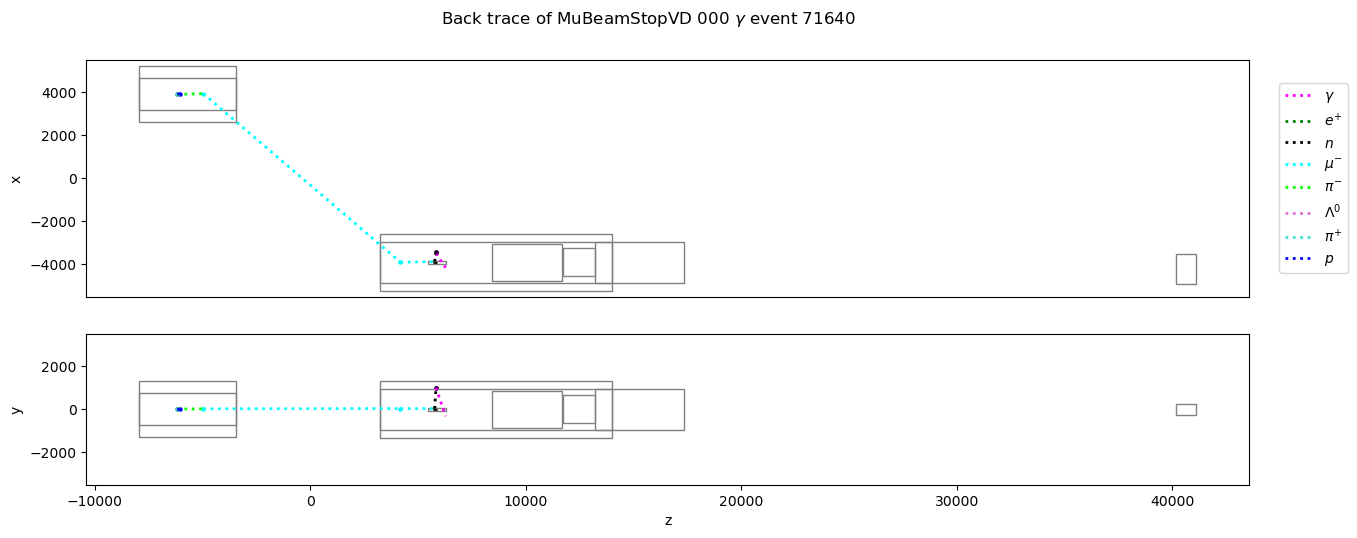

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      698.589664
creationCode                  165
index                       80456
pdgId                          22
px                    -588.661977
py                      76.824967
pz                     368.242473
startpx               -588.661969
startpy                 76.824971
startpz                368.242472
starttime              300.787079
startx               -3893.516685
starty                   44.53518
startz                6026.510818
time                    302.36585
virtualdetectorId              10
x                    -4292.343012
y                       96.585118
z                     6275.999996
weight                          1
r                      400.173687
Name: 36000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   80456
parentendtime      268.627777
parentpdgId                13
starttime          300.787079
x                -3893.516685
y                    44.53518
z                 6026.510818
pdgId                      22
Name: 36000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3941.975863,75.169835,4179.000000,33.555618,245.826477,-3893.516685,44.535180,6026.510818,0.000000,268.627777,56
1,13,3920.452840,11.182928,-6075.580032,0.307962,56.010700,-3952.254372,68.233013,4194.662983,33.596371,246.003906,14
2,-211,3918.603611,1.364497,-6105.580924,-19.105579,53.422192,3920.452840,11.182928,-6075.580032,7.488862,56.010700,101
3,2212,3930.580647,1.307277,-6057.759800,-8624.851562,53.256828,3918.603611,1.364497,-6105.580924,-8552.921875,53.422192,56


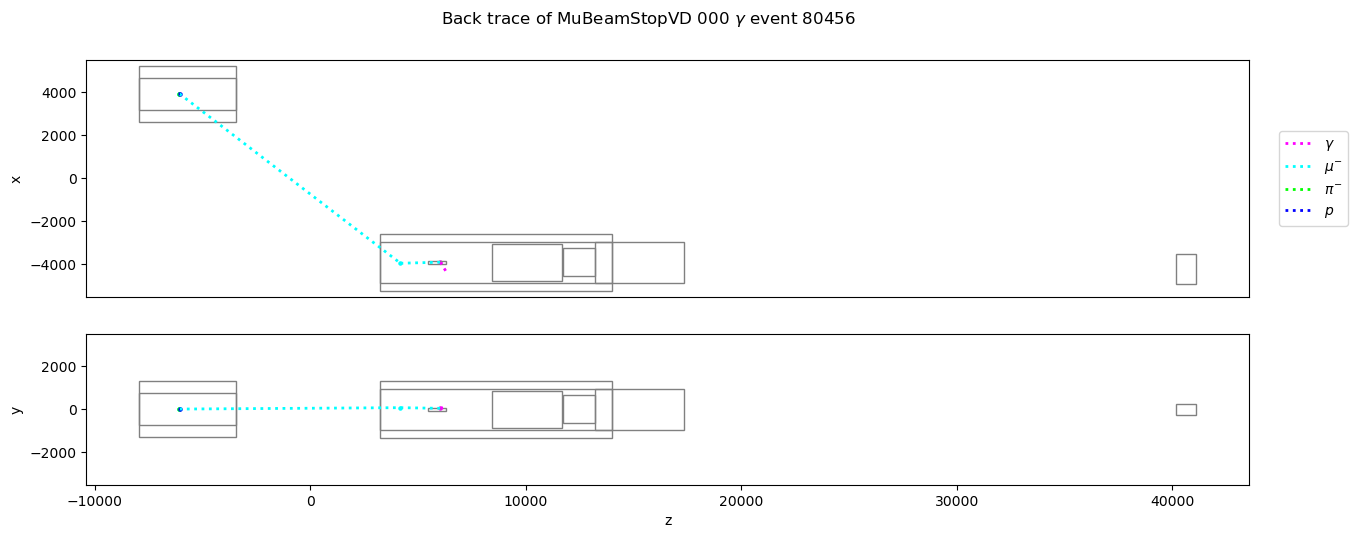

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1520.879785
creationCode                  165
index                       89546
pdgId                          22
px                     266.545537
py                     567.546954
pz                    1385.611508
startpx                266.545534
startpy                567.546964
startpz               1385.611534
starttime              530.621704
startx                -3935.36579
starty                  -0.904484
startz                 6048.82099
time                   531.453492
virtualdetectorId              10
x                    -3891.664111
y                       92.148116
z                     6275.999996
weight                          1
r                       92.970153
Name: 40000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   89546
parentendtime      192.138458
parentpdgId                13
starttime          530.621704
x                 -3935.36579
y                   -0.904484
z                  6048.82099
pdgId                      22
Name: 40000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3926.824106,55.426526,4179.000000,32.646751,169.555679,-3935.365790,-0.904484,6048.820990,0.000000,192.138458,56
1,13,3899.973813,48.415662,-4452.641642,28.846958,1.636493,-3932.789604,63.996328,4196.034639,32.644871,169.751312,14
2,-211,3896.958150,-8.776544,-6215.321791,77.828003,-13.943295,3899.973813,48.415662,-4452.641642,59.027214,1.636493,97
3,2112,3919.631034,1.111294,-6100.849280,-3284.906006,-14.348940,3896.958150,-8.776544,-6215.321791,-3282.210938,-13.943295,101
4,2212,3930.225382,1.282296,-6057.671223,-8624.851562,-14.498073,3919.631034,1.111294,-6100.849280,-8570.274414,-14.348940,56


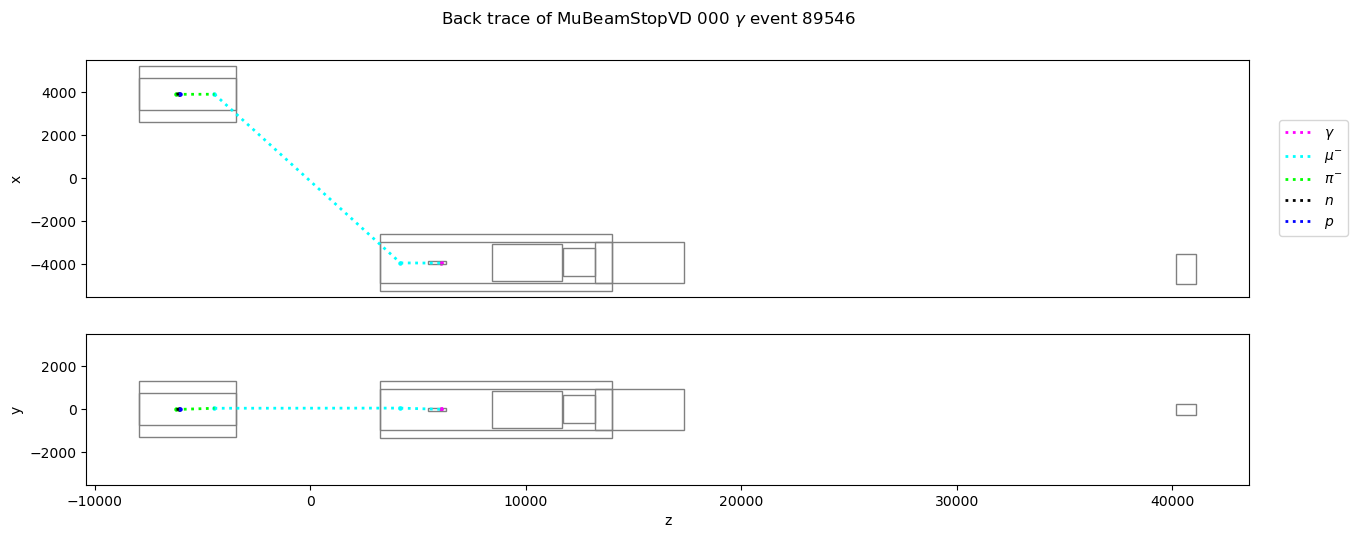

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      757.780214
creationCode                  165
index                       98215
pdgId                          22
px                     154.857597
py                     -24.913206
pz                     741.369887
startpx                154.857591
startpy                -24.913205
startpz                741.369903
starttime              890.792908
startx               -3903.467913
starty                  42.295635
startz                 5737.61417
time                   892.628528
virtualdetectorId              10
x                    -3791.009696
y                       24.203564
z                     6275.999996
weight                          1
r                      115.553543
Name: 44000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   98215
parentendtime      308.777313
parentpdgId                13
starttime          890.792908
x                -3903.467913
y                   42.295635
z                  5737.61417
pdgId                      22
Name: 44000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3953.759761,94.603222,4179.000000,21.186556,279.776642,-3903.467913,42.295635,5737.614170,-0.000000,308.777313,56
1,13,3848.209287,41.143552,-5576.816144,21.893322,36.560490,-3965.199882,85.689148,4192.685348,21.245825,280.013550,14
2,-211,3914.399246,-0.731029,-6120.816588,90.707336,31.595200,3848.209287,41.143552,-5576.816144,63.633392,36.560490,101
3,2212,3930.168867,-0.985881,-6057.657132,-8624.851562,31.376835,3914.399246,-0.731029,-6120.816588,-8545.577148,31.595200,56


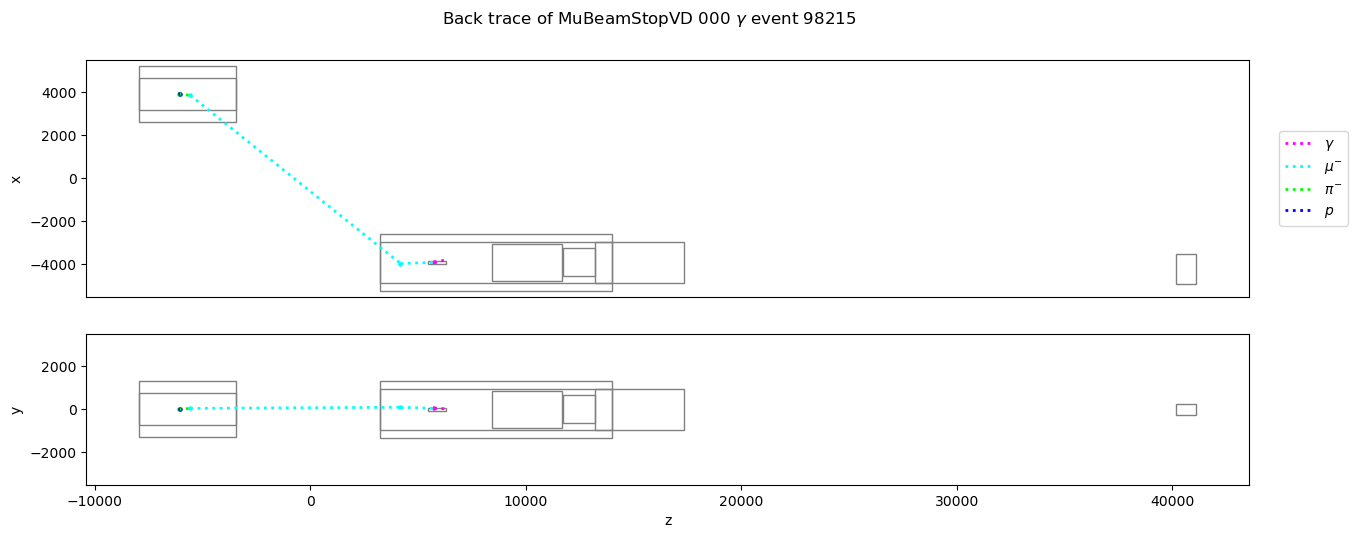

===================== 2112 25628
------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                     39223.356056
creationCode                   165
index                            2
pdgId                         2112
px                    78381.910482
py                    53975.641289
pz                    257268.71404
startpx               78381.912231
startpy               53975.643158
startpz              257268.707275
starttime               342.098999
startx                -3955.574003
starty                  -47.742557
startz                 6048.789062
time                     344.98245
virtualdetectorId               10
x                     -3886.349779
y                        -0.073115
z                      6275.999996
weight                           1
r                        17.650373
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                       2
parentendtime      143.052109
parentpdgId                13
starttime          342.098999
x                -3955.574003
y                  -47.742557
z                 6048.789062
pdgId                    2112
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3895.077501,-28.347469,4179.000000,35.500244,121.278564,-3955.574003,-47.742557,6048.789062,-0.000000,143.052109,56
1,13,3848.554902,-24.416251,-4077.256879,35.789337,-21.749706,-3893.160132,-18.952411,4196.534114,35.498158,121.464989,14
2,-211,3887.022901,2.488805,-6230.290920,116.053314,-35.637428,3848.554902,-24.416251,-4077.256879,86.679321,-21.749706,100
3,-211,3886.035448,0.098035,-6227.803995,-272.534729,-35.650116,3887.022901,2.488805,-6230.290920,-262.226074,-35.637428,101
4,2212,3929.361311,0.446379,-6057.455786,-8624.851562,-36.239803,3886.035448,0.098035,-6227.803995,-8307.888672,-35.650116,56


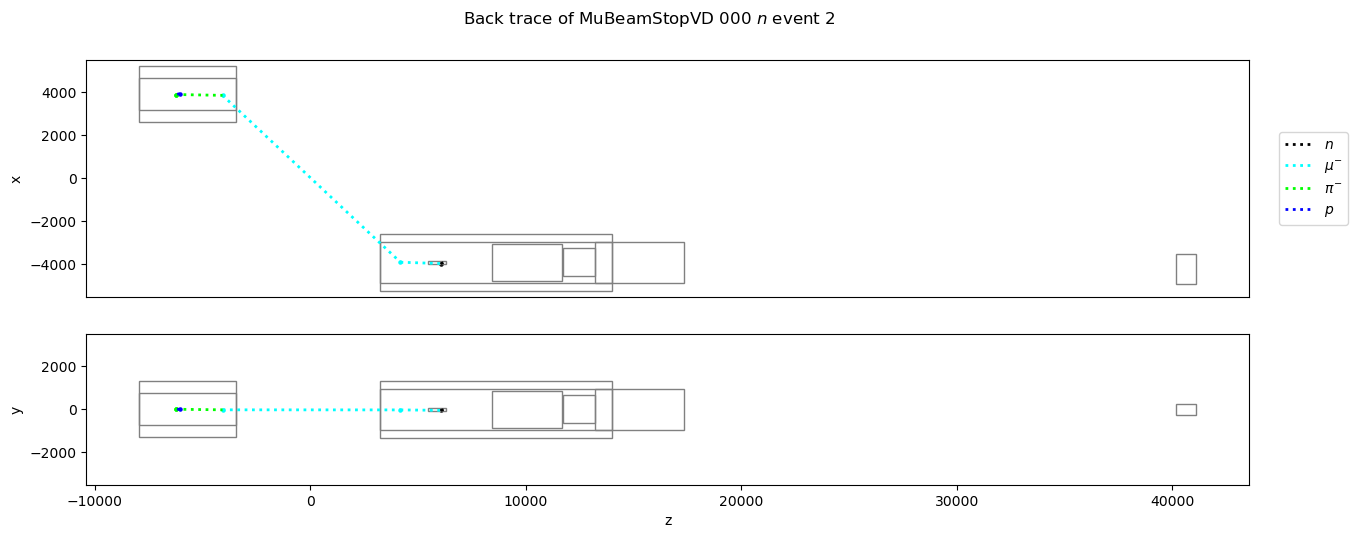

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                     16068.903626
creationCode                   165
index                        16125
pdgId                         2112
px                      89009.5472
py                   -45038.420261
pz                   143187.364358
startpx               89009.544373
startpy              -45038.421631
startpz              143187.362671
starttime               910.286682
startx                -3903.297894
starty                   62.585461
startz                 5537.697175
time                    926.722854
virtualdetectorId               10
x                     -3444.346784
y                      -169.641684
z                      6275.999996
weight                           1
r                       489.958549
Name: 4000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   16125
parentendtime      273.441864
parentpdgId                13
starttime          910.286682
x                -3903.297894
y                   62.585461
z                 5537.697175
pdgId                    2112
Name: 4000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3887.002682,93.295496,4179.000000,19.967997,249.124268,-3903.297894,62.585461,5537.697175,0.000000,273.441864,56
1,13,3919.727306,50.730969,-5702.199165,22.581530,1.053163,-3896.755601,95.472148,4196.266204,19.998648,249.436005,14
2,-211,3925.062467,-0.875581,-6077.852125,61.668606,-9.791729,3919.727306,50.730969,-5702.199165,22.719090,1.053163,101
3,2212,3930.062147,-0.923141,-6057.630524,-8624.851562,-9.861600,3925.062467,-0.875581,-6077.852125,-8602.680664,-9.791729,56


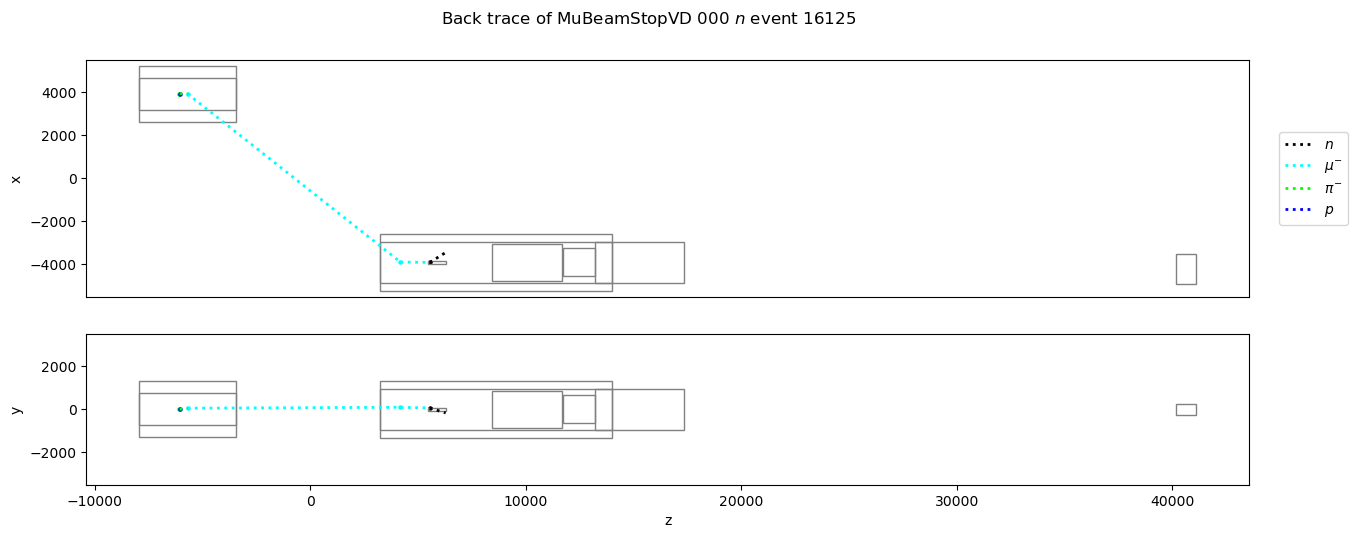

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      4239.72375
creationCode                  165
index                       31832
pdgId                        2112
px                  -36748.543197
py                  -62533.663736
pz                   52192.488666
startpx             -36748.542786
startpy             -62533.664703
startpz              52192.489624
starttime             1038.570435
startx               -3864.417809
starty                 -54.889518
startz                5937.664089
time                  1058.978471
virtualdetectorId              10
x                    -4102.638902
y                     -460.261716
z                     6275.999996
weight                          1
r                       501.29658
Name: 8000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   31832
parentendtime       217.49173
parentpdgId                13
starttime         1038.570435
x                -3864.417809
y                  -54.889518
z                 5937.664089
pdgId                    2112
Name: 8000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3862.986772,-71.679050,4179.000000,30.946255,194.530182,-3864.417809,-54.889518,5937.664089,0.000000,217.491730,56
1,13,3934.990507,-64.688764,-3777.654476,30.589464,32.478771,-3860.746368,-60.554423,4195.438638,30.959459,194.728882,14
2,-211,3889.802406,-2.967890,-6224.741549,93.580353,14.713632,3934.990507,-64.688764,-3777.654476,76.655136,32.478771,101
3,2212,3930.941688,-2.699917,-6057.849818,-8624.851562,14.136998,3889.802406,-2.967890,-6224.741549,-8358.022461,14.713632,56


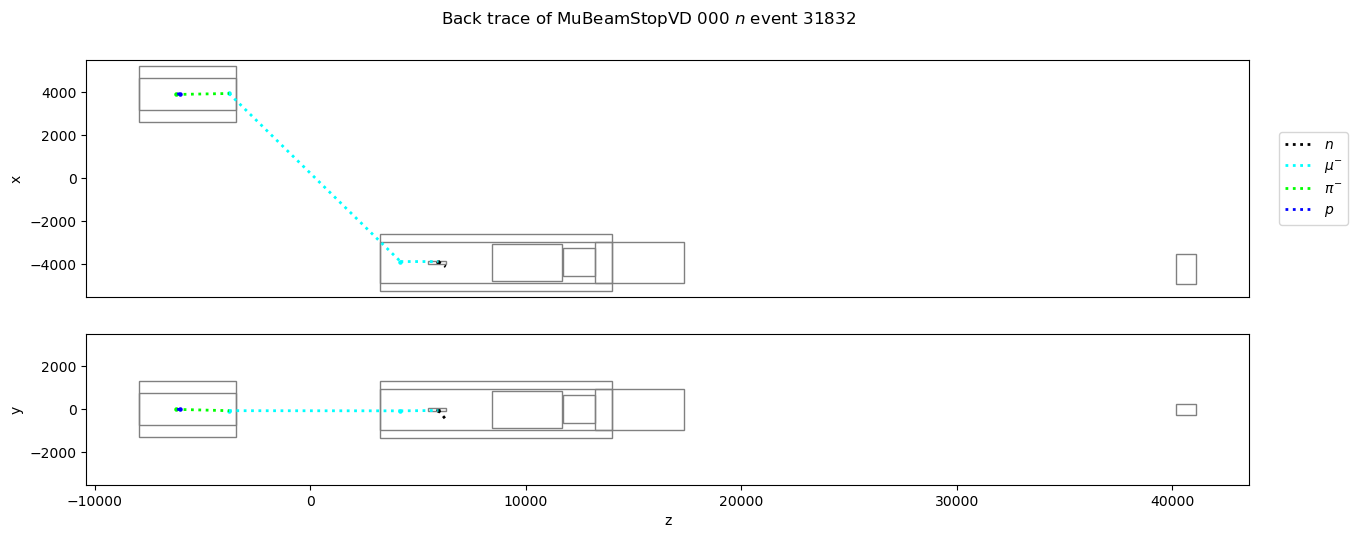

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     2039.245353
creationCode                  165
index                       48153
pdgId                        2112
px                    4710.148046
py                  -25434.988506
pz                  -56276.486871
startpx              25215.528488
startpy               18522.64595
startpz              65633.926392
starttime             1452.007935
startx               -3957.494763
starty                  25.846841
startz                5693.269636
time                  1566.334418
virtualdetectorId              10
x                    -3343.726917
y                       48.850616
z                     6276.019996
weight                          1
r                      562.398711
Name: 12000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   48153
parentendtime      280.760376
parentpdgId                13
starttime         1452.007935
x                -3957.494763
y                   25.846841
z                 5693.269636
pdgId                    2112
Name: 12000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3952.337237,19.333696,4179.000000,21.013596,254.080978,-3957.494763,25.846841,5693.269636,0.000000,280.760376,56
1,13,3883.671589,6.733107,-4331.450529,16.607899,5.062860,-3944.042212,29.208557,4194.208384,20.984507,254.344803,14
2,-211,3890.603130,6.136207,-6234.284183,30.067665,-20.850241,3883.671589,6.733107,-4331.450529,45.597721,5.062860,14
3,3122,3890.148928,1.017511,-6220.411692,-390.042358,-20.991501,3890.603130,6.136207,-6234.284183,-390.042358,-20.850241,101
4,2212,3930.670429,-1.333990,-6057.782186,-8624.851562,-21.553820,3890.148928,1.017511,-6220.411692,-8359.008789,-20.991501,56


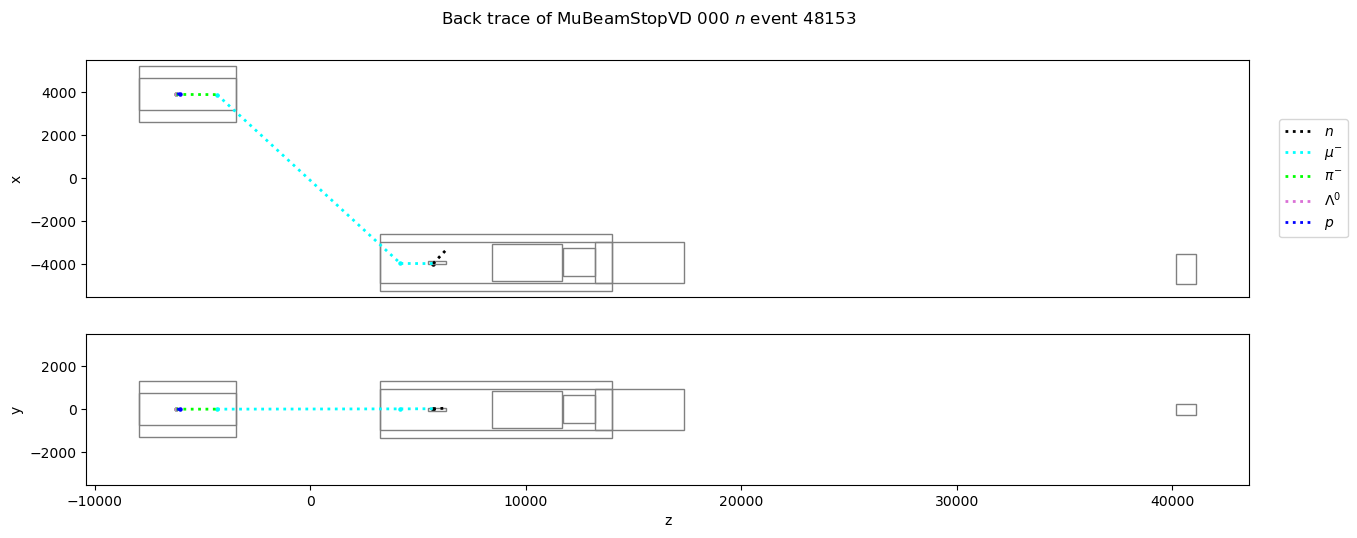

------------------------------------------------------------------------------


tag                    MuBeamStopVD
fileno                            0
E                          0.000053
creationCode                    165
index                         64599
pdgId                          2112
px                         7.079819
py                         2.778966
pz                         6.463095
startpx                45371.986389
startpy                38291.820526
startpz               -55328.380585
starttime               1006.356384
startx                 -3934.250459
starty                   -22.988237
startz                  5626.522172
time                 1887482.653892
virtualdetectorId                10
x                       -4285.27639
y                        310.395128
z                       6275.999996
weight                            1
r                        491.647049
Name: 16000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   64599
parentendtime      296.476013
parentpdgId                13
starttime         1006.356384
x                -3934.250459
y                  -22.988237
z                 5626.522172
pdgId                    2112
Name: 16000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3886.793287,0.014136,4179.000000,24.754650,274.257294,-3934.250459,-22.988237,5626.522172,-0.000000,296.476013,56
1,13,3907.027550,30.157302,-5407.417122,10.168114,32.688183,-3888.143165,12.936095,4194.148718,24.753115,274.483063,14
2,-211,3912.914788,0.906673,-6124.673708,-10.240145,13.642521,3907.027550,30.157302,-5407.417122,29.310658,32.688183,101
3,2212,3929.413638,0.714910,-6057.468832,-8624.851562,13.410397,3912.914788,0.906673,-6124.673708,-8554.623047,13.642521,56


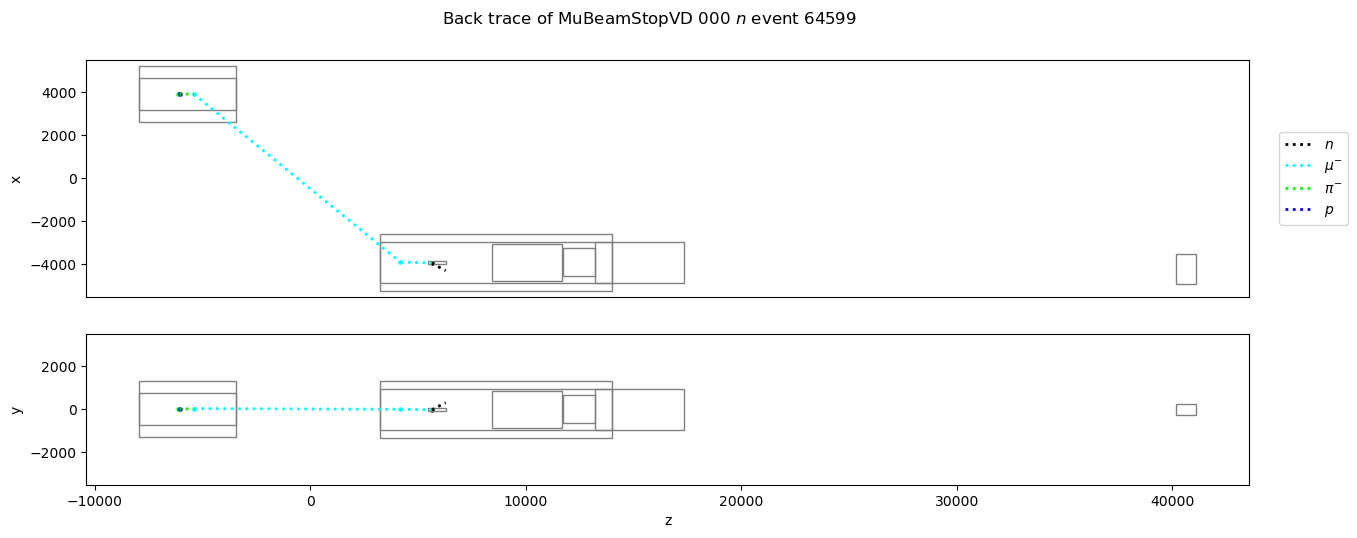

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                     10012.962896
creationCode                   165
index                        80838
pdgId                         2112
px                   -78521.454274
py                   -15478.462755
pz                   111851.347832
startpx              -78521.453857
startpy              -15478.463173
startpz              111851.348877
starttime               383.267334
startx                -3877.723949
starty                    31.78511
startz                 6159.867855
time                    386.556009
virtualdetectorId               10
x                     -3959.250589
y                        15.714253
z                      6275.999996
weight                           1
r                        57.441843
Name: 20000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   80838
parentendtime      258.718445
parentpdgId                13
starttime          383.267334
x                -3877.723949
y                    31.78511
z                 6159.867855
pdgId                    2112
Name: 20000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3882.447332,10.918507,4179.000000,33.423546,234.812439,-3877.723949,31.785110,6159.867855,0.000000,258.718445,56
1,13,3932.499410,-6.312252,-6116.856037,22.628700,49.650249,-3872.026901,7.740939,4195.748421,33.419846,235.001251,14
2,-211,3912.188623,-1.280280,-6134.600596,97.781464,49.496162,3932.499410,-6.312252,-6116.856037,64.197777,49.650249,101
3,2212,3931.205056,-1.356695,-6057.915483,-8624.851562,49.231133,3912.188623,-1.280280,-6134.600596,-8502.230469,49.496162,56


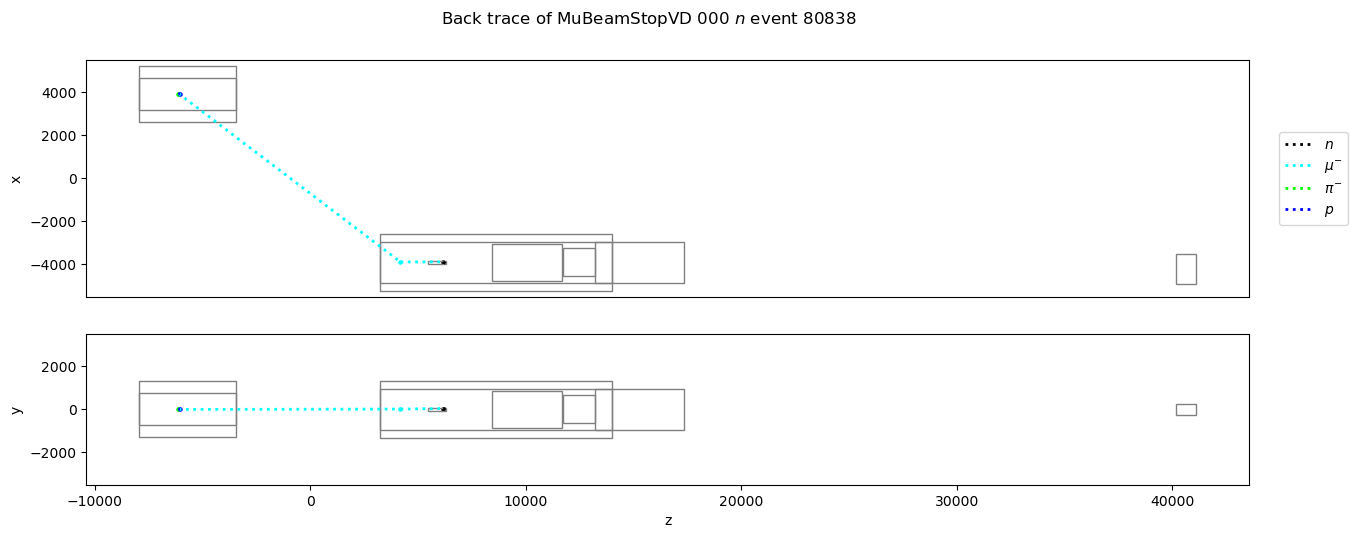

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1928.136856
creationCode                  165
index                       97142
pdgId                        2112
px                    11790.46346
py                  -53726.007434
pz                   24524.273845
startpx              11790.463448
startpy             -53726.005554
startpz              24524.272919
starttime              255.410004
startx               -3897.688627
starty                  45.891563
startz                6137.708654
time                   273.119061
virtualdetectorId              10
x                    -3831.202703
y                     -257.067118
z                     6275.999996
weight                          1
r                      267.175878
Name: 24000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                   97142
parentendtime      140.091248
parentpdgId                13
starttime          255.410004
x                -3897.688627
y                   45.891563
z                 6137.708654
pdgId                    2112
Name: 24000, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3864.903836,-13.422588,4179.000000,38.718678,119.218292,-3897.688627,45.891563,6137.708654,0.000000,140.091248,56
1,13,3875.263985,32.711752,-3890.141368,35.095219,-19.512268,-3857.910535,-5.169084,4195.804077,38.727203,119.385147,14
2,-211,3910.181366,-1.634674,-6139.429906,74.661797,-49.392452,3875.263985,32.711752,-3890.141368,44.241356,-19.512268,101
3,2212,3913.120786,-1.528346,-6124.621442,-4895.187988,-49.443699,3910.181366,-1.634674,-6139.429906,-4877.478027,-49.392452,101
4,2212,3929.813272,-1.497730,-6057.568472,-8624.851562,-49.675488,3913.120786,-1.528346,-6124.621442,-8530.030273,-49.443699,56


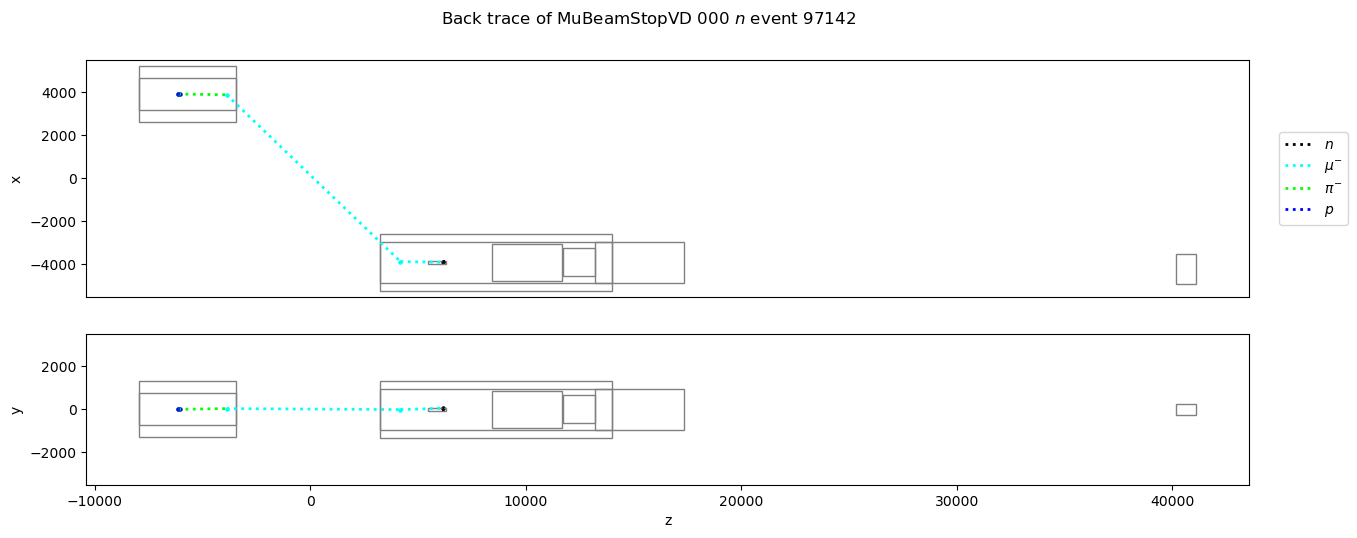

===================== 2212 362
------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     3052.132799
creationCode                   97
index                         473
pdgId                        2212
px                  -16204.452212
py                    -24435.1468
pz                   69836.355281
startpx                434.518933
startpy              41773.967743
startpz              86379.905701
starttime             1079.776367
startx               -3909.735248
starty                  73.597203
startz                5715.405509
time                  1105.197706
virtualdetectorId              10
x                    -3780.791388
y                        21.20788
z                     6275.999996
weight                          1
r                      125.020543
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode               97
index                     473
parentendtime     1079.776367
parentpdgId              2112
starttime         1079.776367
x                -3909.735248
y                   73.597203
z                 5715.405509
pdgId                    2212
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3907.317535,68.116586,5715.486114,-3.443043,1079.700317,-3909.735248,73.597203,5715.405509,-3.443043,1079.776367,165
1,13,-3887.548040,24.495446,4179.000000,30.312040,225.397446,-3907.317535,68.116586,5715.486114,0.000000,244.721695,56
2,13,3923.841415,9.424368,-5710.405013,27.733595,39.759117,-3881.664359,32.635668,4196.269457,30.305965,225.609039,14
3,-211,3922.991677,-2.589372,-6091.695624,16.253923,32.039635,3923.841415,9.424368,-5710.405013,27.458559,39.759117,101
4,2212,3931.327783,-2.684144,-6057.946082,-8624.851562,31.923025,3922.991677,-2.589372,-6091.695624,-8594.423828,32.039635,56


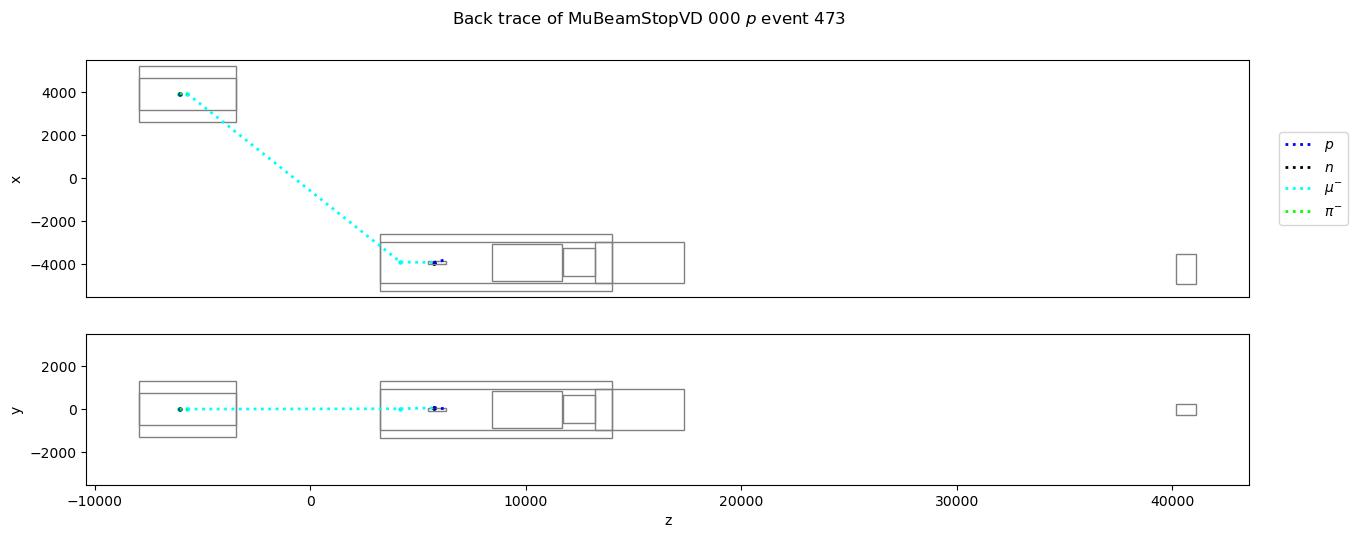

===================== 1000010020 141
------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                      4785.455539
creationCode                   165
index                          235
pdgId                   1000010020
px                    -2458.526884
py                   -37809.063477
pz                   128602.595143
startpx               35971.687317
startpy               16813.806534
startpz              128433.197021
starttime              1118.994019
startx                -3833.521906
starty                  -17.012198
startz                 5648.829774
time                   1149.682494
virtualdetectorId               10
x                     -3703.013357
y                      -109.468801
z                      6275.999996
weight                           1
r                       228.864696
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              165
index                     235
parentendtime      350.987976
parentpdgId                13
starttime         1118.994019
x                -3833.521906
y                  -17.012198
z                 5648.829774
pdgId              1000010020
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,13,-3801.498603,-11.468711,4179.000000,14.162224,314.867249,-3833.521906,-17.012198,5648.829774,0.000000,350.987976,56
1,13,3978.627640,-7.999585,-4848.371312,19.170139,-1.432132,-3810.800383,-2.910098,4194.330737,14.183587,315.254242,14
2,-211,3898.675444,-0.593168,-6177.743008,11.574161,-29.436621,3978.627640,-7.999585,-4848.371312,29.433964,-1.432132,101
3,2212,3929.531528,-1.049317,-6057.498226,-8624.851562,-29.853064,3898.675444,-0.593168,-6177.743008,-8419.221680,-29.436621,56


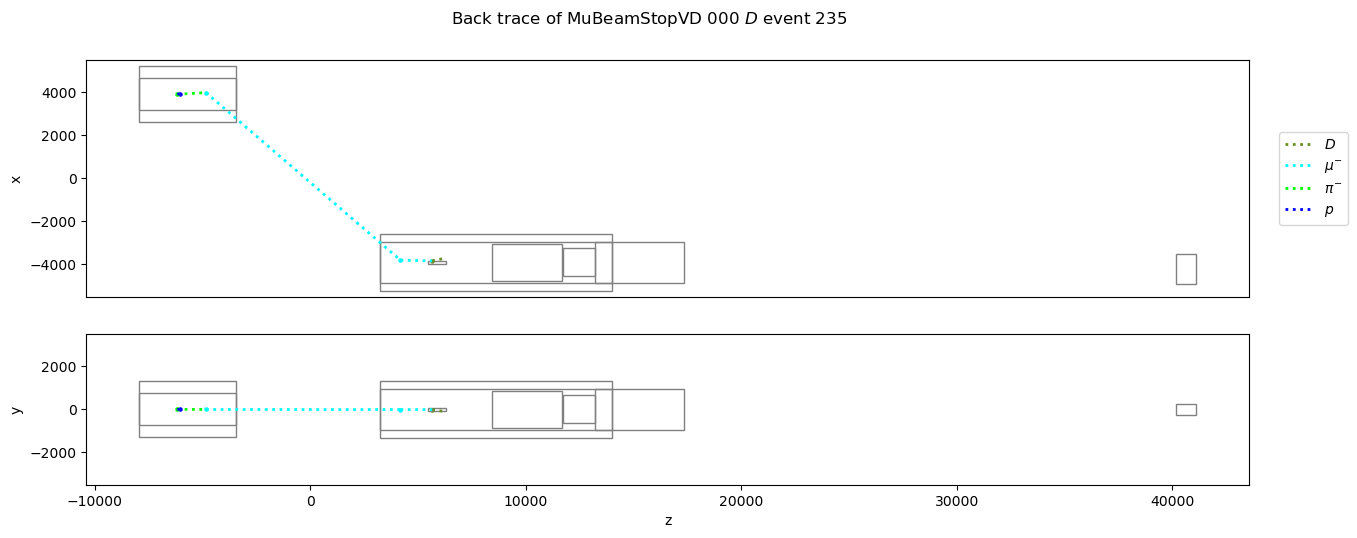

In [11]:
rdf_genealogy = [ROOT.RDataFrame("ParticleBackTracer/ttree_genealogy", filename) for filename in fileList]
for pdgId in list_of_pdgId:
    print('=====================', pdgId, len(df_by_pdgid[pdgId][0]))
    for ii in range(0, len(df_by_pdgid[pdgId][0]), 4000):
        print('------------------------------------------------------------------------------')
        dfp_ = df_by_pdgid[pdgId][0].iloc[ii]
        dfs_ = df_by_pdgid[pdgId][1].iloc[ii]
        fileno, index = dfp_['fileno'], dfp_['index']

        rdfg_ = rdf_genealogy[fileno].Filter("index==%i"%index)
        dfg_ = pd.DataFrame(rdfg_.AsNumpy(columns = ["pdgId", 
                                                     "startx", "starty", "startz", "startpz", "startGlobalTime", 
                                                     "endx", "endy", "endz", "endpz", "endGlobalTime", "creationCode"]))
        
        display(dfp_)
        display(dfs_)
        display(dfg_)
        fig, ax_top, ax_side = plot_utils.draw_particle_event_backtrace(dfp_, dfg_, tag, fileno, index)
        plt.show()

------------------------------------------------------------------------------
Parent pdgId:  22 $\gamma$
count:  16
creationCode
13    16
Name: count, dtype: int64
******


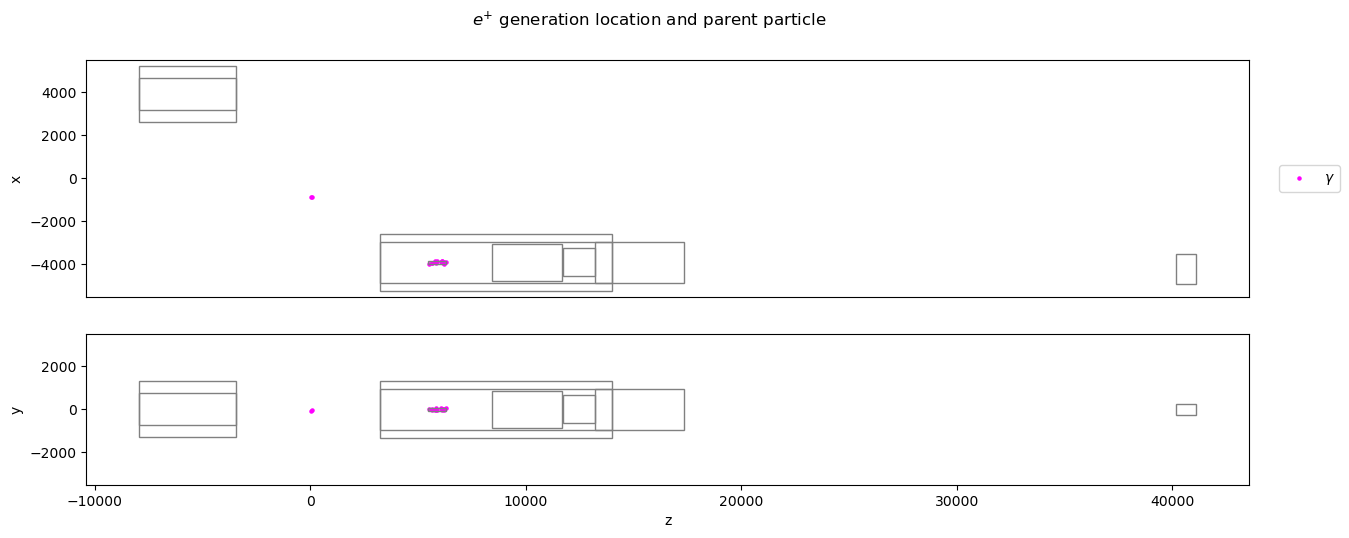

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  31074
creationCode
166    31074
Name: count, dtype: int64
******
Parent pdgId:  22 $\gamma$
count:  177
creationCode
12    158
13     17
40      2
Name: count, dtype: int64
******
Parent pdgId:  1000120270 $^{27}Mg$
count:  1
creationCode
74    1
Name: count, dtype: int64
******


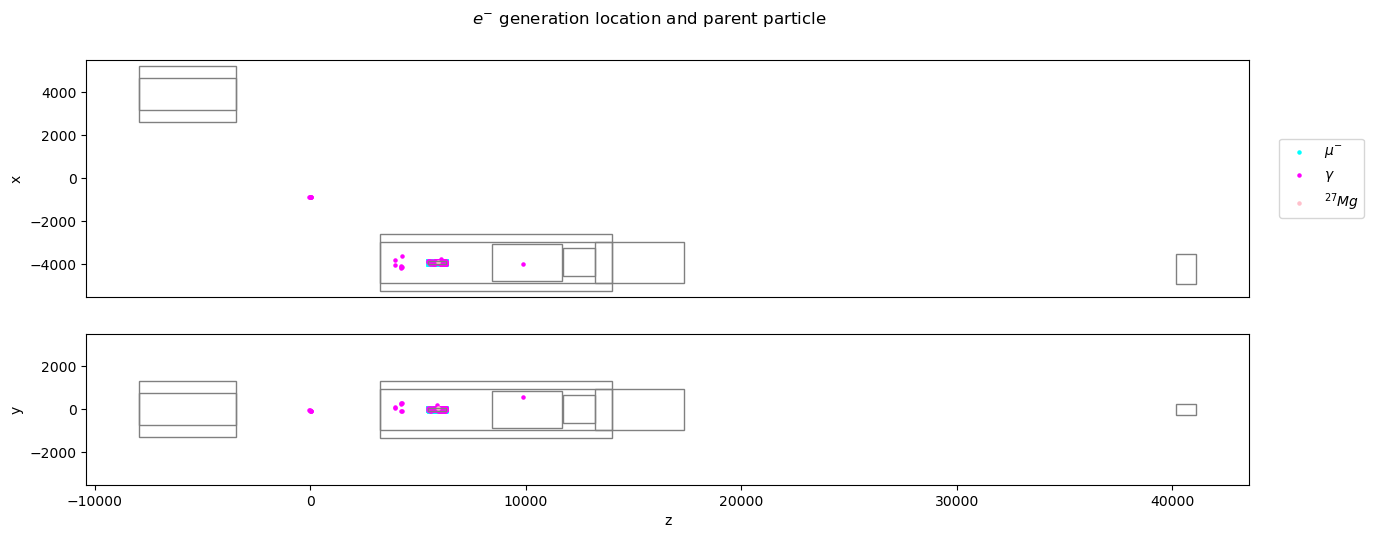

------------------------------------------------------------------------------
Parent pdgId:  -11 $e^{+}$
count:  1288
creationCode
2     1243
16      45
Name: count, dtype: int64
******
Parent pdgId:  11 $e^{-}$
count:  4374
creationCode
16    4374
Name: count, dtype: int64
******
Parent pdgId:  13 $\mu^{-}$
count:  35891
creationCode
165    35890
172        1
Name: count, dtype: int64
******
Parent pdgId:  2112 $n$
count:  4803
creationCode
35    2475
97    2328
Name: count, dtype: int64
******
Parent pdgId:  2212 $p$
count:  1
creationCode
101    1
Name: count, dtype: int64
******
Parent pdgId:  1000010020 $D$
count:  3
creationCode
72    3
Name: count, dtype: int64
******
Parent pdgId:  1000120249 1000120249
count:  18
creationCode
74    18
Name: count, dtype: int64
******
Parent pdgId:  1000130279 1000130279
count:  7
creationCode
74    7
Name: count, dtype: int64
******
Parent pdgId:  1000140289 1000140289
count:  21
creationCode
74    21
Name: count, dtype: int64
******
Parent p

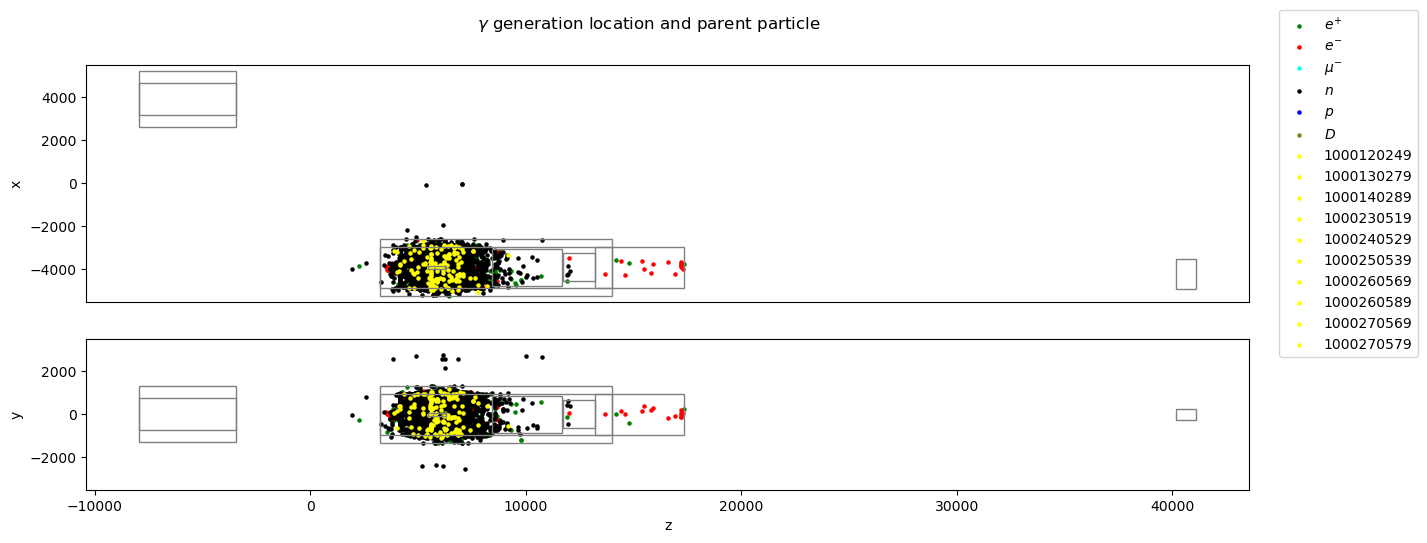

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  25628
creationCode
165    25628
Name: count, dtype: int64
******


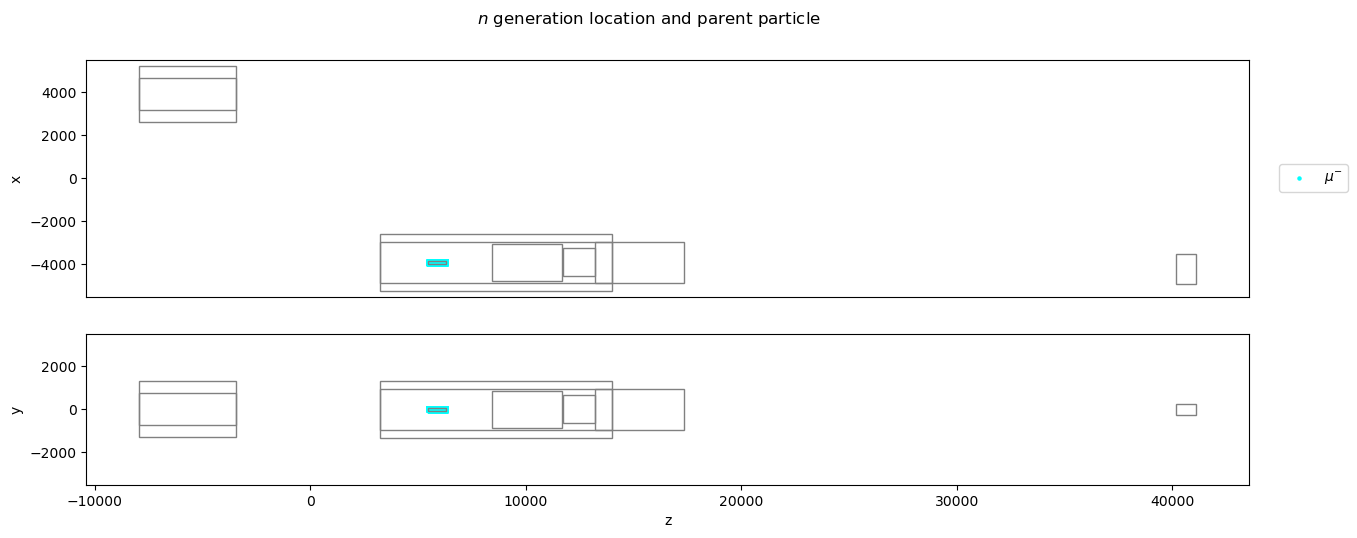

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  358
creationCode
165    358
Name: count, dtype: int64
******
Parent pdgId:  2112 $n$
count:  3
creationCode
97    2
58    1
Name: count, dtype: int64
******
Parent pdgId:  1000010020 $D$
count:  1
creationCode
72    1
Name: count, dtype: int64
******


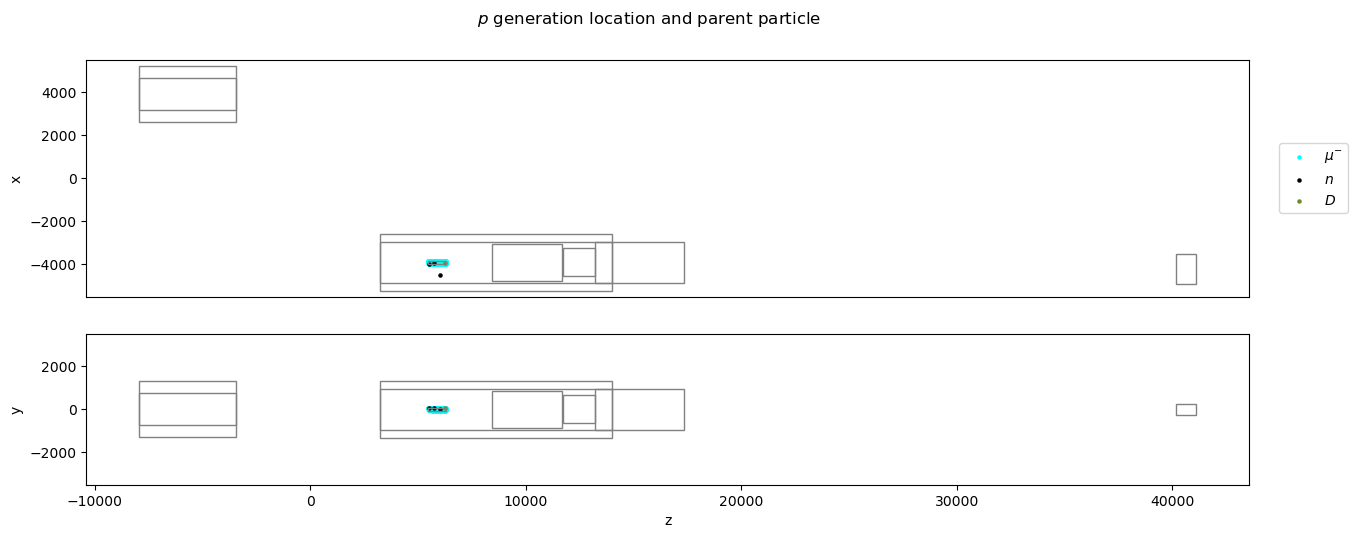

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  141
creationCode
165    141
Name: count, dtype: int64
******


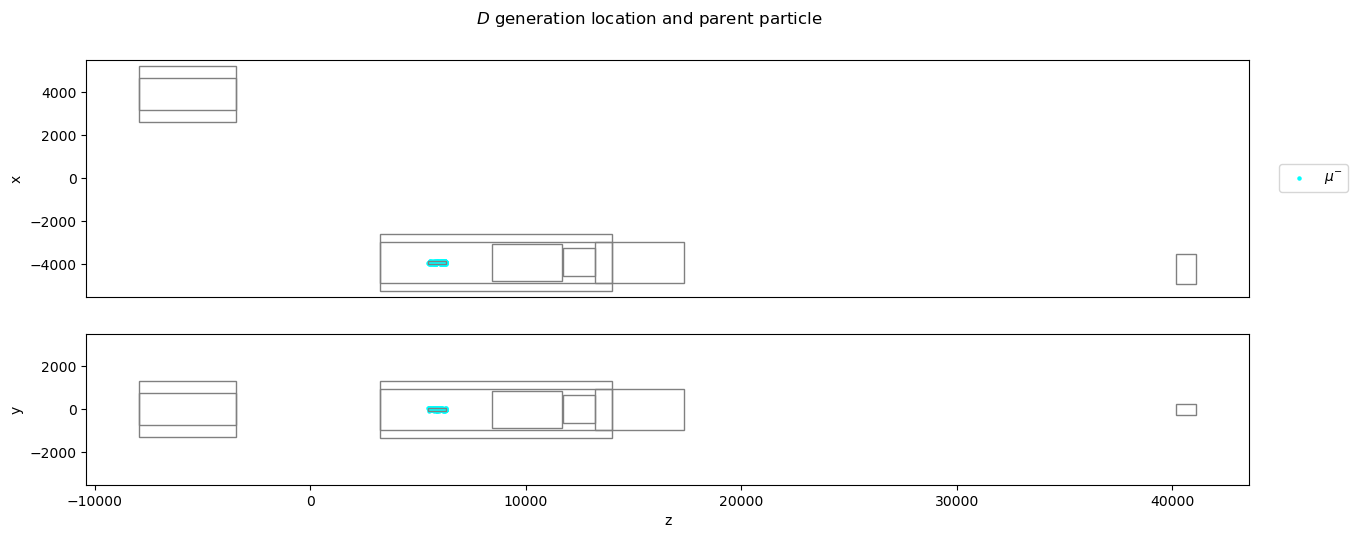

In [7]:
for pdgId in list_of_pdgId:
    fig, ax_top, ax_side = plot_utils.draw_particle_source_all(df_by_pdgid[pdgId][1], pdgid_dict[pdgId]+" generation location and parent particle")
    plt.show()

Text(0.5, 0.93, '$\\gamma$ spectrum at VD 10')

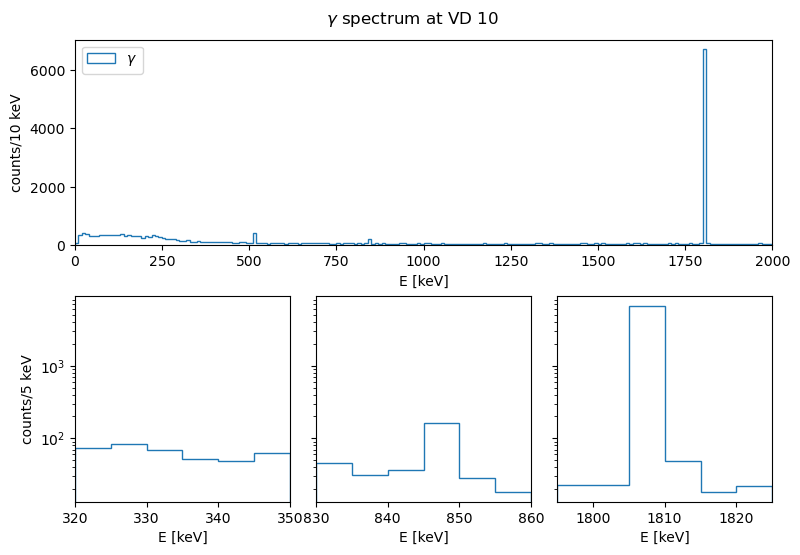

In [8]:
bins_main = np.linspace(0., 2000., 201) # 10keV
bins_347  = np.linspace(320., 350., 7) # 5keV
bins_844  = np.linspace(830., 860., 7)
bins_1809 = np.linspace(1795., 1825., 7)
mybins = [bins_main, bins_347, bins_844, bins_1809]

fig = plt.figure(figsize=(9, 6))
gs = GridSpec(2, 3, figure=fig,
              wspace=0.12, hspace=0.25) 

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[1, 2], sharey=ax1)
ax = [ax0, ax1, ax2, ax3]

for i in range(4):
    ax[i].hist(df_by_pdgid[22][0]['E'], bins=mybins[i], histtype="step", label=r'$\gamma$')
    ax[i].set_xlim(mybins[i][0],mybins[i][-1])
    ax[i].set_xlabel('E [keV]')

ax[0].set_ylabel('counts/10 keV')
ax[1].set_ylabel('counts/5 keV')
ax[1].set_yscale('log')
ax[2].tick_params(axis="y", labelleft=False)
ax[3].tick_params(axis="y", labelleft=False)

ax[0].legend()
fig.suptitle(r'$\gamma$'+" spectrum at VD 10", y=0.93)

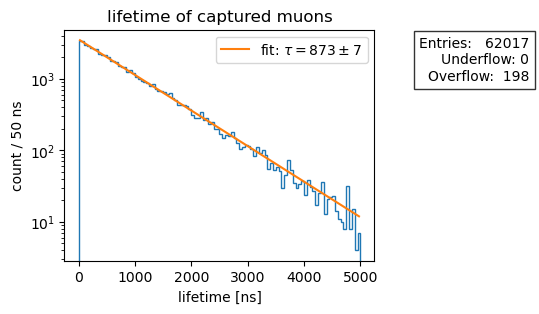

In [12]:
from scipy.optimize import curve_fit

def expo(x, A, tau):
    return A * np.exp(-x / tau)

mybins = np.linspace(0., 5000., 101)
fig, ax = plt.subplots(figsize=(4,3))
dfs_ = df_source.query("parentpdgId==13 and creationCode==165").reset_index(drop=True) # muon, nuclear capture
counts, bin_edges, _ = ax.hist(dfs_['starttime']-dfs_['parentendtime'], mybins, histtype='step')

bin_centers = bin_edges[1:]-0.5*(bin_edges[1]-bin_edges[0])
p0=(500., 800.)
popt, pcov = curve_fit(expo, bin_centers[:], counts[:], p0=p0)
A, tau = popt
Aerr, tauerr = np.sqrt(np.diag(pcov))
xfit = np.linspace(bin_centers[0], bin_centers.max(), 300)
ax.plot(xfit, expo(xfit, *popt), '-', label=fr'fit: $\tau={tau:.0f}\pm{tauerr:.0f}$')

ax.set_title('lifetime of captured muons')
ax.set_xlabel('lifetime [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(dfs_['starttime'])
mean = np.mean(dfs_['starttime'])
std = np.std(dfs_['starttime'])
underflow = (dfs_['starttime'] < 0.).sum()
overflow  = (dfs_['starttime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')
ax.legend()

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     6899.938513
creationCode                   13
index                         167
pdgId                         -11
px                   -5106.654066
py                   -2199.483323
pz                    4872.907854
startpx              -5113.937855
startpy               6351.876736
startpz              -1104.048848
starttime              611.904846
startx                -851.629573
starty                 -36.689518
startz                  90.077538
time                   691.237959
virtualdetectorId              10
x                     -3791.01838
y                      -11.818437
z                     6275.999996
weight                          1
r                      113.598072
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,22,-850.881714,-37.455960,91.269277,-11.469433,611.899475,-851.629573,-36.689518,90.077538,-11.469433,611.904846,16
1,11,-3862.710058,-3.460876,5826.534019,-19.235788,560.113953,-3654.337699,-240.353957,15489.831421,-0.000000,671.026245,166
2,13,-3820.657920,3.284215,4179.000000,31.855064,154.683823,-3862.710058,-3.460876,5826.534019,0.000000,174.749802,56
3,13,3377.978885,62.433282,-1166.677051,15.884077,31.674297,-3824.128839,12.885194,4196.174106,31.876493,154.885147,14
4,-211,3931.359146,-0.187421,-6060.352586,77.038559,-17.749430,3377.978885,62.433282,-1166.677051,49.117092,31.674297,101
5,2212,3931.925025,-0.185007,-6058.094992,-8624.851562,-17.757236,3931.359146,-0.187421,-6060.352586,-8615.820312,-17.749430,56


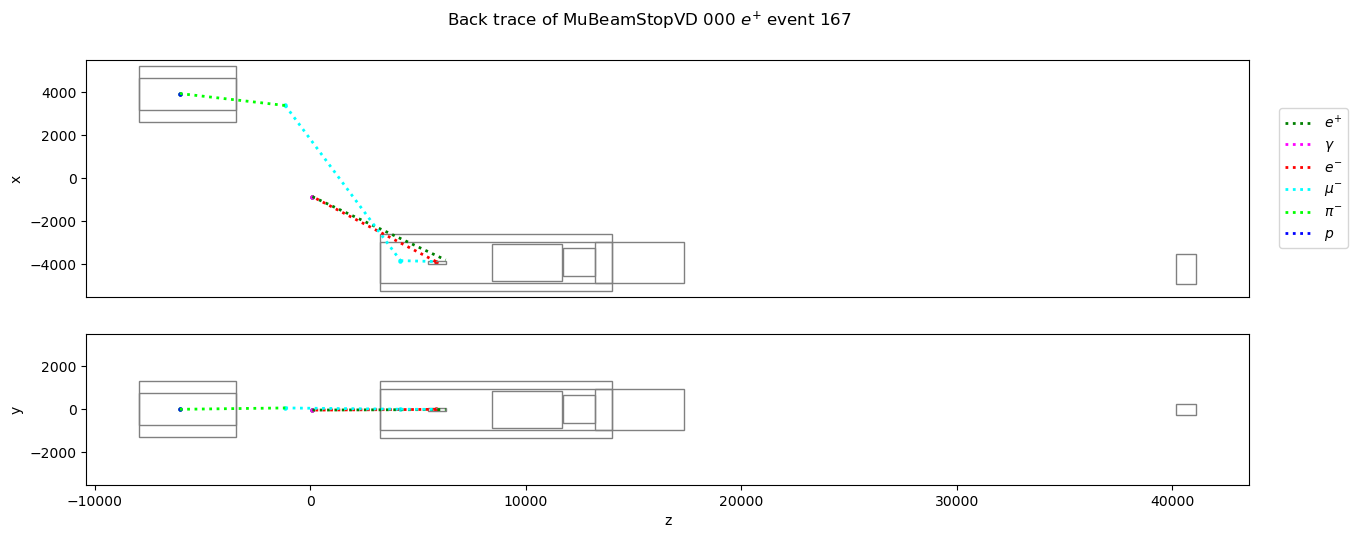

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     4182.290837
creationCode                   13
index                       15737
pdgId                         -11
px                    -447.376588
py                    4221.404016
pz                    1935.316792
startpx               2300.460815
startpy              -6693.422318
startpz              -3904.888153
starttime              886.048584
startx                -851.324312
starty                 -83.573734
startz                   8.860846
time                   927.174866
virtualdetectorId              10
x                    -3928.383467
y                      -64.586904
z                     6275.999996
weight                          1
r                       69.036379
Name: 1, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,22,-851.940462,-82.274553,9.769246,-6.564481,886.042908,-851.324312,-83.573734,8.860846,-6.564481,886.048584,16
1,11,-3862.290515,31.107780,5715.462146,-16.674835,821.326843,-851.209397,-83.257461,8.649923,0.000000,886.048584,166
2,13,-3813.790850,17.806862,4179.000000,18.360189,377.903442,-3862.290515,31.107780,5715.462146,0.000000,408.152191,56
3,13,4010.142902,21.374755,-4375.098690,7.059945,79.839890,-3804.083132,30.347804,4191.064443,18.385204,378.144318,14
4,-211,3920.148162,-0.722191,-6101.563447,3.683730,41.630314,4010.142902,21.374755,-4375.098690,33.608536,79.839890,101
5,2212,3930.914703,-0.534191,-6057.843090,-8624.851562,41.479279,3920.148162,-0.722191,-6101.563447,-8591.092773,41.630314,56


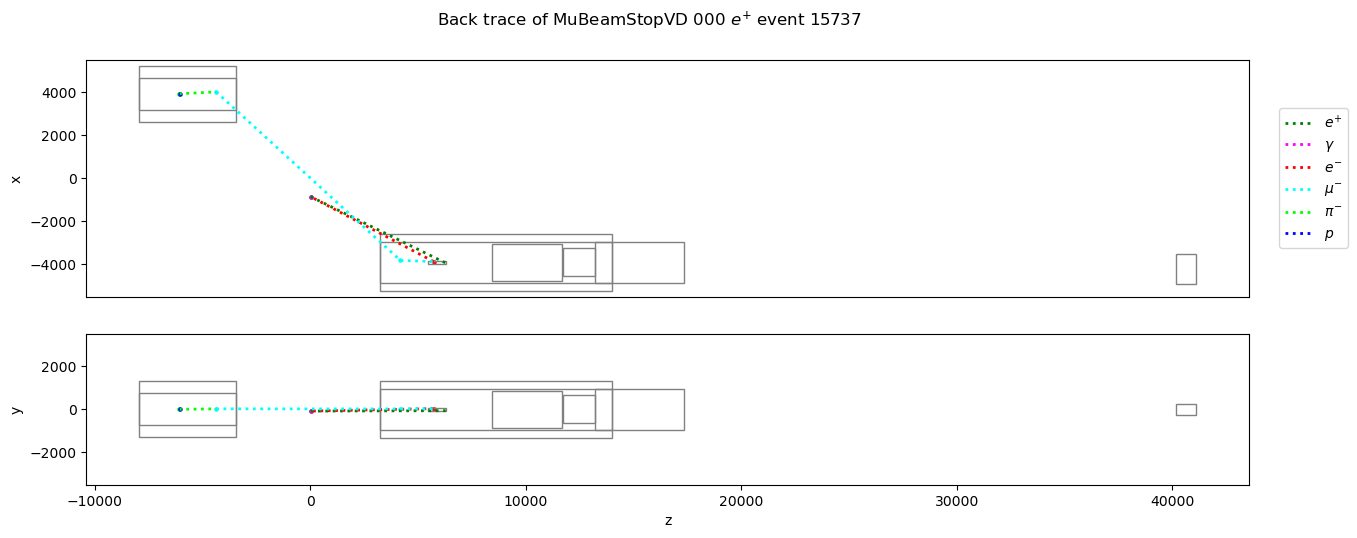

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1576.589982
creationCode                   17
index                         720
pdgId                          11
px                    -756.884027
py                    1410.896631
pz                    1238.307217
startpx               2007.889271
startpy              -2021.953344
startpz                723.732293
starttime             1185.027344
startx               -3909.490797
starty                -149.335036
startz                 3928.48508
time                  1203.092645
virtualdetectorId              10
x                    -3906.905416
y                      -174.69988
z                     6275.999996
weight                          1
r                      174.724038
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3895.666208,-48.183796,6004.312014,-25.867634,1165.367676,-3896.888794,-151.862244,3920.097086,-0.000000,1185.122437,166
1,13,-3904.263300,-68.854671,4179.000000,40.565243,92.695625,-3895.666208,-48.183796,6004.312014,0.000000,112.105515,56
2,13,3906.875894,-46.777574,-4612.146493,43.131832,-37.411102,-3903.209461,-73.347397,4198.457043,40.571095,92.877350,14
3,-211,3898.883383,-2.986578,-6192.343711,113.962700,-47.980091,3906.875894,-46.777574,-4612.146493,81.711533,-37.411102,97
4,2112,3904.902573,-0.280642,-6151.436313,-2072.429932,-48.131523,3898.883383,-2.986578,-6192.343711,-2072.429932,-47.980091,101
5,2212,3920.215292,-0.757673,-6100.513746,-4112.004883,-48.313171,3904.902573,-0.280642,-6151.436313,-4024.058594,-48.131523,101
6,2212,3930.737547,-0.935588,-6057.798920,-8624.851562,-48.460735,3920.215292,-0.757673,-6100.513746,-8578.618164,-48.313171,56


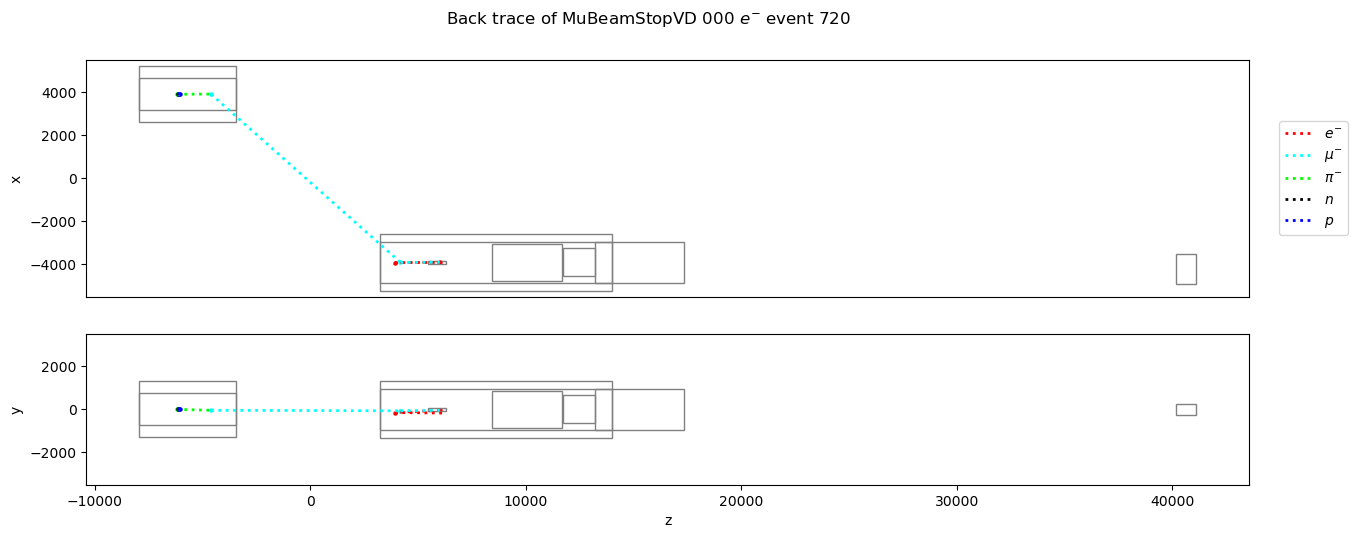

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1953.242451
creationCode                   17
index                        7373
pdgId                          11
px                    1264.530038
py                    1338.151921
pz                    1556.174418
startpx               -748.048007
startpy              -5853.736401
startpz               -119.166315
starttime              748.721252
startx               -4039.136349
starty                  85.722501
startz                 3924.20656
time                   764.133467
virtualdetectorId              10
x                    -4054.537017
y                       92.607432
z                     6275.999996
weight                          1
r                      176.741421
Name: 1, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3944.949920,-13.331251,5537.648898,-22.041494,730.584656,-4038.434228,24.662176,3889.266947,-0.000000,749.576660,166
1,13,-3923.412429,-37.680244,4179.000000,19.822771,250.046005,-3944.949920,-13.331251,5537.648898,0.000000,274.843781,56
2,13,3876.674464,-22.263647,-5827.381665,22.252428,-5.792302,-3914.472366,-35.052476,4196.642873,19.830690,250.366653,14
3,-211,3901.878768,0.077954,-6167.266071,49.548161,-11.148765,3876.674464,-22.263647,-5827.381665,34.217361,-5.792302,101
4,2212,3929.972662,-0.993484,-6057.608213,-8624.851562,-11.528522,3901.878768,0.077954,-6167.266071,-8433.718750,-11.148765,56


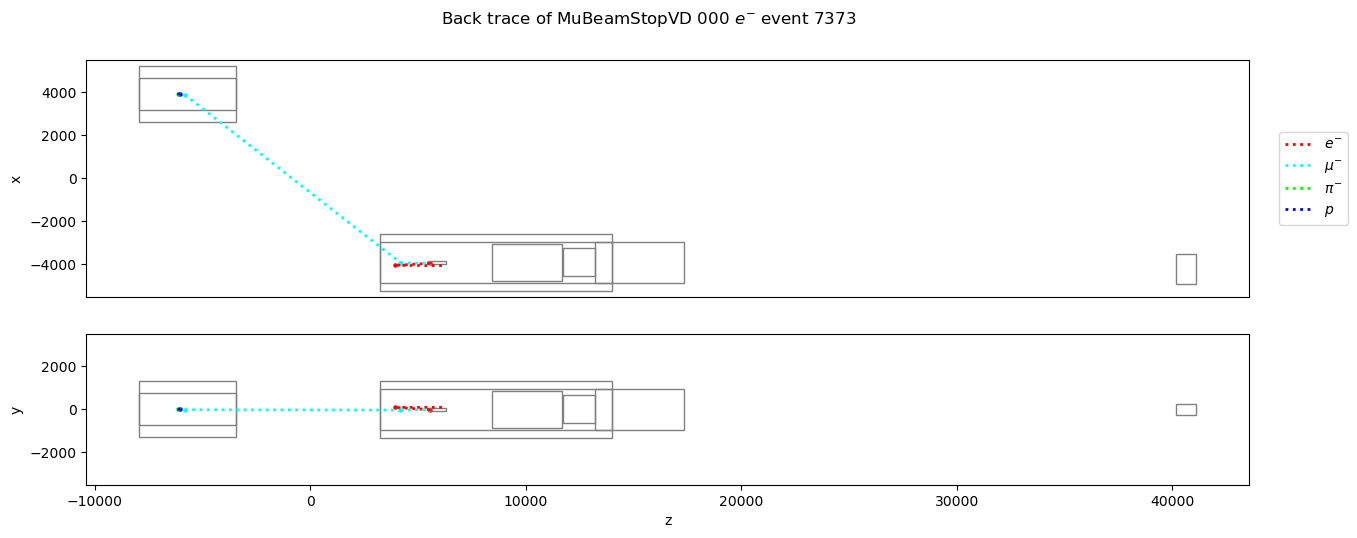

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     2319.241956
creationCode                   17
index                        8231
pdgId                          11
px                    1970.294644
py                    -642.680027
pz                    1858.506086
startpx               1109.443665
startpy              -2467.896223
startpz                962.764978
starttime              412.342438
startx               -4051.524377
starty                -103.211169
startz                3929.944895
time                   426.882993
virtualdetectorId              10
x                    -4079.434478
y                       -126.7479
z                     6275.999996
weight                          1
r                      216.430788
Name: 2, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3923.198182,-41.606341,6270.966018,-27.728544,390.412140,-4001.193390,-109.197959,3896.098804,-0.000000,412.819794,166
1,13,-3882.025171,4.373920,4179.000000,40.287151,149.461197,-3923.198182,-41.606341,6270.966018,-0.000000,172.279358,56
2,13,3896.312991,24.577335,-4348.617975,39.140144,18.045336,-3885.605779,12.256671,4197.017659,40.287945,149.632339,14
3,-211,3890.081956,0.552662,-6215.496881,120.499519,2.828876,3896.312991,24.577335,-4348.617975,63.548580,18.045336,101
4,2212,3930.388006,-0.023020,-6057.711770,-8624.851562,2.282552,3890.081956,0.552662,-6215.496881,-8360.507812,2.828876,56


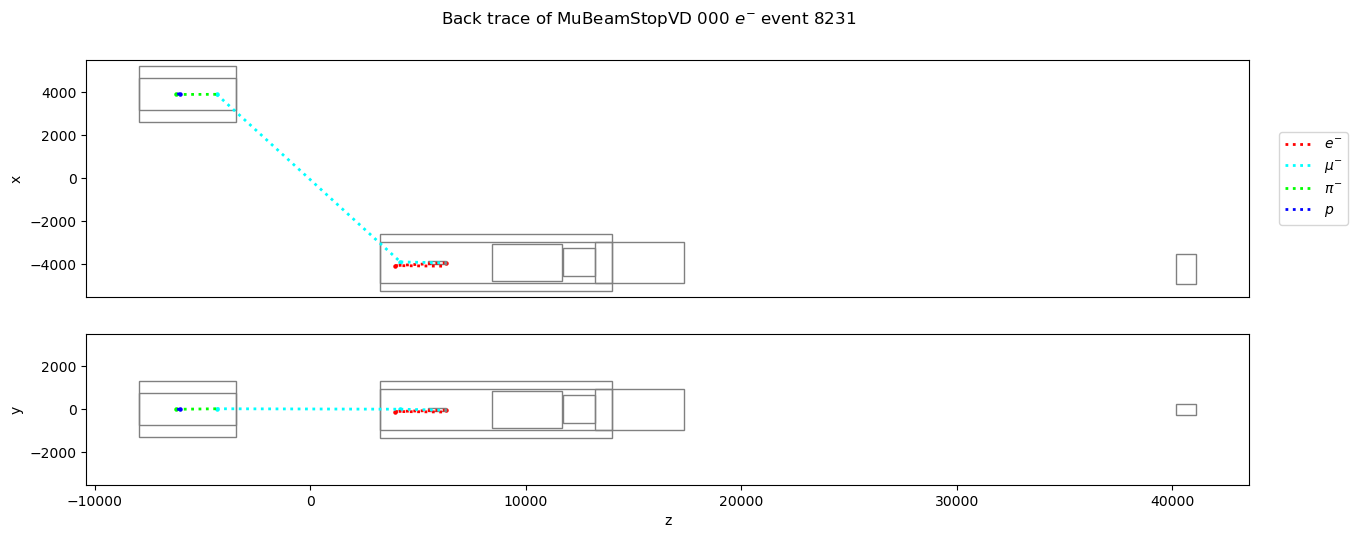

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     3341.445048
creationCode                   17
index                       14567
pdgId                          11
px                    1703.471643
py                    -916.622038
pz                    3292.141091
startpx               2426.123142
startpy              -5547.381878
startpz               2055.093288
starttime              990.416138
startx               -4056.249123
starty                 -81.359606
startz                3926.610088
time                  1003.652246
virtualdetectorId              10
x                    -4081.138115
y                      -99.820179
z                     6275.999996
weight                          1
r                      203.327273
Name: 3, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3912.712743,-58.305294,5648.757153,-22.953718,972.688416,-4035.340314,-60.214425,3904.921541,0.000000,990.788391,166
1,13,-3903.221432,-76.764449,4179.000000,24.368456,242.403030,-3912.712743,-58.305294,5648.757153,0.000000,264.742554,56
2,13,3370.514351,29.963976,-1264.632041,7.478252,77.415024,-3891.235643,-75.535199,4194.910547,24.399042,242.642471,14
3,-211,3910.140754,-0.525750,-6148.745240,91.653778,24.831852,3370.514351,29.963976,-1264.632041,39.635872,77.415024,101
4,2212,3932.363415,-0.432297,-6058.204294,-8624.851562,24.519121,3910.140754,-0.525750,-6148.745240,-8479.444336,24.831852,56


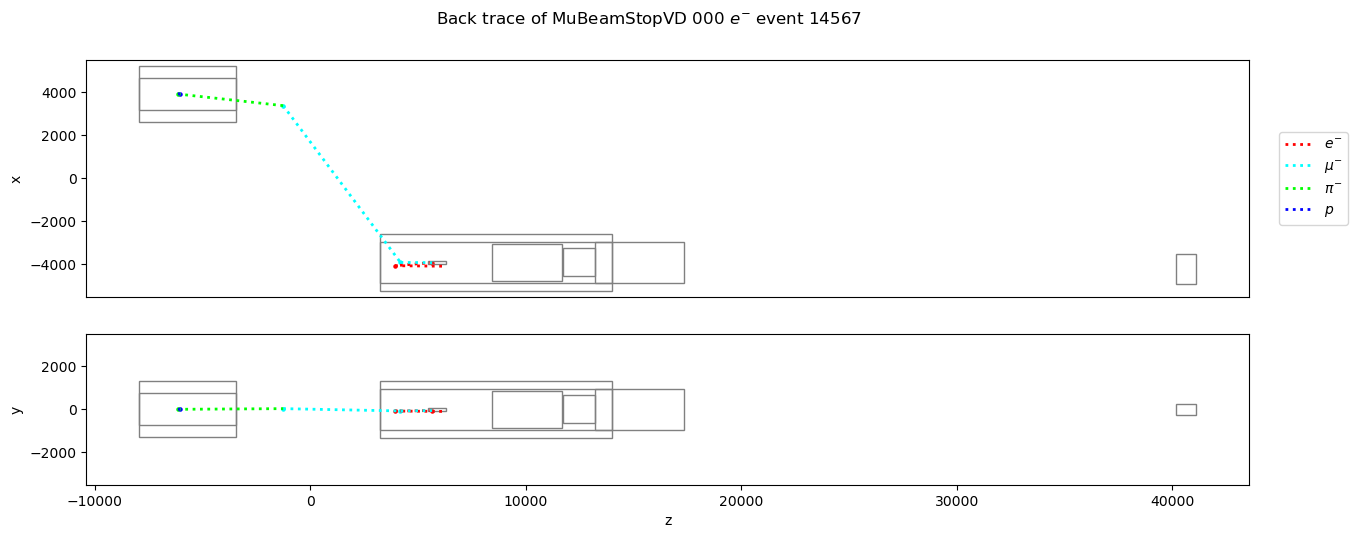

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     2166.910179
creationCode                   17
index                       14568
pdgId                          11
px                     702.465087
py                    -479.956241
pz                    2487.219735
startpx              -1851.265073
startpy              -2659.031153
startpz               1452.495456
starttime              990.128418
startx               -4049.343847
starty                  -2.969883
startz                3927.857194
time                   998.724272
virtualdetectorId              10
x                    -4079.320323
y                      -10.994886
z                     6275.999996
weight                          1
r                      175.664747
Name: 4, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3912.712743,-58.305294,5648.757153,-22.953718,972.688416,-4035.340314,-60.214425,3904.921541,0.000000,990.788391,166
1,13,-3903.221432,-76.764449,4179.000000,24.368456,242.403030,-3912.712743,-58.305294,5648.757153,0.000000,264.742554,56
2,13,3370.514351,29.963976,-1264.632041,7.478252,77.415024,-3891.235643,-75.535199,4194.910547,24.399042,242.642471,14
3,-211,3910.140754,-0.525750,-6148.745240,91.653778,24.831852,3370.514351,29.963976,-1264.632041,39.635872,77.415024,101
4,2212,3932.363415,-0.432297,-6058.204294,-8624.851562,24.519121,3910.140754,-0.525750,-6148.745240,-8479.444336,24.831852,56


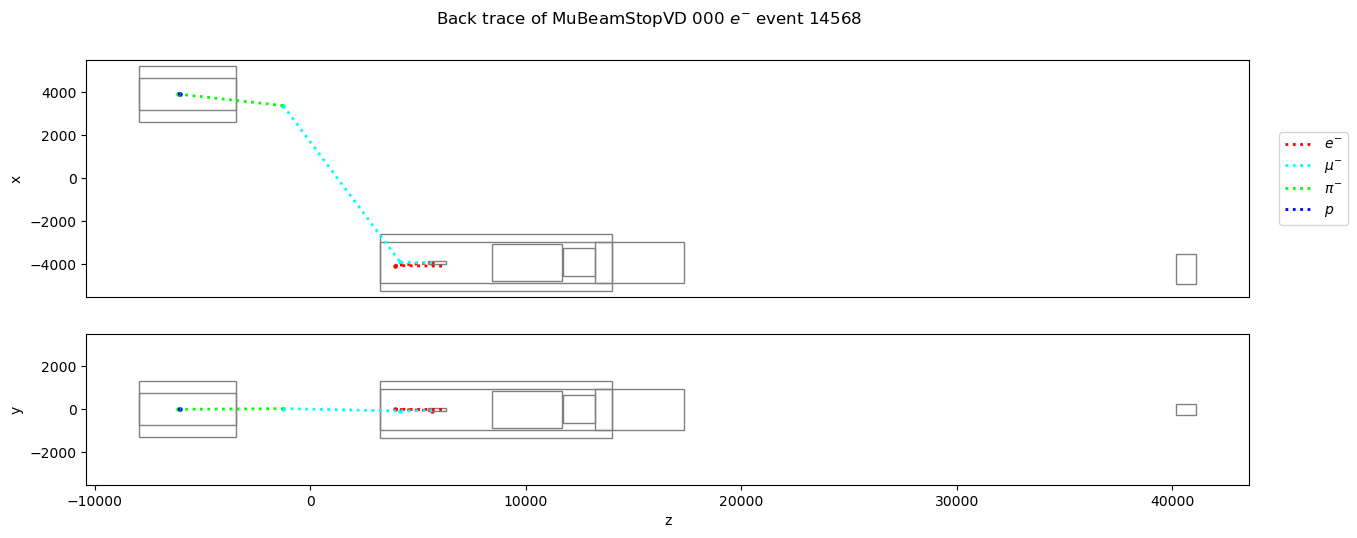

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     5661.650207
creationCode                   17
index                       15560
pdgId                          11
px                   -4594.048292
py                   -1149.517496
pz                    3926.042161
startpx               -213.440955
startpy              -5956.812382
startpz               4396.587849
starttime             1770.328369
startx                -851.914602
starty                 -42.475133
startz                  29.622524
time                   1859.96689
virtualdetectorId              10
x                    -3875.647728
y                      -76.533299
z                     6275.999996
weight                          1
r                       81.616157
Name: 5, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3853.027974,12.020311,5982.148287,-12.011024,1700.809204,-851.769572,-44.362061,31.950795,-0.000000,1770.339233,166
1,13,-3814.074670,33.958759,4179.000000,24.035250,316.570862,-3853.027974,12.020311,5982.148287,0.000000,343.833618,56
2,13,3897.490541,31.063029,-4594.576016,12.761121,77.785072,-3819.747384,48.394089,4191.556506,24.076752,316.766571,14
3,-211,3910.274065,-0.080338,-6146.006003,117.661850,49.043175,3897.490541,31.063029,-4594.576016,27.914200,77.785072,101
4,2212,3932.448317,-0.396259,-6058.225463,-8624.851562,48.739460,3910.274065,-0.080338,-6146.006003,-8455.807617,49.043175,56


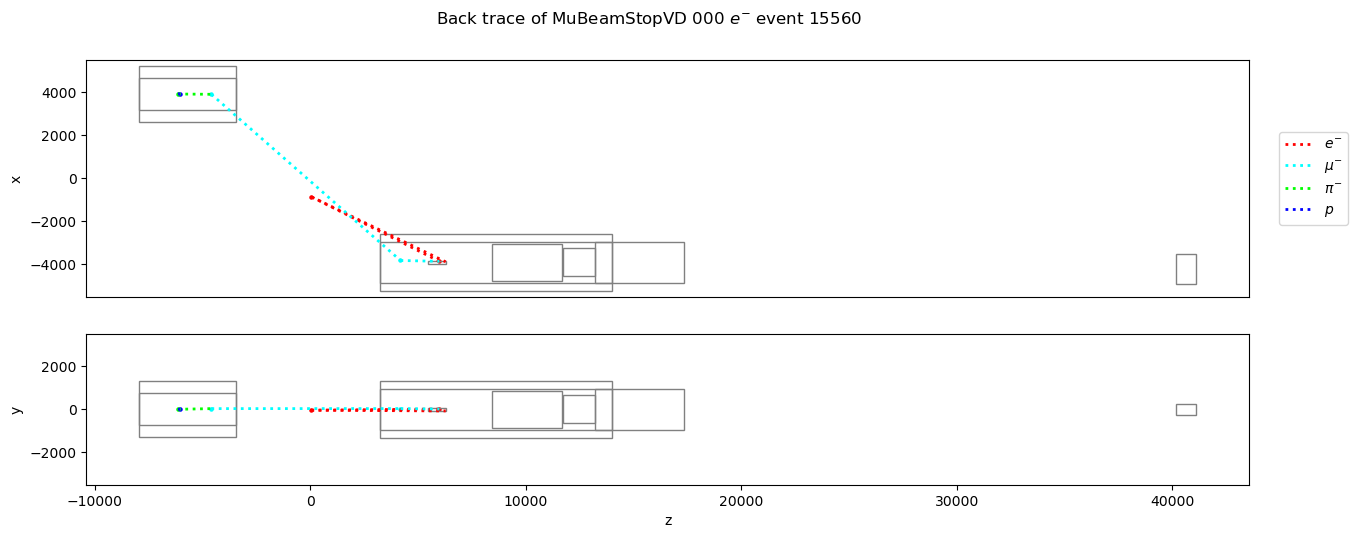

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      1151.37122
creationCode                   17
index                       15580
pdgId                          11
px                     363.168852
py                     748.929361
pz                    1345.201754
startpx              -1371.996164
startpy                338.466048
startpz                846.529782
starttime              914.602478
startx                -851.916879
starty                  -98.04051
startz                  64.724632
time                   951.146852
virtualdetectorId              10
x                    -3839.317578
y                     -124.340305
z                     6275.999996
weight                          1
r                      140.158221
Name: 6, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3844.904497,-31.560541,6159.873743,-2.504329,855.182312,-3787.174311,-298.913774,14685.746009,-0.000000,970.498657,166
1,13,-3794.025550,4.588893,4179.000000,28.868845,300.686981,-3844.904497,-31.560541,6159.873743,0.000000,327.101990,56
2,13,3983.104231,-20.076950,-6485.844634,21.794464,92.334129,-3801.579626,13.432268,4195.234549,28.897612,300.895996,14
3,-211,3896.197000,1.190161,-6197.943708,80.640015,47.017342,3983.104231,-20.076950,-6485.844634,-5.341540,92.334129,101
4,2212,3930.734740,0.739923,-6057.798220,-8624.851562,46.533146,3896.197000,1.190161,-6197.943708,-8461.668945,47.017342,56


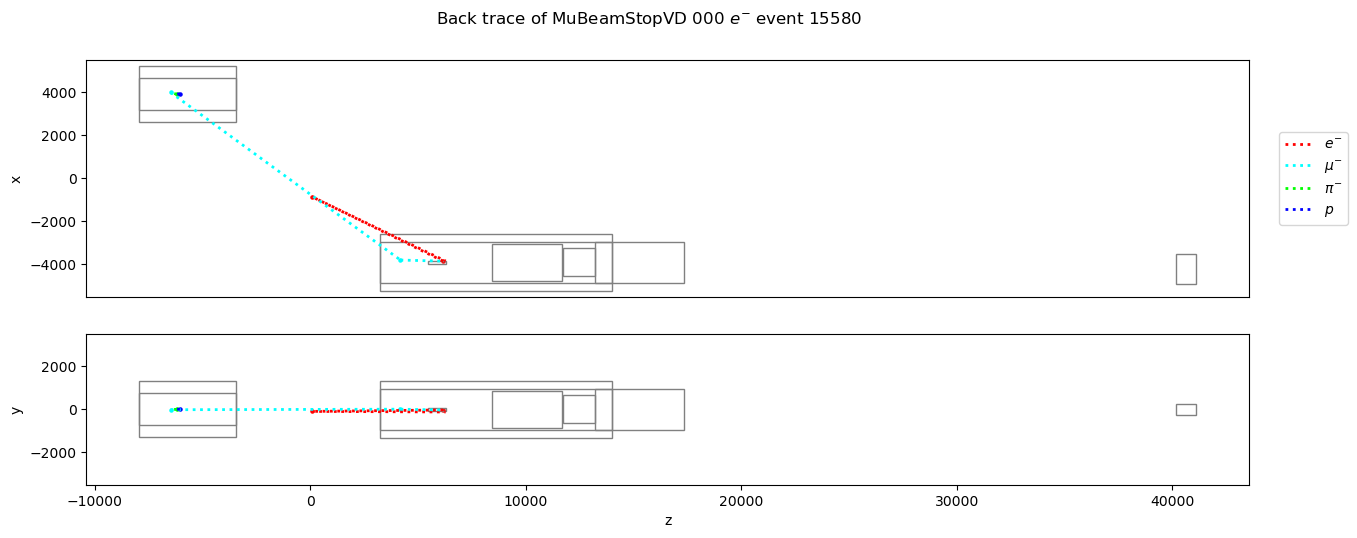

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     8330.243383
creationCode                   17
index                       17123
pdgId                          11
px                    -1721.53164
py                       6354.852
pz                    5878.658883
startpx               -898.490548
startpy              -9093.387604
startpz                4307.49464
starttime             1254.262329
startx               -4052.010435
starty                  -9.976345
startz                3926.922755
time                  1268.267363
virtualdetectorId              10
x                    -4051.506164
y                       -11.03729
z                     6275.999996
weight                          1
r                      147.918525
Name: 7, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3910.724175,20.869742,6204.282018,-23.073660,1228.838013,-4263.014968,49.182247,14778.575766,0.000000,1318.564941,166
1,13,-3850.316293,15.677010,4179.000000,41.996758,92.588074,-3910.724175,20.869742,6204.282018,0.000000,117.273018,56
2,13,3936.287984,-22.038365,-5639.108141,29.709139,-55.668819,-3851.437270,25.954879,4196.106442,42.009094,92.746361,14
3,-211,3918.172422,-0.402468,-6110.624168,48.648632,-61.519081,3936.287984,-22.038365,-5639.108141,39.434029,-55.668819,101
4,2212,3931.246533,-0.376103,-6057.925824,-8624.851562,-61.701210,3918.172422,-0.402468,-6110.624168,-8553.347656,-61.519081,56


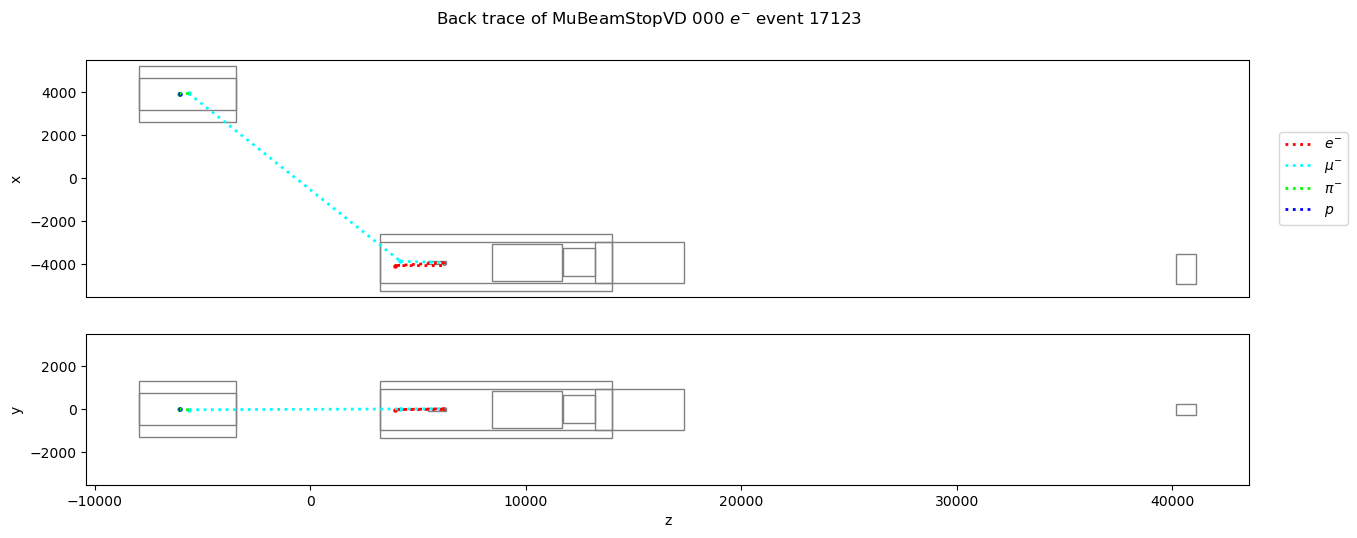

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     3770.170699
creationCode                   17
index                       18503
pdgId                          11
px                    1939.591488
py                    2307.938952
pz                    2996.447228
startpx               4626.134872
startpy                377.749562
startpz               2678.928137
starttime             3915.980713
startx               -3912.233185
starty                 -131.17805
startz                3926.441235
time                  3929.039799
virtualdetectorId              10
x                    -3912.136534
y                      -154.99485
z                     6275.999996
weight                          1
r                      155.208269
Name: 8, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3917.759233,-38.080428,5670.973687,-14.315551,3893.865479,-3908.564522,-128.919891,3864.706139,-0.000000,3917.152832,166
1,13,-3953.064805,-25.645102,4179.000000,22.683371,224.323471,-3917.759233,-38.080428,5670.973687,0.000000,248.417221,56
2,13,3864.229735,-13.903188,-5819.395366,5.205739,-55.457050,-3953.903583,-38.930384,4193.857437,22.715733,224.563599,14
3,-211,3884.679664,1.097164,-6238.101435,82.354286,-60.618195,3864.229735,-13.903188,-5819.395366,40.604027,-55.457050,101
4,2212,3930.447163,-0.179903,-6057.726519,-8624.851562,-61.242523,3884.679664,1.097164,-6238.101435,-8279.312500,-60.618195,56


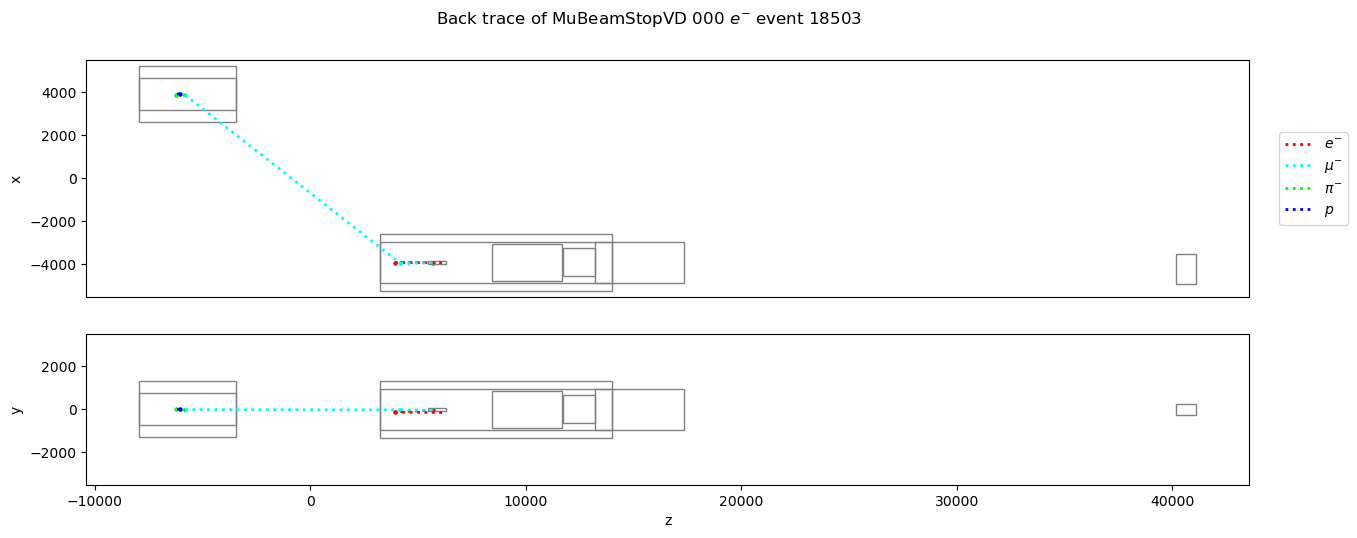

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     2088.263711
creationCode                   17
index                       19999
pdgId                          11
px                    -966.257209
py                    1237.875363
pz                    2007.251325
startpx              -3216.768265
startpy              -6241.391659
startpz              -5409.092426
starttime             2104.651367
startx                -849.991939
starty                 -78.303861
startz                  30.994632
time                  2146.156332
virtualdetectorId              10
x                    -3884.776163
y                     -107.959792
z                     6275.999996
weight                          1
r                       109.65798
Name: 9, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3878.031526,-31.439852,6204.288112,-27.103884,2052.325195,-851.879784,-79.332204,30.746313,0.000000,2104.658203,166
1,13,-3825.652856,-29.125175,4179.000000,28.107807,225.567047,-3878.031526,-31.439852,6204.288112,0.000000,253.335388,56
2,13,3905.986752,17.499466,-4308.123568,25.142321,38.417629,-3827.741726,-14.553825,4192.489100,28.135220,225.748779,14
3,-211,3923.231941,-0.660163,-6087.847214,86.702431,20.442760,3905.986752,17.499466,-4308.123568,52.528854,38.417629,101
4,2212,3930.857001,-0.691429,-6057.828703,-8624.851562,20.338873,3923.231941,-0.660163,-6087.847214,-8578.388672,20.442760,56


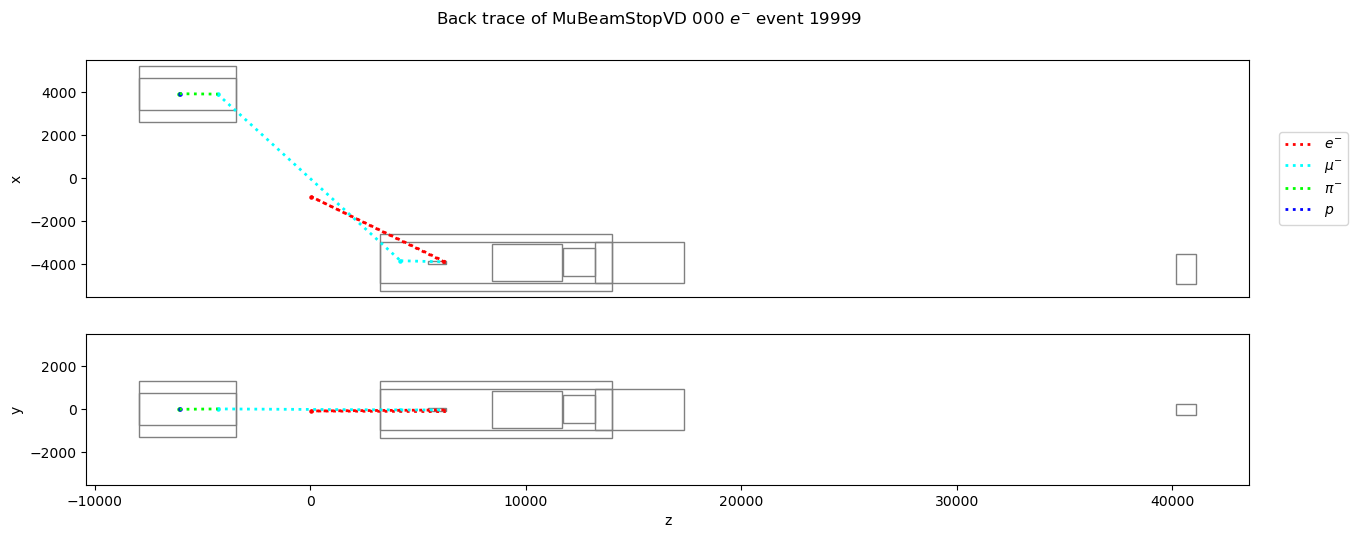

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      469.796037
creationCode                   35
index                          10
pdgId                          22
px                      34.376994
py                     389.277169
pz                    -260.748585
startpx                663.478255
startpy                 144.40386
startpz               -485.701054
starttime            14190.091797
startx               -3855.185444
starty                -967.150133
startz                7019.361958
time                 14194.556615
virtualdetectorId              10
x                    -3746.803069
y                       132.54502
z                     6276.019996
weight                          1
r                      205.618719
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-2670.638545,471.451413,6214.993288,13.915271,814.141541,-3855.185444,-967.150133,7019.361958,0.976529,14190.091797,97
1,2112,-3858.347083,-15.627955,5804.288156,75.774811,796.569885,-2670.638545,471.451413,6214.993288,75.774811,814.141541,165
2,13,-3851.935659,-42.241770,4179.000000,28.196339,189.683884,-3858.347083,-15.627955,5804.288156,0.000000,212.484222,56
3,13,3931.018231,1.785981,-4522.463319,31.890921,16.191736,-3841.299730,-41.574531,4195.891804,28.212446,189.905273,14
4,-211,3929.396796,-1.579238,-6061.712586,102.836433,4.207484,3931.018231,1.785981,-4522.463319,68.423134,16.191736,101
5,2212,3930.388782,-1.584081,-6057.711963,-8624.851562,4.193659,3929.396796,-1.579238,-6061.712586,-8622.008789,4.207484,56


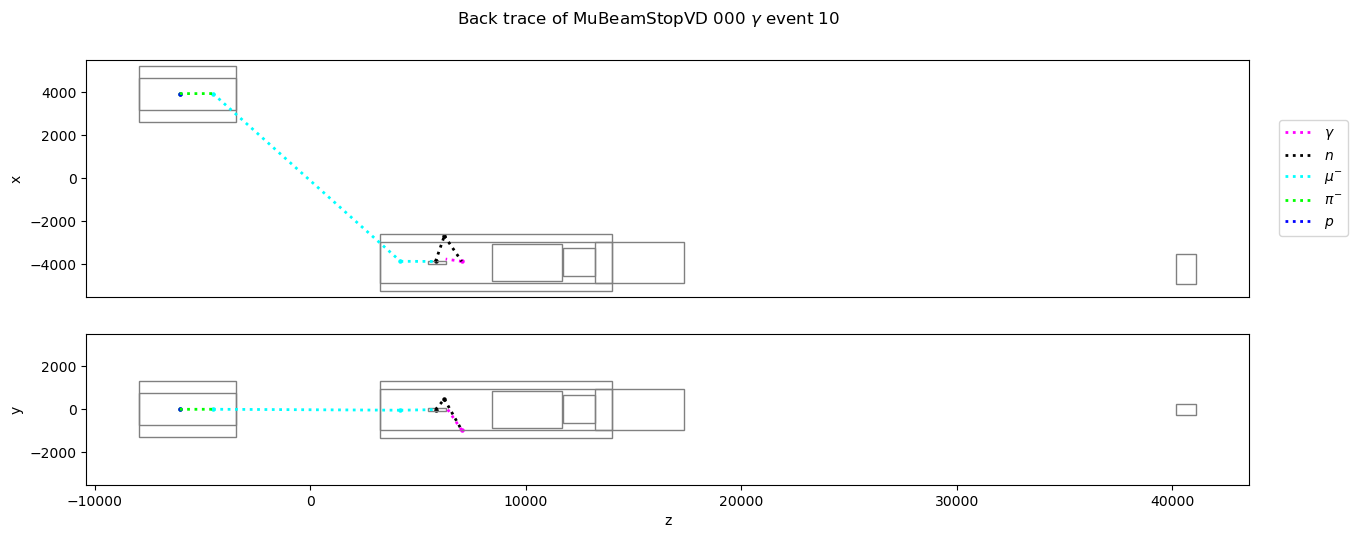

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      111.591631
creationCode                   35
index                          31
pdgId                          22
px                      19.949309
py                      14.311681
pz                     108.857213
startpx                 -5.387663
startpy               3424.587011
startpz                211.542055
starttime            13355.729492
startx               -4156.767683
starty                 -90.796824
startz                4173.678271
time                 13367.609224
virtualdetectorId              10
x                    -3759.642239
y                      552.738654
z                     6275.999996
weight                          1
r                      571.278551
Name: 1, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3898.520549,56.127138,5804.322127,-30.228397,538.611328,-4156.767683,-90.796824,4173.678271,0.015987,13355.729492,165
1,13,-3887.526057,44.943429,4179.000000,35.813908,212.561523,-3898.520549,56.127138,5804.322127,-0.000000,230.650696,56
2,13,3907.579169,40.215274,-4399.292265,38.574501,72.725342,-3892.295266,48.659394,4198.057005,35.820522,212.760559,14
3,-211,3894.138324,0.575767,-6208.707530,-8.335519,5.038272,3907.579169,40.215274,-4399.292265,46.015896,72.725342,97
4,2112,3896.114456,0.580999,-6200.361593,-7598.351562,5.009457,3894.138324,0.575767,-6208.707530,-7598.351562,5.038272,101
5,2212,3930.776966,0.315224,-6057.808748,-8624.851562,4.517304,3896.114456,0.580999,-6200.361593,-8424.822266,5.009457,56


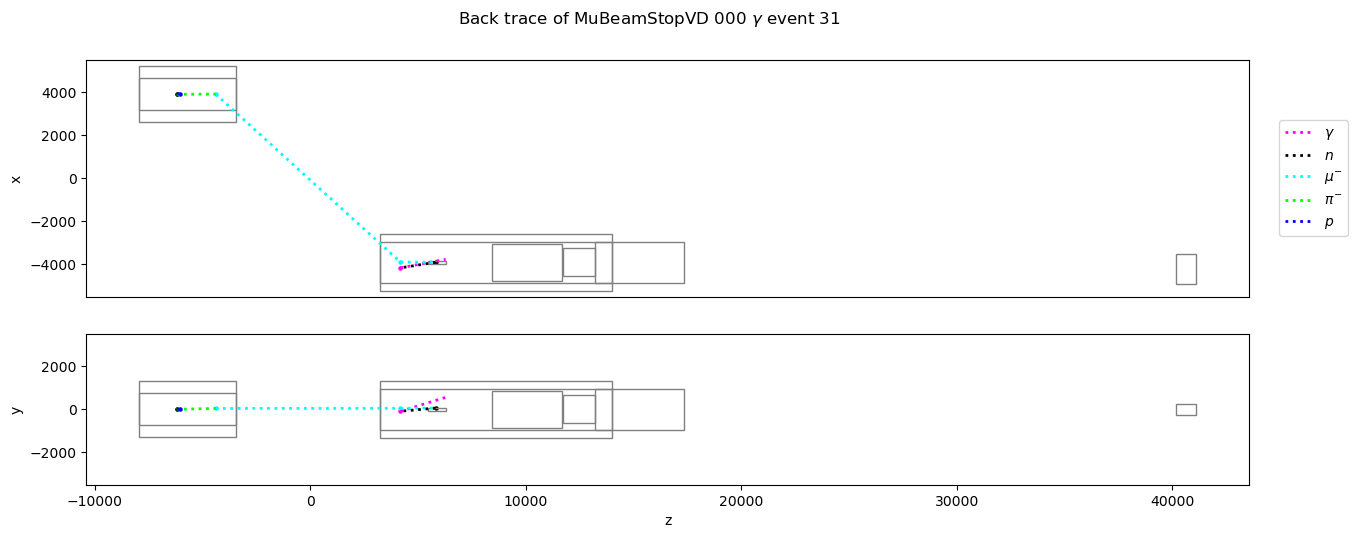

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      105.587675
creationCode                   35
index                          37
pdgId                          22
px                      42.961603
py                      -26.36374
pz                     -92.779367
startpx                 42.961605
startpy                 -26.36374
startpz                -92.779368
starttime            38805.335938
startx               -4479.269683
starty                 474.731651
startz                8523.766512
time                  38813.86685
virtualdetectorId              10
x                    -3438.447815
y                     -163.977215
z                     6276.019996
weight                          1
r                      493.586228
Name: 2, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-2853.440889,8.383755,5867.174268,-18.393211,714.985840,-4479.269683,474.731651,8523.766512,-0.003431,38805.335938,97
1,2112,-2805.726534,106.157380,5895.252523,-15.527641,709.306213,-2853.440889,8.383755,5867.174268,-15.527641,714.985840,97
2,2112,-3927.351111,-21.780106,5493.231472,56.990108,685.163452,-2805.726534,106.157380,5895.252523,-107.736633,709.306213,165
3,13,-3896.941026,0.837187,4179.000000,15.840472,265.486359,-3927.351111,-21.780106,5493.231472,0.000000,294.576538,56
4,13,3857.721074,4.598724,-2438.969826,20.096668,17.848291,-3899.467017,13.742078,4193.929041,15.834594,265.825226,14
5,-211,3926.215405,0.923662,-6065.988657,91.554832,-20.634811,3857.721074,4.598724,-2438.969826,45.354160,17.848291,101
6,2212,3928.393632,0.912724,-6057.214516,-8624.851562,-20.665136,3926.215405,0.923662,-6065.988657,-8613.815430,-20.634811,56


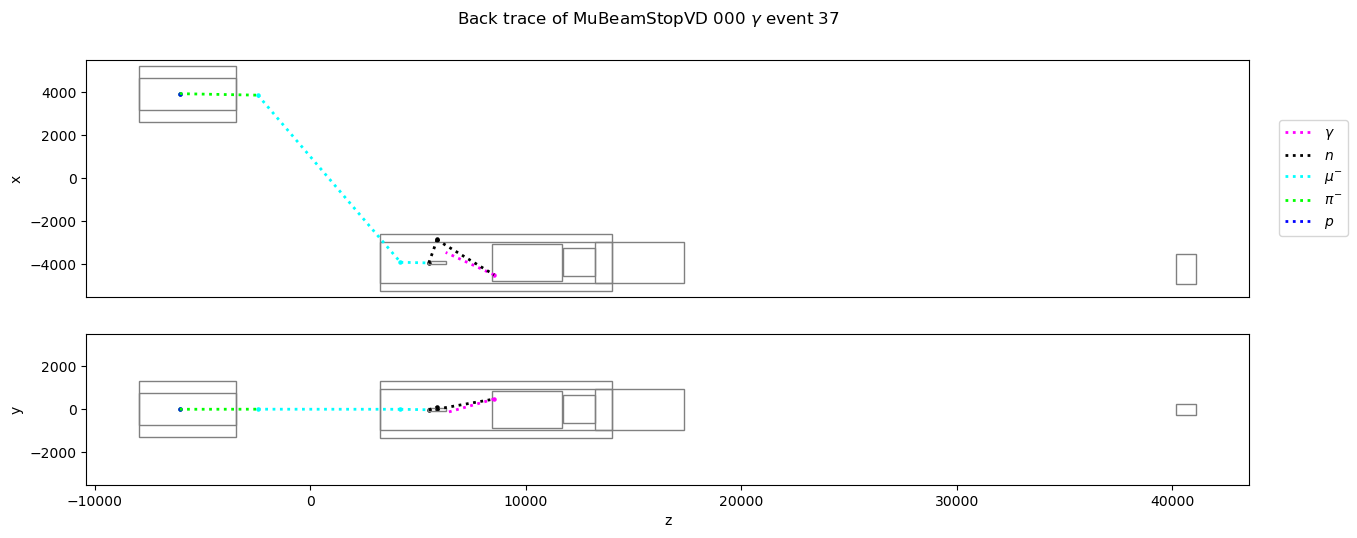

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                       569.077008
creationCode                    35
index                          257
pdgId                           22
px                      356.914426
py                         30.9017
pz                     -442.160399
startpx                1059.405088
startpy                -2456.51269
startpz                -262.580246
starttime             254684.78125
startx                -4529.716947
starty                 -387.694868
startz                 7083.138154
time                 254688.402669
virtualdetectorId               10
x                     -3860.671038
y                      -382.944524
z                      6276.019996
weight                           1
r                       385.387996
Name: 3, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3841.964424,0.705355,5826.577209,27.774403,329.142914,-4529.716947,-387.694868,7083.138154,0.001650,254684.781250,165
1,13,-3879.540289,58.552171,4179.000000,24.955599,214.857193,-3841.964424,0.705355,5826.577209,-0.000000,239.414612,56
2,13,3927.338834,-9.677479,-5628.214104,13.884819,-14.096010,-3884.608224,45.776919,4193.469821,24.964758,215.072113,14
3,-211,3922.169281,-0.382021,-6093.111094,78.745041,-19.599125,3927.338834,-9.677479,-5628.214104,47.987793,-14.096010,101
4,2212,3931.085612,-0.348186,-6057.885702,-8624.851562,-19.721008,3922.169281,-0.382021,-6093.111094,-8564.291992,-19.599125,56


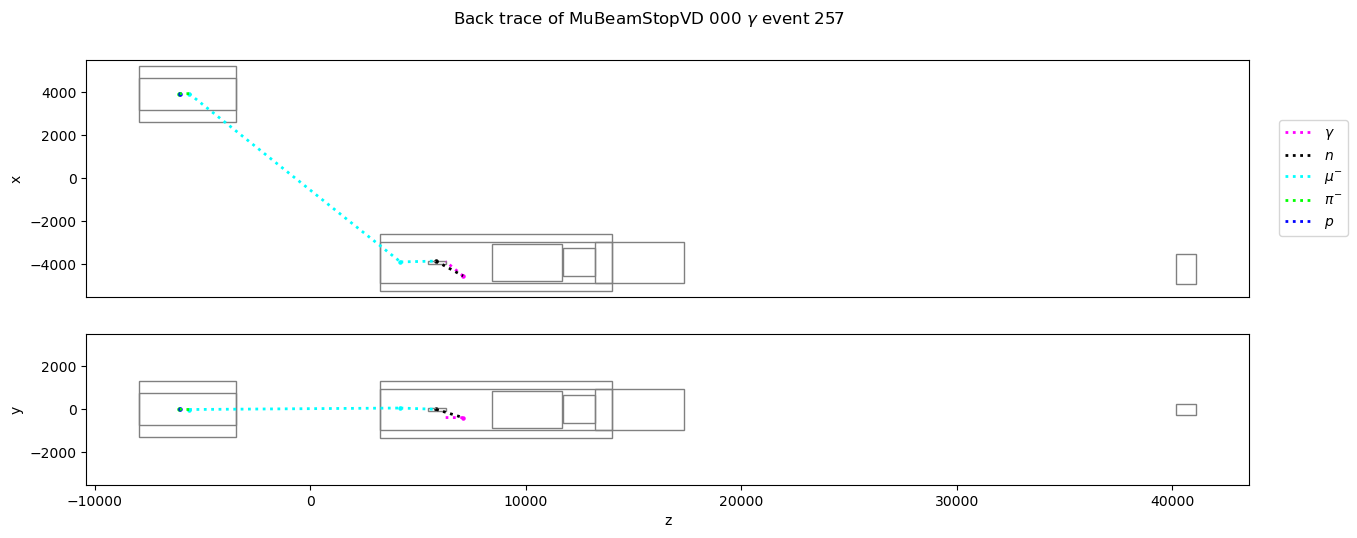

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                       402.604197
creationCode                    35
index                          258
pdgId                           22
px                        62.63318
py                       193.18296
pz                     -347.631368
startpx               -2124.493599
startpy                -603.890777
startpz               -2965.627909
starttime             254684.78125
startx                -4529.716947
starty                 -387.694868
startz                 7083.138154
time                 254687.900353
virtualdetectorId               10
x                     -4386.029671
y                        57.625123
z                      6276.019996
weight                           1
r                       485.461902
Name: 4, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3841.964424,0.705355,5826.577209,27.774403,329.142914,-4529.716947,-387.694868,7083.138154,0.001650,254684.781250,165
1,13,-3879.540289,58.552171,4179.000000,24.955599,214.857193,-3841.964424,0.705355,5826.577209,-0.000000,239.414612,56
2,13,3927.338834,-9.677479,-5628.214104,13.884819,-14.096010,-3884.608224,45.776919,4193.469821,24.964758,215.072113,14
3,-211,3922.169281,-0.382021,-6093.111094,78.745041,-19.599125,3927.338834,-9.677479,-5628.214104,47.987793,-14.096010,101
4,2212,3931.085612,-0.348186,-6057.885702,-8624.851562,-19.721008,3922.169281,-0.382021,-6093.111094,-8564.291992,-19.599125,56


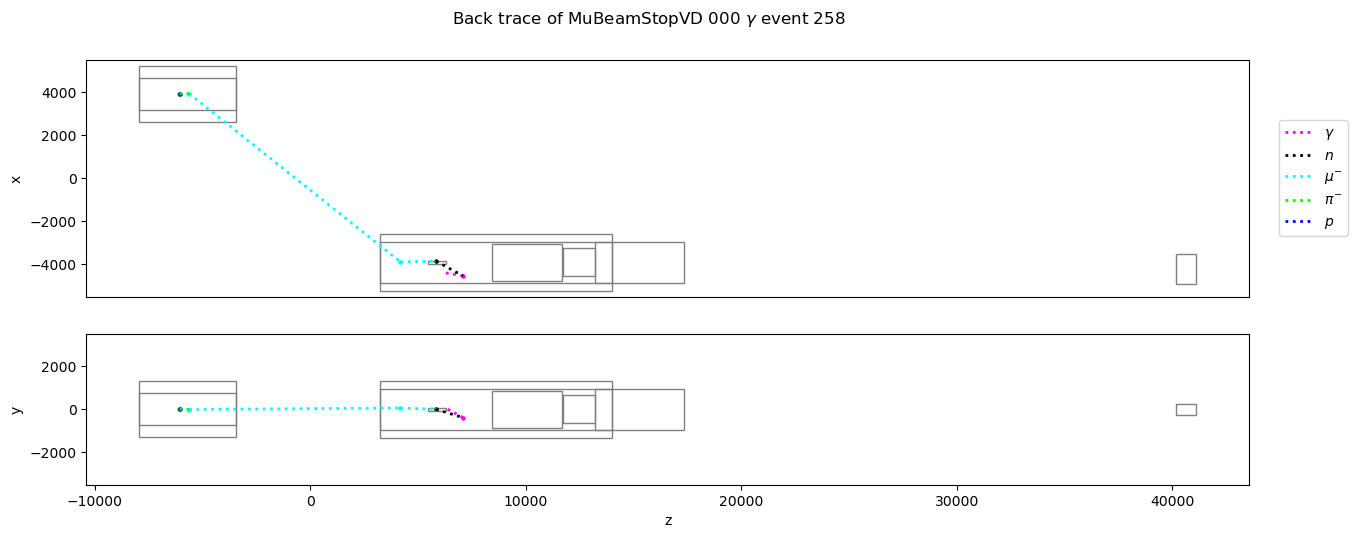

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                      7631.157805
creationCode                    35
index                          302
pdgId                           22
px                    -2739.539463
py                     3197.527567
pz                    -6364.378245
startpx               -2739.539385
startpy                3197.527647
startpz               -6364.378452
starttime              770715.1875
startx                -3074.994269
starty                 -469.068501
startz                 8104.450945
time                 770722.478829
virtualdetectorId               10
x                     -3862.040316
y                       449.553576
z                      6276.019996
weight                           1
r                       451.507512
Name: 5, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-4337.994245,-859.287914,5714.741113,-19.170143,367.523651,-3074.994269,-469.068501,8104.450945,-0.003386,770715.187500,97
1,2112,-4412.016917,-702.394627,5882.019235,31.419016,280.987518,-4337.994245,-859.287914,5714.741113,15.442000,367.523651,97
2,2112,-3877.475050,-3.325742,6248.830169,-54.151585,253.553223,-4412.016917,-702.394627,5882.019235,-24.849380,280.987518,165
3,13,-3894.741611,-14.578422,4179.000000,28.561480,210.935440,-3877.475050,-3.325742,6248.830169,0.000000,239.129807,56
4,13,3924.268650,6.361529,-2931.944310,30.108454,55.393860,-3889.262819,-11.366332,4197.952039,28.562914,211.178619,14
5,-211,3912.905018,-0.731590,-6131.512684,114.286087,31.227581,3924.268650,6.361529,-2931.944310,69.475464,55.393860,101
6,2212,3931.307225,-1.135401,-6057.940957,-8624.851562,30.973183,3912.905018,-0.731590,-6131.512684,-8516.411133,31.227581,56


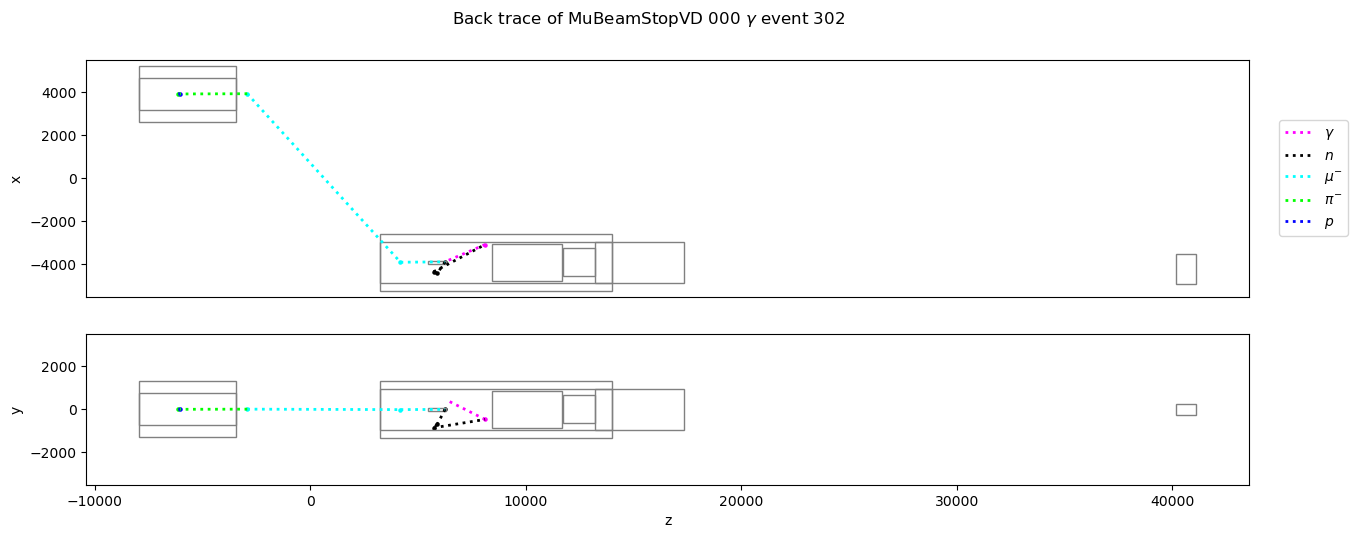

------------------------------------------------------------------------------


tag                    MuBeamStopVD
fileno                            0
E                       2131.741578
creationCode                     35
index                           345
pdgId                            22
px                      -564.671079
py                      1558.567139
pz                     -1340.275047
startpx                 -564.671099
startpy                 1558.567166
startpz                -1340.275049
starttime               1420875.625
startx                 -3319.492165
starty                  -237.766098
startz                  6746.246316
time                 1420878.161709
virtualdetectorId                10
x                      -3517.603145
y                        309.046507
z                       6276.019996
weight                            1
r                        494.785078
Name: 6, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-4238.945585,-2071.765377,4226.241090,-3.285101,1048.847290,-3319.492165,-237.766098,6746.246316,-0.003888,1.420876e+06,97
1,2112,-3933.173656,-42.023199,5582.148846,-11.439049,943.699280,-4238.945585,-2071.765377,4226.241090,-63.466030,1.048847e+03,165
2,13,-3883.230509,-27.048126,4179.000000,20.998308,279.224121,-3933.173656,-42.023199,5582.148846,0.000000,3.032641e+02,56
3,13,3870.314552,-9.508176,-5505.116233,-6.004653,-36.678844,-3890.847706,-17.240667,4194.603386,20.991470,2.794944e+02,14
4,-211,3892.415932,13.175003,-6177.995147,3.573159,-64.985001,3870.314552,-9.508176,-5505.116233,22.429573,-3.667884e+01,100
5,-211,3911.946216,0.260925,-6134.601333,-1982.930664,-65.149803,3892.415932,13.175003,-6177.995147,-1929.610229,-6.498500e+01,101
6,2212,3931.154723,0.339284,-6057.902934,-8624.851562,-65.415031,3911.946216,0.260925,-6134.601333,-8507.529297,-6.514980e+01,56


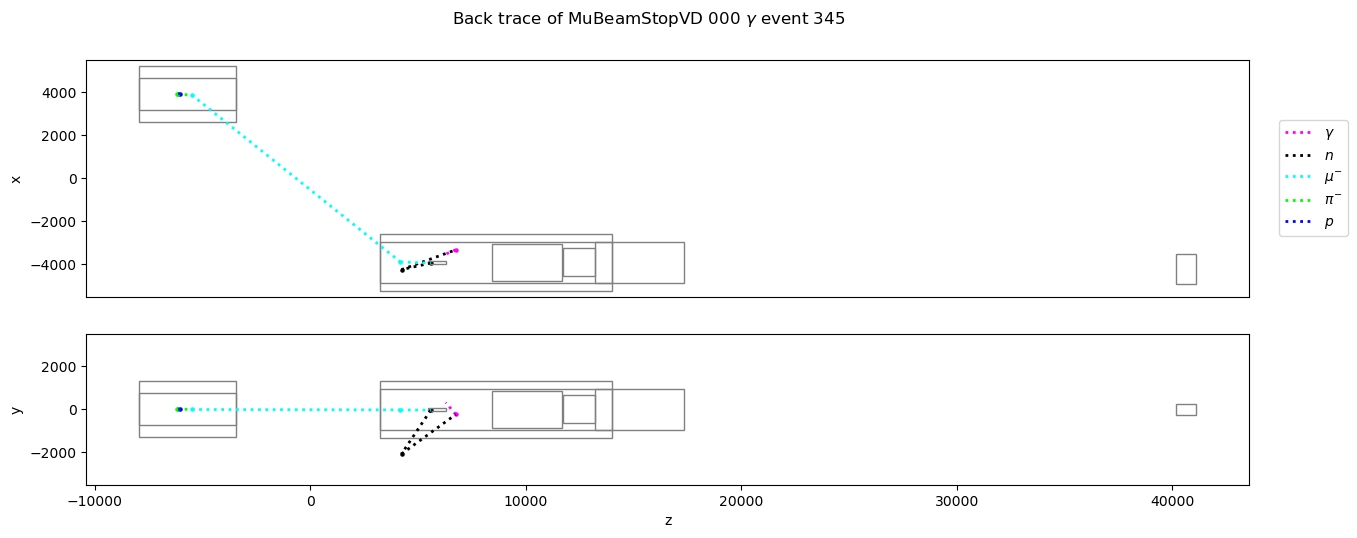

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      477.168788
creationCode                    2
index                         362
pdgId                          22
px                    -117.158014
py                     408.065075
pz                    -217.823201
startpx               -157.880634
startpy                483.482242
startpz                -49.381208
starttime             1459.093994
startx               -3172.688661
starty                -609.784119
startz                6580.342649
time                  1462.583746
virtualdetectorId              10
x                     -3460.10161
y                      328.702305
z                     6276.019996
weight                          1
r                       552.35042
Name: 7, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,-11,-3172.984834,-609.668512,6580.215203,1.221771,1459.092285,-3172.688661,-609.784119,6580.342649,-0.000000,1459.093994,13
1,22,-3856.335736,49.366639,5671.027792,3.046542,1454.707520,-3172.984834,-609.668512,6580.215203,3.046542,1459.092285,165
2,13,-3875.454996,49.260559,4179.000000,32.889275,166.207581,-3856.335736,49.366639,5671.027792,0.000000,183.731674,56
3,13,3914.468886,34.258907,-5881.405380,36.972538,2.505319,-3875.536916,52.416309,4198.746916,32.890186,166.429459,14
4,-211,3891.424190,1.130127,-6205.974106,134.187042,0.339093,3914.468886,34.258907,-5881.405380,83.788788,2.505319,101
5,2212,3929.690370,0.952028,-6057.537829,-8624.851562,-0.175161,3891.424190,1.130127,-6205.974106,-8336.237305,0.339093,56


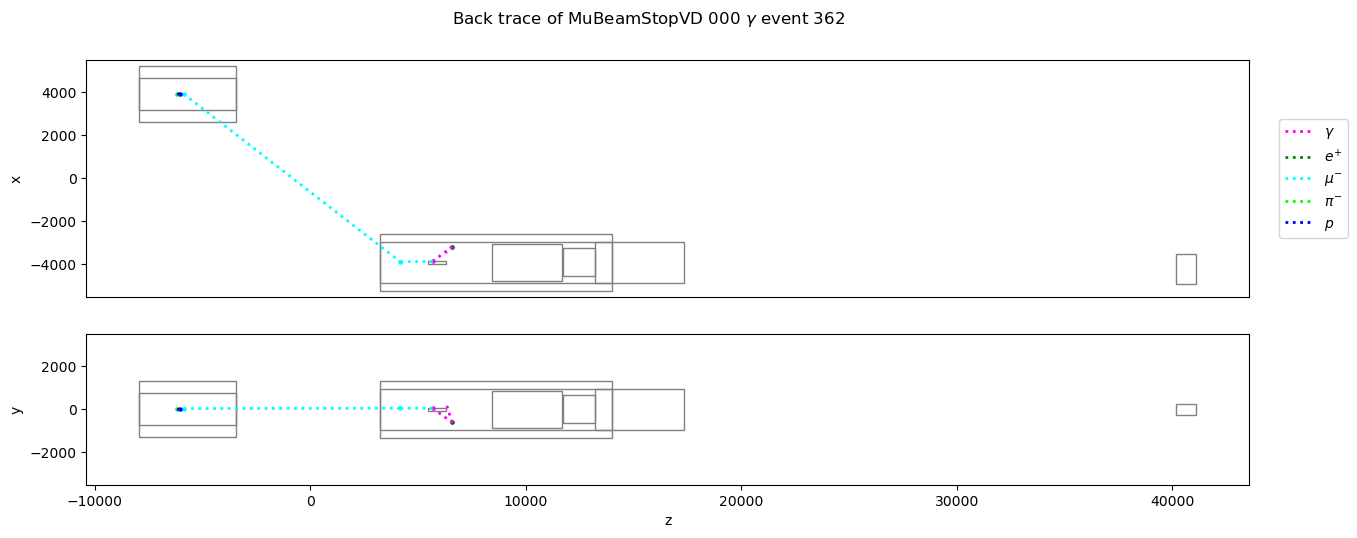

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                      4416.555212
creationCode                    35
index                          386
pdgId                           22
px                     -770.005407
py                     1307.154854
pz                    -4147.818439
startpx                -770.005405
startpy                1307.154894
startpz               -4147.818565
starttime              1421694.625
startx                -4108.755085
starty                   -632.0443
startz                 7077.541386
time                 1421697.44763
virtualdetectorId               10
x                     -4257.550364
y                      -379.450655
z                      6276.019996
weight                           1
r                       518.633454
Name: 8, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3936.286826,-46.553946,5848.744093,-8.299434,662.211243,-4108.755085,-632.044300,7077.541386,0.002294,1.421695e+06,165
1,13,-3912.290377,-53.422804,4179.000000,27.812752,154.128540,-3936.286826,-46.553946,5848.744093,0.000000,1.784181e+02,56
2,13,3838.118248,-32.009751,-3895.671456,27.122665,-25.843962,-3914.681536,-41.876346,4195.114779,27.796738,1.543434e+02,14
3,-211,3888.396590,2.521154,-6227.909649,98.057884,-42.775093,3838.118248,-32.009751,-3895.671456,77.730827,-2.584396e+01,101
4,2212,3930.590611,0.922111,-6057.762285,-8624.851562,-43.363213,3888.396590,2.521154,-6227.909649,-8343.472656,-4.277509e+01,56


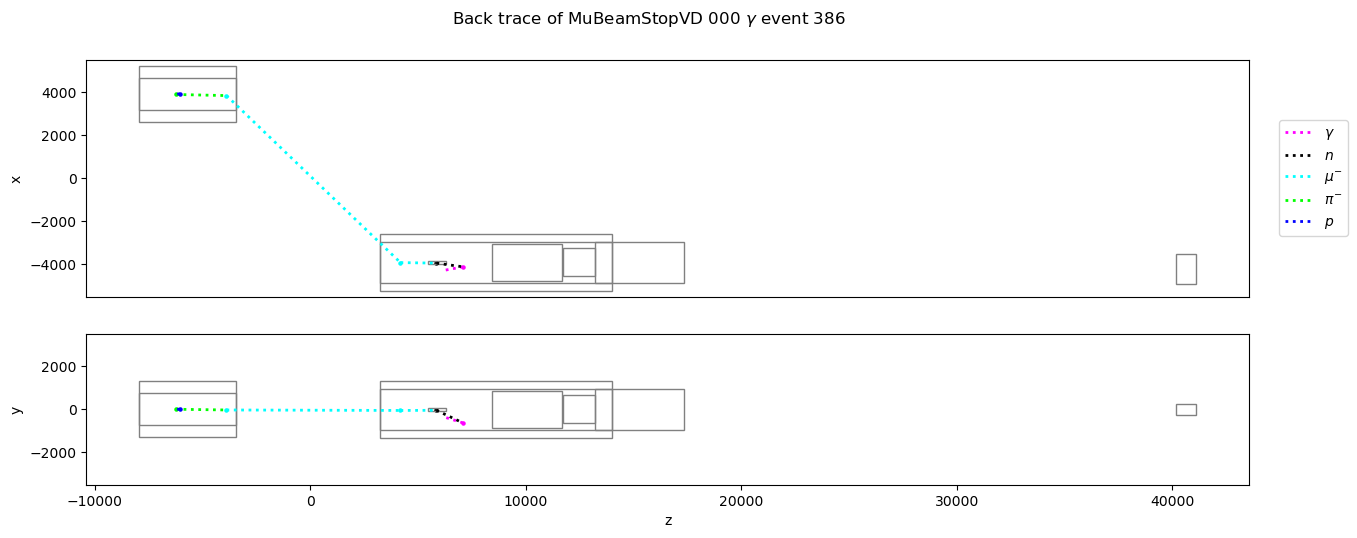

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1722.475526
creationCode                   35
index                         392
pdgId                          22
px                    -691.161183
py                      433.91663
pz                   -1516.883158
startpx               -691.161156
startpy                433.916628
startpz              -1516.883135
starttime            482485.34375
startx               -3267.834573
starty                  -81.09397
startz                6918.529234
time                 482487.76597
virtualdetectorId              10
x                      -3560.5911
y                      102.700966
z                     6276.019996
weight                          1
r                      358.437109
Name: 9, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3137.334482,-218.695574,9698.559255,-6.769634,621.848389,-3267.834573,-81.093970,6918.529234,0.002084,482485.343750,97
1,2112,-3214.570022,-266.350726,9648.993783,35.146515,613.372864,-3137.334482,-218.695574,9698.559255,-16.165726,621.848389,97
2,2112,-3935.082763,-4.481377,5693.251004,-75.690529,404.738495,-3214.570022,-266.350726,9648.993783,-39.433777,613.372864,165
3,13,-3940.604626,32.171892,4179.000000,25.482441,252.355682,-3935.082763,-4.481377,5693.251004,0.000000,274.745972,56
4,13,3909.811725,18.183575,-5504.142004,18.065983,29.640863,-3949.541427,23.109837,4194.375899,25.510937,252.578445,14
5,-211,3894.592802,0.152558,-6196.260508,30.036556,15.132492,3909.811725,18.183575,-5504.142004,25.559885,29.640863,101
6,2212,3929.186349,0.276366,-6057.412163,-8624.851562,14.652473,3894.592802,0.152558,-6196.260508,-8413.056641,15.132492,56


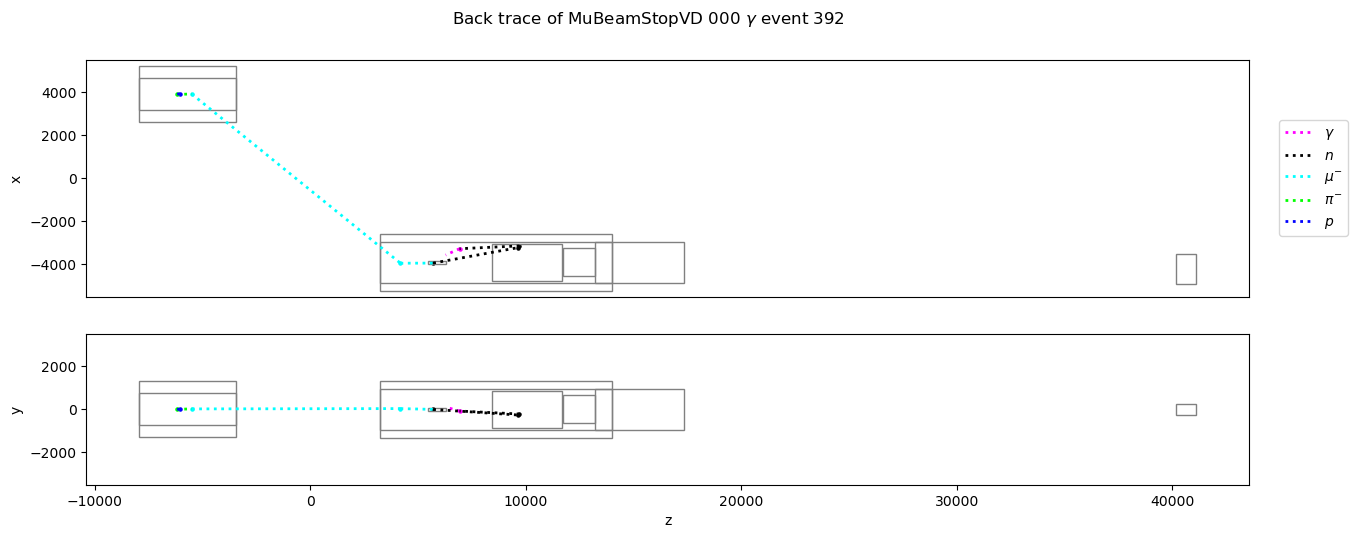

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                         0.000013
creationCode                    97
index                          353
pdgId                         2112
px                       -1.814401
py                        2.539227
pz                        3.863868
startpx               -4116.015434
startpy                22146.73233
startpz                27707.00264
starttime               822.896545
startx                -3569.420559
starty                 -902.375589
startz                 5307.219316
time                 212019.348106
virtualdetectorId               10
x                     -3714.349964
y                      -311.395575
z                      6275.999996
weight                           1
r                       364.601618
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3929.505604,-61.022979,5759.860739,-38.245483,785.726501,-3569.420559,-902.375589,5307.219316,-49.945183,822.896545,165
1,13,-3907.150395,-69.641853,4179.000000,35.342621,138.570480,-3929.505604,-61.022979,5759.860739,0.000000,156.588379,56
2,13,3864.550136,-72.008037,-2648.139820,37.179340,11.543298,-3904.631298,-64.337099,4198.111073,35.344082,138.772385,14
3,-211,3923.398994,-36.274244,-6109.045838,67.701714,-14.872720,3864.550136,-72.008037,-2648.139820,70.117195,11.543298,14
4,310,3923.363192,0.675436,-6087.782461,-216.012009,-15.089325,3923.398994,-36.274244,-6109.045838,-216.012009,-14.872720,101
5,2212,3930.868048,0.650420,-6057.831458,-8624.851562,-15.192895,3923.363192,0.675436,-6087.782461,-8579.079102,-15.089325,56


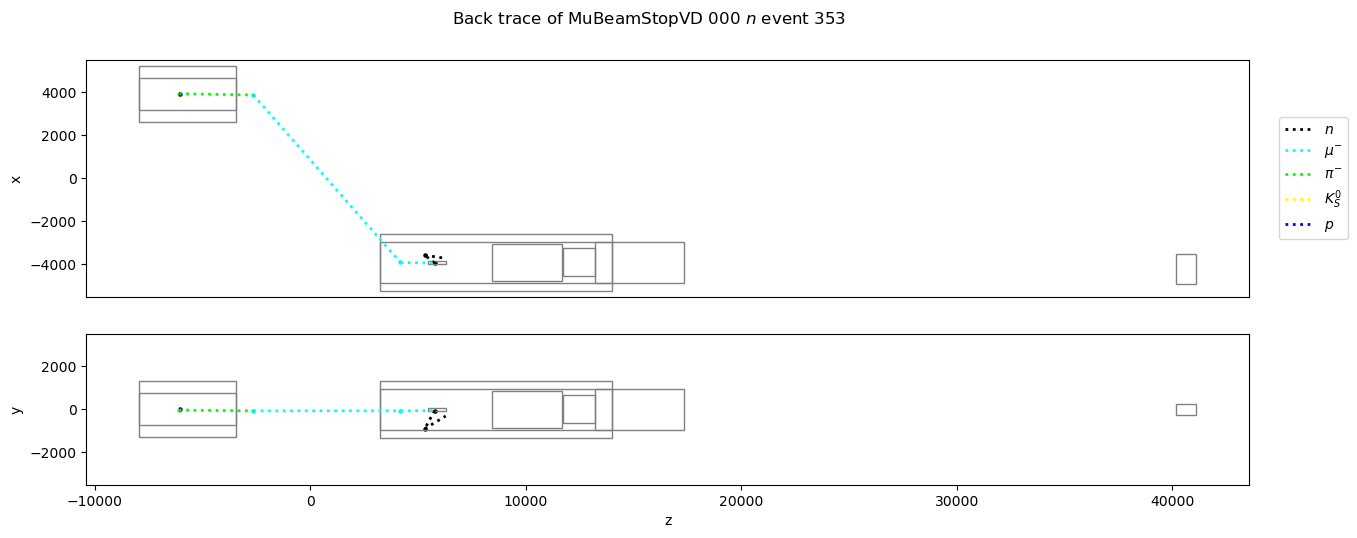

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      865.215018
creationCode                   97
index                         407
pdgId                        2112
px                  -21269.866302
py                  -14845.317673
pz                   30883.815311
startpx              -27535.12764
startpy             -32575.889587
startpz              33012.199402
starttime              705.068604
startx               -4485.290492
starty                -774.095564
startz                3824.604126
time                  1161.006218
virtualdetectorId              10
x                    -4292.282834
y                     -241.508186
z                     6275.999996
weight                          1
r                      457.263341
Name: 1, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3901.541579,59.200046,5804.282553,-75.906715,622.884277,-4485.290492,-774.095564,3824.604126,-46.845982,705.068604,165
1,13,-3937.281097,57.687030,4179.000000,30.445618,189.872253,-3901.541579,59.200046,5804.282553,0.000000,211.940170,56
2,13,3884.015107,31.221894,-5417.573793,37.003155,22.497725,-3936.163769,54.092932,4198.638407,30.450315,190.109161,14
3,-211,3920.903875,-0.457069,-6100.140127,-0.623643,9.007753,3884.015107,31.221894,-5417.573793,30.915030,22.497725,101
4,2212,3931.290788,-0.480221,-6057.936858,-8624.851562,8.861966,3920.903875,-0.457069,-6100.140127,-8580.493164,9.007753,56


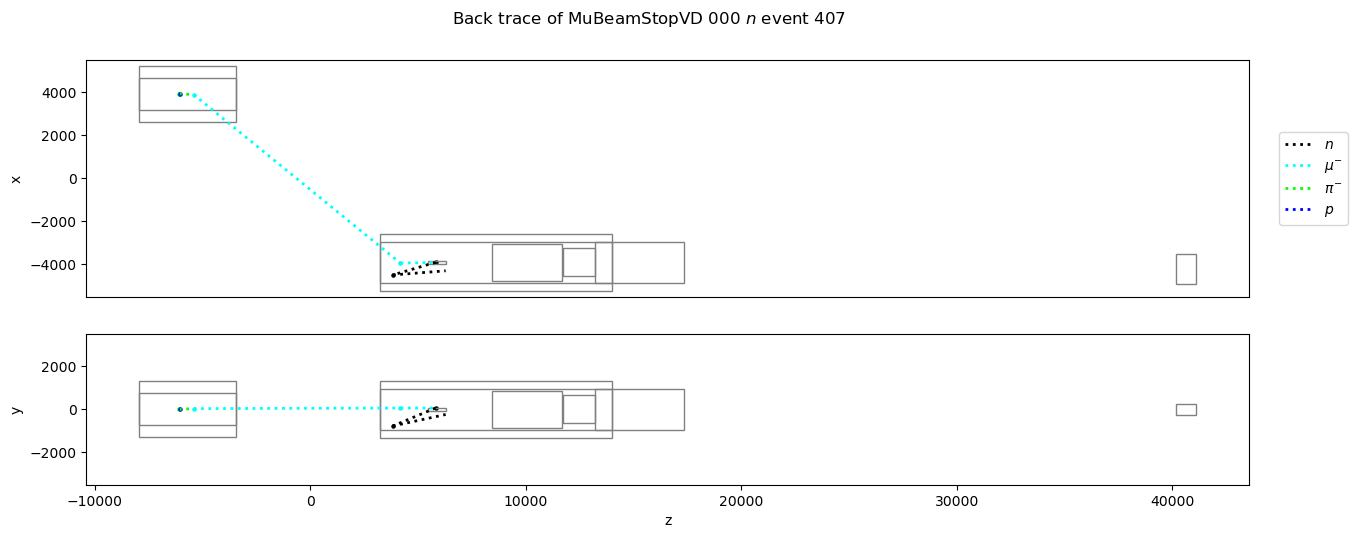

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                         0.000099
creationCode                    97
index                          457
pdgId                         2112
px                        6.400495
py                        0.996213
pz                      -11.968311
startpx              -29240.026474
startpy              -14697.297096
startpz               12250.547409
starttime               532.389587
startx                -3011.016367
starty                  568.385467
startz                 6703.002657
time                 409927.377478
virtualdetectorId               10
x                     -3971.240708
y                       293.576758
z                      6276.019996
weight                           1
r                       301.178727
Name: 2, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3915.084114,-62.267901,5626.590953,31.084373,431.805420,-3011.016367,568.385467,6703.002657,-3.465387,532.389587,165
1,13,-3875.037994,-34.938606,4179.000000,27.203115,158.896194,-3915.084114,-62.267901,5626.590953,0.000000,178.713562,56
2,13,-2167.752659,27.891668,265.100495,-2.597854,94.984764,-3884.227343,-29.580485,4195.901336,27.193888,159.125137,14
3,-211,3910.536845,-0.946140,-6127.846300,92.486679,-18.473858,-2167.752659,27.891668,265.100495,35.583233,94.984764,101
4,2212,3927.921916,-1.272082,-6057.096904,-8624.851562,-18.718246,3910.536845,-0.946140,-6127.846300,-8516.140625,-18.473858,56


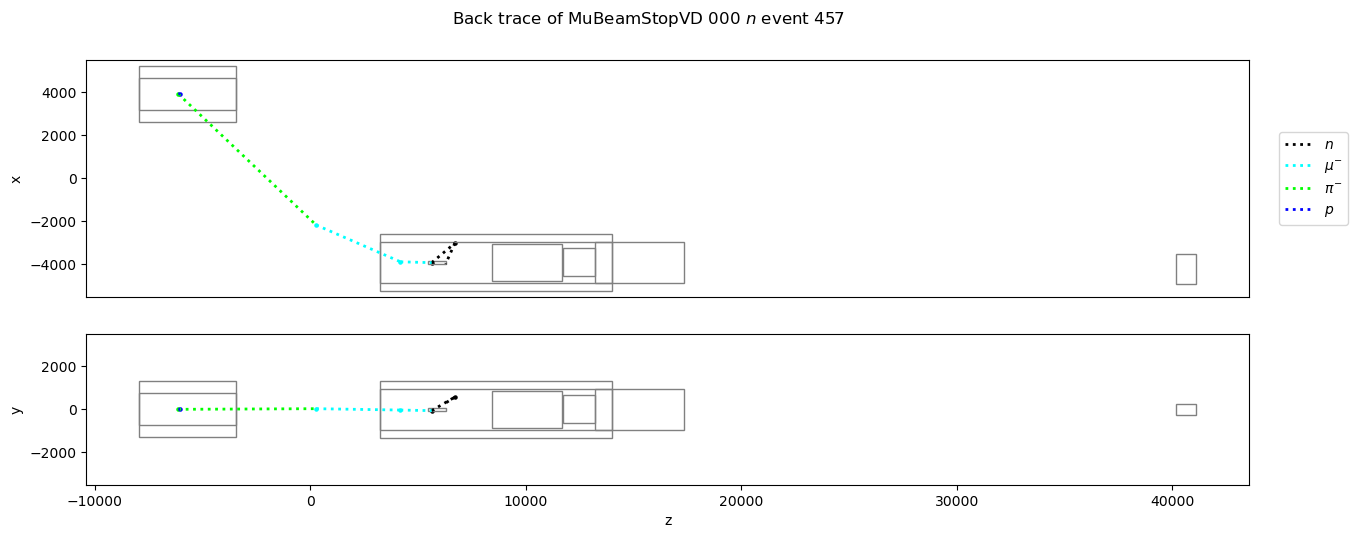

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                         0.000173
creationCode                    97
index                          464
pdgId                         2112
px                      -11.105305
py                       -8.017819
pz                      -11.692564
startpx                 -2026.2568
startpy                -175.214991
startpz               48319.583893
starttime               1604.67395
startx                -2998.657286
starty                  468.945795
startz                 7688.678434
time                 270330.503137
virtualdetectorId               10
x                     -4392.008099
y                      -225.771954
z                      6276.019996
weight                           1
r                       537.703338
Name: 3, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3058.633168,453.612052,7694.128652,-17.098114,1603.653564,-2998.657286,468.945795,7688.678434,-17.098114,1604.673950,97
1,2112,-3942.120429,-54.101625,6204.366296,257.429321,1584.543457,-3058.633168,453.612052,7694.128652,257.429321,1603.653564,165
2,13,-3895.637068,-97.233242,4179.000000,34.861946,206.004959,-3942.120429,-54.101625,6204.366296,0.000000,229.585281,56
3,13,3935.857375,-69.223838,-3513.396580,34.689945,63.896225,-3885.142593,-95.108777,4195.870784,34.895664,206.188019,14
4,-211,3890.829457,0.657100,-6224.075887,148.730927,45.277252,3935.857375,-69.223838,-3513.396580,82.028328,63.896225,101
5,2212,3931.425434,0.725397,-6057.970430,-8624.851562,44.703602,3890.829457,0.657100,-6224.075887,-8358.802734,45.277252,56


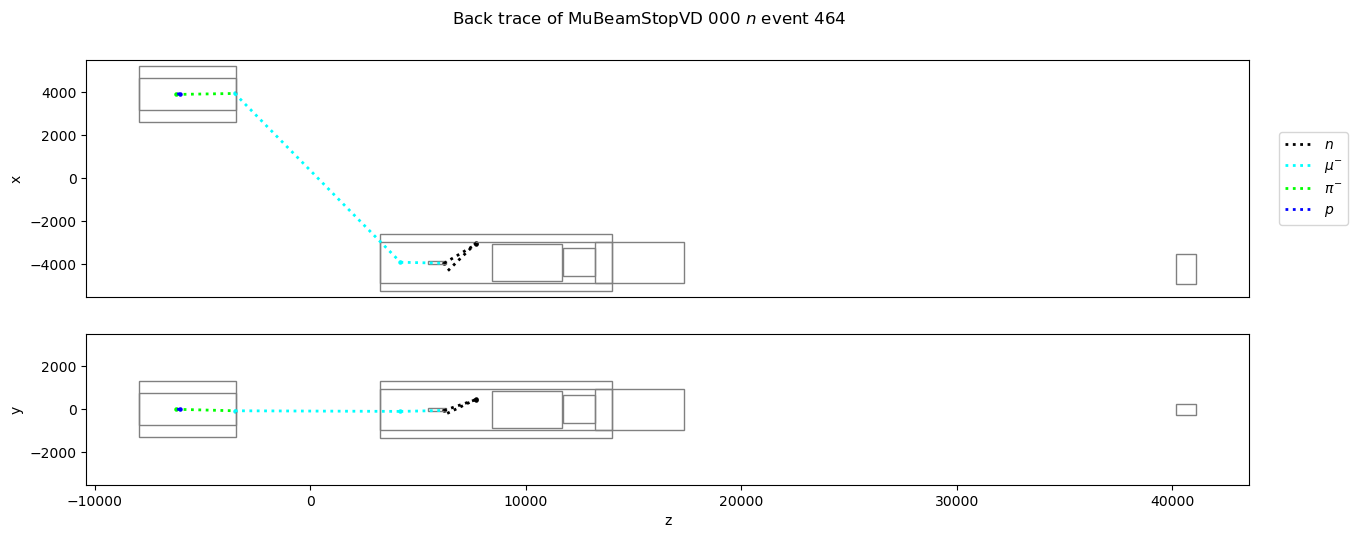

------------------------------------------------------------------------------


tag                    MuBeamStopVD
fileno                            0
E                          0.000023
creationCode                     97
index                           465
pdgId                          2112
px                        -4.343335
py                        -2.062595
pz                         4.424671
startpx                  -2026.2568
startpy                 -175.214991
startpz                48319.583893
starttime                1604.67395
startx                 -2998.657286
starty                   468.945795
startz                  7688.678434
time                 1339027.757254
virtualdetectorId                10
x                      -3994.119455
y                        534.418338
z                       6275.999996
weight                            1
r                        541.963538
Name: 4, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3058.633168,453.612052,7694.128652,-17.098114,1603.653564,-2998.657286,468.945795,7688.678434,-17.098114,1604.673950,97
1,2112,-3942.120429,-54.101625,6204.366296,257.429321,1584.543457,-3058.633168,453.612052,7694.128652,257.429321,1603.653564,165
2,13,-3895.637068,-97.233242,4179.000000,34.861946,206.004959,-3942.120429,-54.101625,6204.366296,0.000000,229.585281,56
3,13,3935.857375,-69.223838,-3513.396580,34.689945,63.896225,-3885.142593,-95.108777,4195.870784,34.895664,206.188019,14
4,-211,3890.829457,0.657100,-6224.075887,148.730927,45.277252,3935.857375,-69.223838,-3513.396580,82.028328,63.896225,101
5,2212,3931.425434,0.725397,-6057.970430,-8624.851562,44.703602,3890.829457,0.657100,-6224.075887,-8358.802734,45.277252,56


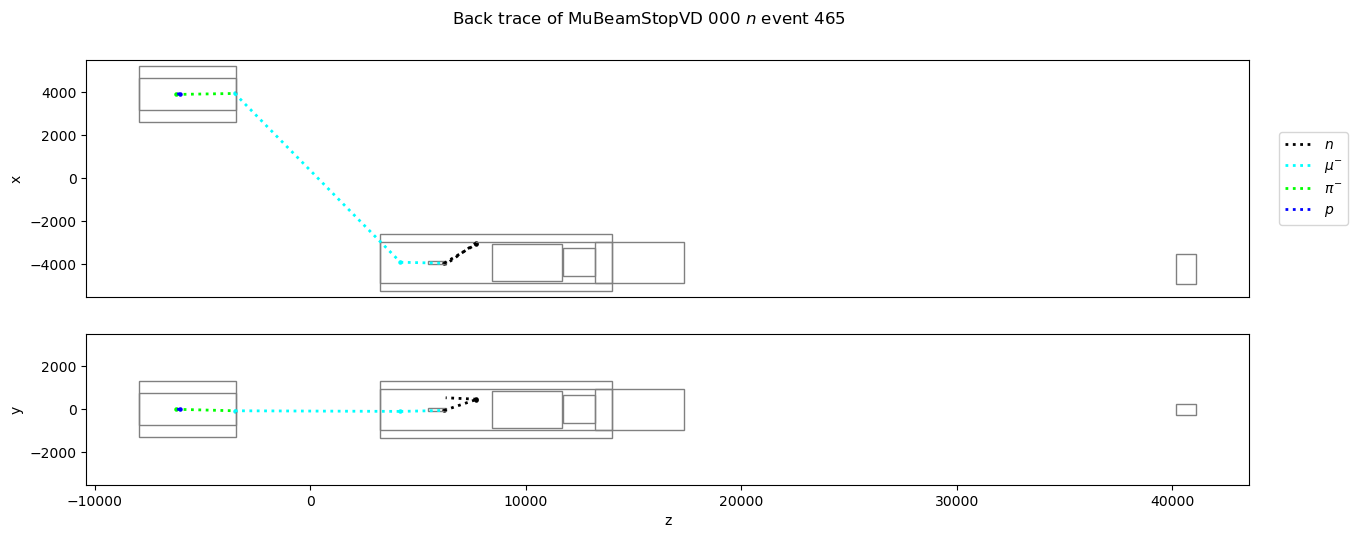

------------------------------------------------------------------------------


tag                    MuBeamStopVD
fileno                            0
E                          0.000015
creationCode                     97
index                           466
pdgId                          2112
px                        -4.012591
py                         1.135995
pz                        -3.196002
startpx                  -2026.2568
startpy                 -175.214991
startpz                48319.583893
starttime                1604.67395
startx                 -2998.657286
starty                   468.945795
startz                  7688.678434
time                 2335598.758601
virtualdetectorId                10
x                      -4048.806845
y                        -512.69323
z                       6276.019996
weight                            1
r                        532.750759
Name: 5, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3058.633168,453.612052,7694.128652,-17.098114,1603.653564,-2998.657286,468.945795,7688.678434,-17.098114,1604.673950,97
1,2112,-3942.120429,-54.101625,6204.366296,257.429321,1584.543457,-3058.633168,453.612052,7694.128652,257.429321,1603.653564,165
2,13,-3895.637068,-97.233242,4179.000000,34.861946,206.004959,-3942.120429,-54.101625,6204.366296,0.000000,229.585281,56
3,13,3935.857375,-69.223838,-3513.396580,34.689945,63.896225,-3885.142593,-95.108777,4195.870784,34.895664,206.188019,14
4,-211,3890.829457,0.657100,-6224.075887,148.730927,45.277252,3935.857375,-69.223838,-3513.396580,82.028328,63.896225,101
5,2212,3931.425434,0.725397,-6057.970430,-8624.851562,44.703602,3890.829457,0.657100,-6224.075887,-8358.802734,45.277252,56


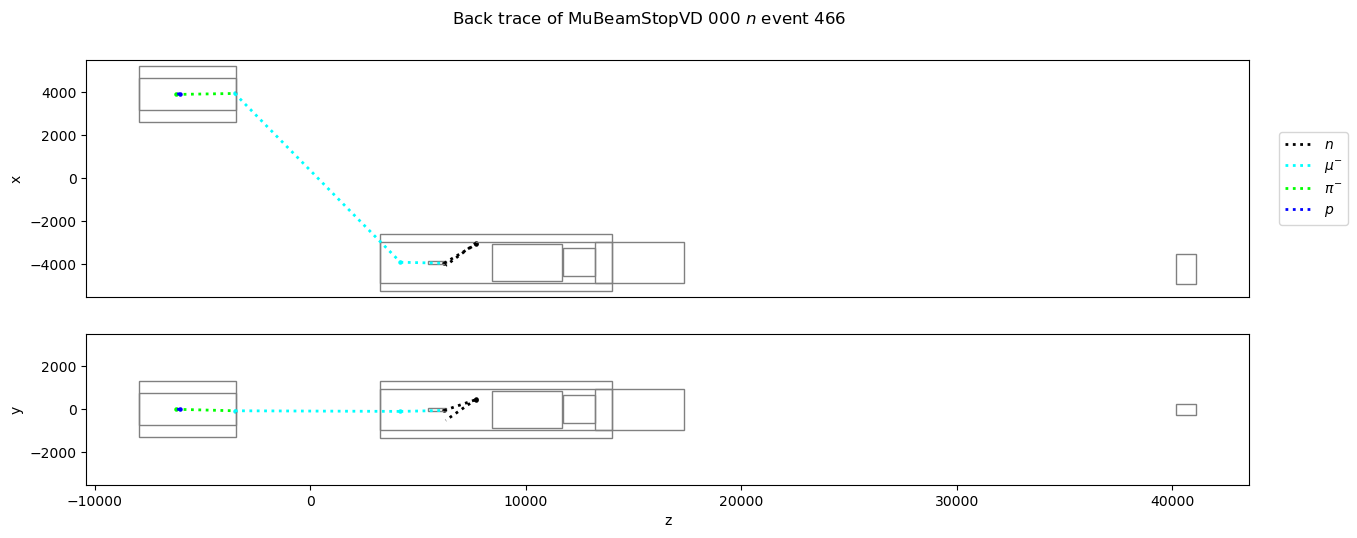

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                         0.00003
creationCode                   97
index                         581
pdgId                        2112
px                      -0.995913
py                      -7.437896
pz                      -0.992939
startpx              36303.203583
startpy               6477.778435
startpz              11080.430984
starttime              412.520935
startx               -2896.728517
starty                 323.831619
startz                6614.806571
time                 759880.32329
virtualdetectorId              10
x                    -3572.299125
y                      109.910679
z                     6276.019996
weight                          1
r                      349.436443
Name: 6, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3928.549570,47.528116,6248.737202,18.922884,351.774780,-2896.728517,323.831619,6614.806571,18.922884,412.520935,165
1,13,-3930.246948,-10.155037,4179.000000,30.522472,258.885498,-3928.549570,47.528116,6248.737202,-0.000000,285.431610,56
2,13,3911.430503,52.560981,-5644.971596,-6.404831,26.067106,-3917.289022,-13.650490,4193.789241,30.533037,259.068787,14
3,-211,3927.795984,1.010691,-6070.934239,17.280912,17.890806,3911.430503,52.560981,-5644.971596,27.851589,26.067106,101
4,2212,3931.045228,1.037733,-6057.875633,-8624.851562,17.845671,3927.795984,1.010691,-6070.934239,-8607.257812,17.890806,56


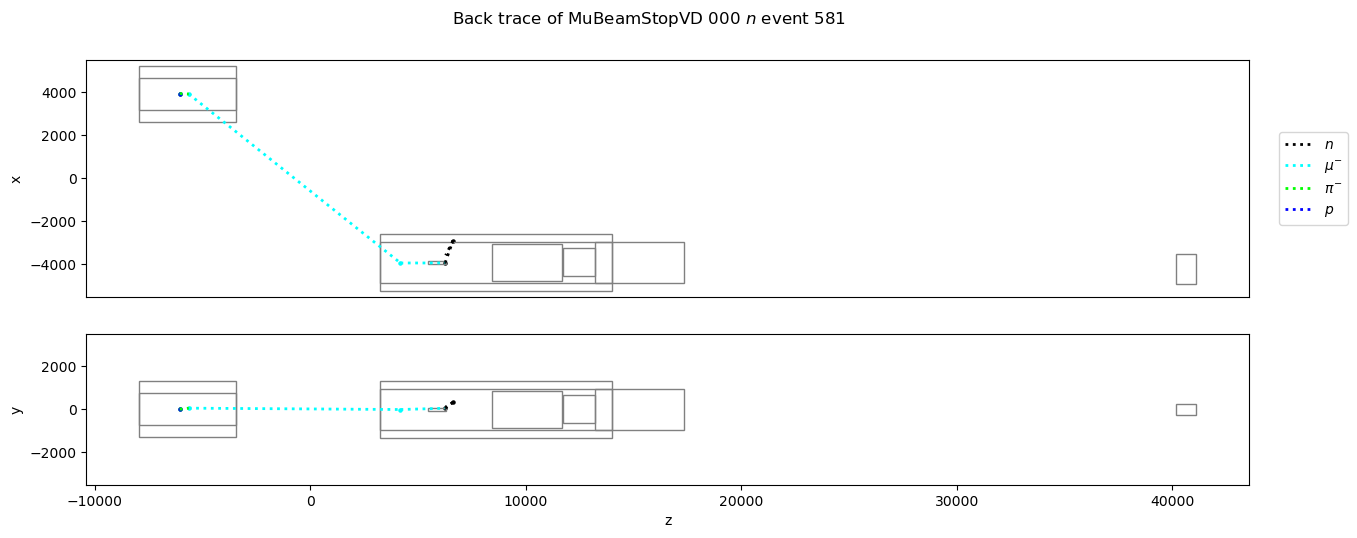

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                         0.000059
creationCode                    97
index                          618
pdgId                         2112
px                        8.425488
py                       -0.641463
pz                        6.212794
startpx               -3108.342171
startpy               32839.641571
startpz               52015.483856
starttime              2459.373291
startx                 -4828.80543
starty                  234.106471
startz                 7029.349665
time                 815127.309105
virtualdetectorId               10
x                     -3694.658469
y                       103.712333
z                      6275.999996
weight                           1
r                       233.623896
Name: 7, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3935.413145,-21.249346,5804.282304,155.843155,2434.207764,-4828.805430,234.106471,7029.349665,154.717773,2459.373291,165
1,13,-3923.990568,9.759846,4179.000000,33.996063,128.247208,-3935.413145,-21.249346,5804.282304,0.000000,148.258743,56
2,13,3861.682295,28.307129,-6209.869762,16.633011,-52.304573,-3932.194183,5.281227,4196.663760,34.005424,128.442078,14
3,-211,3898.979915,18.249152,-6166.926921,-10.726824,-55.280769,3861.682295,28.307129,-6209.869762,-6.578584,-52.304573,14
4,3122,3900.944300,-0.021895,-6175.081817,256.661194,-55.416706,3898.979915,18.249152,-6166.926921,256.661194,-55.280769,101
5,2212,3930.639759,-0.095722,-6057.774539,-8624.851562,-55.822643,3900.944300,-0.021895,-6175.081817,-8401.455078,-55.416706,56


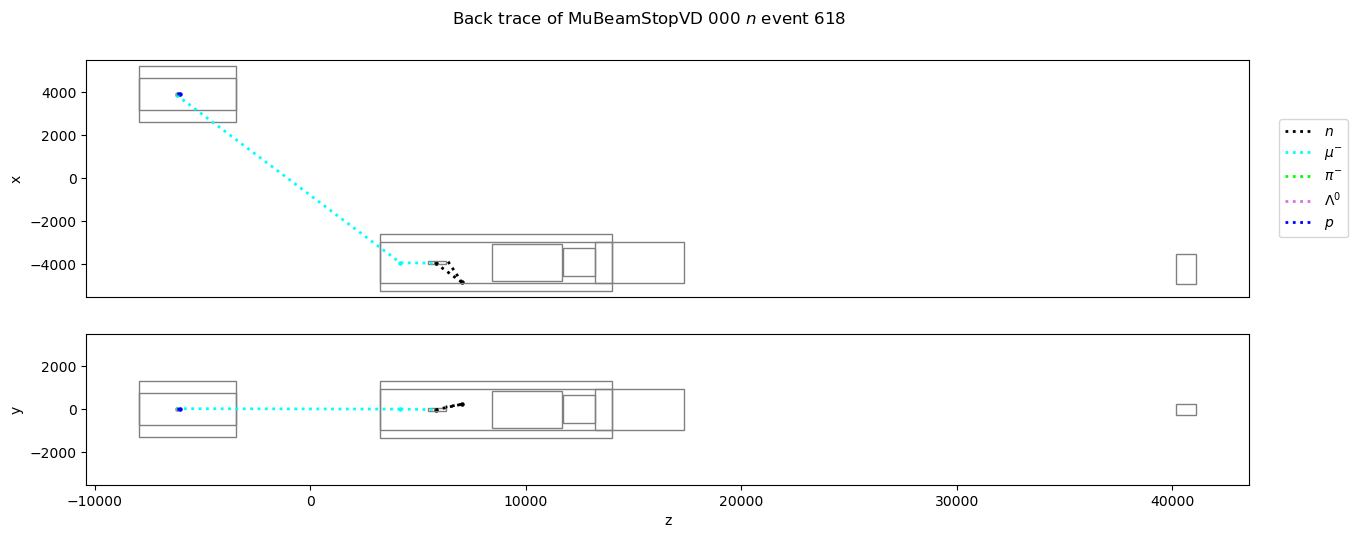

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                          0.00006
creationCode                    97
index                          626
pdgId                         2112
px                       -3.432183
py                        6.673119
pz                        7.518547
startpx               22003.320694
startpy                 257.180482
startpz                4214.260578
starttime               240.337387
startx                -3831.943497
starty                  1307.72382
startz                 5311.684069
time                 412656.745271
virtualdetectorId               10
x                     -4113.534003
y                       335.764829
z                      6275.999996
weight                           1
r                       395.780898
Name: 8, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3940.611240,39.785010,6026.523154,-66.470490,206.400223,-3831.943497,1307.723820,5311.684069,-71.231979,240.337387,165
1,13,-3890.732878,-17.395944,4179.000000,36.259003,169.805542,-3940.611240,39.785010,6026.523154,0.000000,191.091843,56
2,13,3909.946481,-16.525951,-5995.377866,29.840017,3.494096,-3886.457837,-7.336057,4195.728170,36.258884,169.981293,14
3,-211,3915.194723,-1.344891,-6121.714406,8.238420,-1.634841,3909.946481,-16.525951,-5995.377866,16.438755,3.494096,101
4,2212,3931.155158,-1.148060,-6057.903042,-8624.851562,-1.855484,3915.194723,-1.344891,-6121.714406,-8516.293945,-1.634841,56


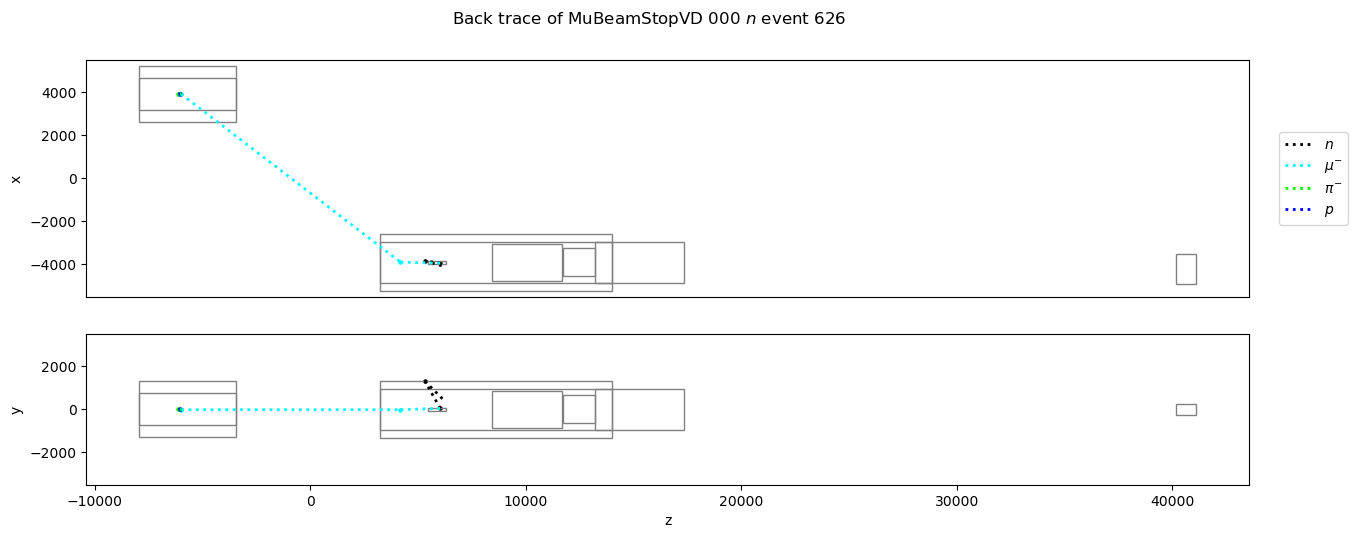

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1399.150009
creationCode                   97
index                         669
pdgId                        2112
px                    6191.830519
py                   19161.923801
pz                  -47176.533308
startpx              48487.850189
startpy               6245.638847
startpz             -17345.306396
starttime             2500.580078
startx               -3820.959147
starty                -708.909561
startz                 8573.37526
time                  2654.814633
virtualdetectorId              10
x                    -3494.401491
y                      231.778265
z                     6276.019996
weight                          1
r                      470.629475
Name: 9, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3922.606636,-54.417991,5537.650762,77.404968,2376.841797,-3820.959147,-708.909561,8573.375260,-1.059700,2500.580078,165
1,13,-3914.993989,-48.733547,4179.000000,23.182432,300.142517,-3922.606636,-54.417991,5537.650762,0.000000,321.862183,56
2,13,3937.747411,-20.568168,-6486.089916,27.466351,63.155983,-3907.648081,-45.995758,4197.370569,23.191603,300.429596,14
3,-211,3881.796763,1.792954,-6254.668352,-9.026554,36.529793,3937.747411,-20.568168,-6486.089916,-1.603149,63.155983,14
4,3122,3881.967792,1.537937,-6252.778295,-542.315613,36.515335,3881.796763,1.792954,-6254.668352,-542.315613,36.529793,101
5,2212,3930.756813,0.443820,-6057.803723,-8624.851562,35.840992,3881.967792,1.537937,-6252.778295,-8243.812500,36.515335,56


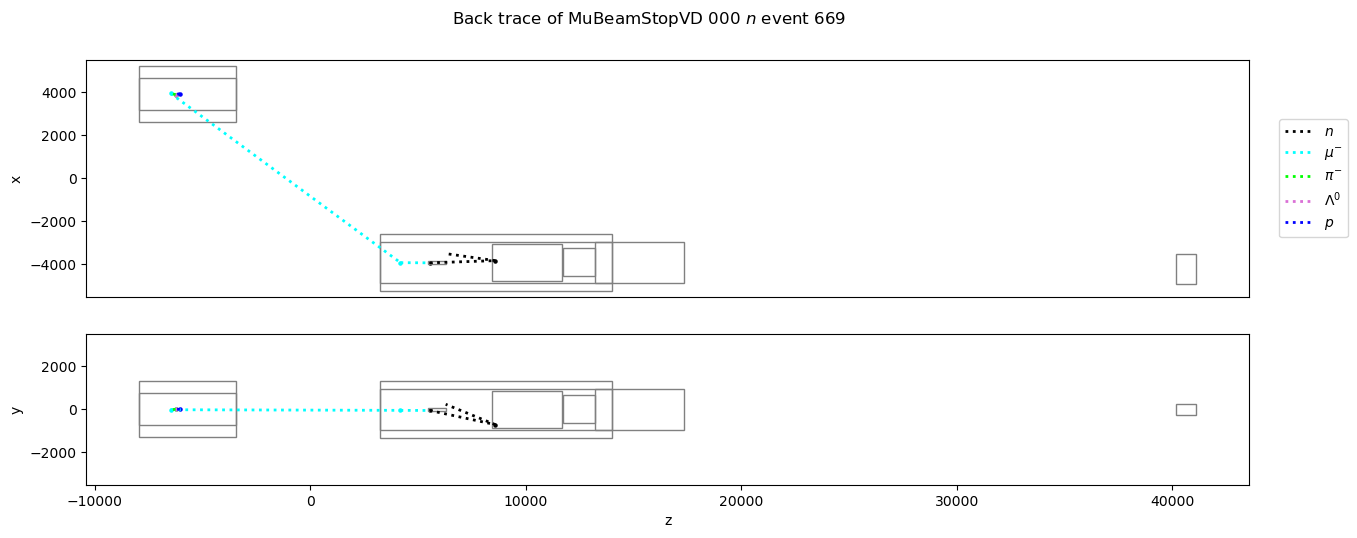

In [10]:
# looking for startz out of stopping target
for pdgId in list_of_pdgId:
    mydfp = df_by_pdgid[pdgId][0].query("startz>6300 or startz<5400").reset_index(drop=True)
    for ii in range(0, min(len(mydfp),10)):
        print('------------------------------------------------------------------------------')
        dfp_ = mydfp.iloc[ii]
        fileno, index = dfp_['fileno'], dfp_['index']

        rdfg_ = rdf_genealogy[fileno].Filter("index==%i"%index)
        dfg_ = pd.DataFrame(rdfg_.AsNumpy(columns = ["pdgId", 
                                                     "startx", "starty", "startz", "startpz", "startGlobalTime", 
                                                     "endx", "endy", "endz", "endpz", "endGlobalTime", "creationCode"]))
        
        display(dfp_)
        display(dfg_)
        fig, ax_top, ax_side = plot_utils.draw_particle_event_backtrace(dfp_, dfg_, tag, fileno, index)
        plt.show()